In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 1 — Mount Google Drive and Inspect Dataset Structure
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
import pandas as pd

CIC_PATH = Path("/content/drive/MyDrive/CICIoT2023")
BOT_PATH = Path("/content/drive/MyDrive/IDS dataset")

print("=" * 80)
print("EFG-IDS DATASET INSPECTION")
print("=" * 80)

print(f"\nCIC-IoT-2023 path:")
print(CIC_PATH)
print("Exists:", CIC_PATH.exists())

print(f"\nBoT/IDS dataset path:")
print(BOT_PATH)
print("Exists:", BOT_PATH.exists())


def inspect_folder(folder, name):
    print("\n" + "=" * 80)
    print(f"{name}")
    print("=" * 80)

    if not folder.exists():
        print("ERROR: Folder does not exist.")
        return

    files = []

    for root, dirs, filenames in os.walk(folder):
        for filename in filenames:
            path = Path(root) / filename
            files.append(path)

    print(f"Total files found: {len(files)}")

    extensions = {}

    for f in files:
        ext = f.suffix.lower()
        extensions[ext] = extensions.get(ext, 0) + 1

    print("\nFile types:")
    for ext, count in sorted(extensions.items()):
        print(f"  {ext or '[no extension]':15s} : {count}")

    print("\nFirst 50 files:")

    for f in files[:50]:
        size_mb = f.stat().st_size / (1024 ** 2)

        print(
            f"{str(f.relative_to(folder)):<80} "
            f"{size_mb:>10.2f} MB"
        )

    return files


cic_files = inspect_folder(
    CIC_PATH,
    "CIC-IoT-2023"
)

bot_files = inspect_folder(
    BOT_PATH,
    "IDS DATASET / BoT-IoT"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EFG-IDS DATASET INSPECTION

CIC-IoT-2023 path:
/content/drive/MyDrive/CICIoT2023
Exists: True

BoT/IDS dataset path:
/content/drive/MyDrive/IDS dataset
Exists: True

CIC-IoT-2023
Total files found: 170

File types:
  .csv            : 169
  .parquet        : 1

First 50 files:
part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv                              67.08 MB
part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv                              61.49 MB
part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv                              77.34 MB
part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv                              64.90 MB
part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv                              63.90 MB
part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv                              67.45 MB
part-00006-363d1ba3-8ab

In [ ]:
# ============================================================
# CELL 2 — Automatically Inspect CSV Dataset Schemas
# ============================================================

from pathlib import Path
import pandas as pd
import os

def find_tabular_files(folder):
    extensions = {
        ".csv",
        ".csv.gz",
        ".parquet",
        ".parq"
    }

    files = []

    for root, dirs, filenames in os.walk(folder):
        for filename in filenames:
            path = Path(root) / filename

            if path.suffix.lower() in extensions:
                files.append(path)

    return files


def inspect_csv_file(path, nrows=5):

    print("\n" + "=" * 100)
    print("FILE:")
    print(path)
    print("=" * 100)

    try:

        if str(path).endswith(".parquet"):
            df = pd.read_parquet(path)
        else:
            df = pd.read_csv(
                path,
                nrows=nrows,
                low_memory=False
            )

        print("Shape preview:", df.shape)

        print("\nColumns:")
        for i, col in enumerate(df.columns):
            print(f"{i:3d} | {col}")

        print("\nData types:")
        print(df.dtypes)

        print("\nFirst rows:")
        display(df.head())

        print("\nPotential label columns:")

        label_candidates = [
            c for c in df.columns
            if any(
                word in c.lower()
                for word in [
                    "label",
                    "attack",
                    "class",
                    "category",
                    "target"
                ]
            )
        ]

        for c in label_candidates:
            print(f"  {c}")

    except Exception as e:
        print("Could not inspect file:")
        print(e)


cic_tabular = find_tabular_files(CIC_PATH)
bot_tabular = find_tabular_files(BOT_PATH)

print("\nCIC-IoT-2023 tabular files:", len(cic_tabular))

for f in cic_tabular[:10]:
    print(f)

print("\nIDS/BoT tabular files:", len(bot_tabular))

for f in bot_tabular[:10]:
    print(f)


# Inspect a few files only
print("\n\n========== CIC-IoT-2023 SAMPLE FILES ==========")

for f in cic_tabular[:3]:
    inspect_csv_file(f)


print("\n\n========== IDS / BoT-IoT SAMPLE FILES ==========")

for f in bot_tabular[:3]:
    inspect_csv_file(f)


CIC-IoT-2023 tabular files: 170
/content/drive/MyDrive/CICIoT2023/part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/content/drive/MyDrive/CICIoT2023/part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv

IDS/BoT tabular files: 9
/content/drive/MyDrive/IDS data

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.00,6.00,64.00,0.329807,0.329807,0.0,1.0,0.0,1.0,...,0.000000,54.00,8.334383e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-RSTFINFlood
1,0.000000,57.04,6.33,64.00,4.290556,4.290556,0.0,0.0,0.0,0.0,...,2.822973,57.04,8.292607e+07,9.5,10.464666,4.010353,160.987842,0.05,141.55,DoS-TCP_Flood
2,0.000000,0.00,1.00,64.00,33.396799,33.396799,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.312799e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
3,0.328175,76175.00,17.00,64.00,4642.133010,4642.133010,0.0,0.0,0.0,0.0,...,0.000000,50.00,8.301570e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DoS-UDP_Flood
4,0.117320,101.73,6.11,65.91,6.202211,6.202211,0.0,0.0,1.0,0.0,...,23.113111,57.88,8.297300e+07,9.5,11.346876,32.716243,3016.808286,0.19,141.55,DoS-SYN_Flood



Potential label columns:
  label

FILE:
/content/drive/MyDrive/CICIoT2023/part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Shape preview: (5, 47)

Columns:
  0 | flow_duration
  1 | Header_Length
  2 | Protocol Type
  3 | Duration
  4 | Rate
  5 | Srate
  6 | Drate
  7 | fin_flag_number
  8 | syn_flag_number
  9 | rst_flag_number
 10 | psh_flag_number
 11 | ack_flag_number
 12 | ece_flag_number
 13 | cwr_flag_number
 14 | ack_count
 15 | syn_count
 16 | fin_count
 17 | urg_count
 18 | rst_count
 19 | HTTP
 20 | HTTPS
 21 | DNS
 22 | Telnet
 23 | SMTP
 24 | SSH
 25 | IRC
 26 | TCP
 27 | UDP
 28 | DHCP
 29 | ARP
 30 | ICMP
 31 | IPv
 32 | LLC
 33 | Tot sum
 34 | Min
 35 | Max
 36 | AVG
 37 | Std
 38 | Tot size
 39 | IAT
 40 | Number
 41 | Magnitue
 42 | Radius
 43 | Covariance
 44 | Variance
 45 | Weight
 46 | label

Data types:
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate            

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,53.46,5.94,63.36,1.145800,1.145800,0.0,0.0,1.0,0.0,...,0.040218,54.06,8.309402e+07,9.5,10.393232,0.057331,0.054789,0.03,141.55,DDoS-SYN_Flood
1,0.000000,54.00,6.00,64.00,1.027823,1.027823,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.307159e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-TCP_Flood
2,2.204616,93.96,6.00,64.00,0.671213,0.671213,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.336561e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
3,0.053618,12497.00,17.00,64.00,47647.897124,47647.897124,0.0,0.0,0.0,0.0,...,0.000000,50.00,8.310693e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
4,0.000000,0.00,1.00,64.00,0.667744,0.667744,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.314933e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood



Potential label columns:
  label

FILE:
/content/drive/MyDrive/CICIoT2023/part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Could not inspect file:
[Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/CICIoT2023/part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv'


========== IDS / BoT-IoT SAMPLE FILES ==========

FILE:
/content/drive/MyDrive/IDS dataset/Bruteforce-Wednesday-14-02-2018.csv
Could not inspect file:
[Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/IDS dataset/Bruteforce-Wednesday-14-02-2018.csv'

FILE:
/content/drive/MyDrive/IDS dataset/DDoS1-Tuesday-20-02-2018.csv
Could not inspect file:
[Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/IDS dataset/DDoS1-Tuesday-20-02-2018.csv'

FILE:
/content/drive/MyDrive/IDS dataset/DDoS2-Wednesday-21-02-2018.csv
Could not inspect file:
[Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/IDS dataset/DDoS2-Wednesday-21-02-2018.csv'


In [ ]:
# ============================================================
# CELL 3 — Reconnect Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

CIC_PATH = "/content/drive/MyDrive/CICIoT2023"
IDS_PATH = "/content/drive/MyDrive/IDS dataset"

print("CIC-IoT-2023 exists:", os.path.exists(CIC_PATH))
print("IDS dataset exists:", os.path.exists(IDS_PATH))

print("\nCIC files:", len(os.listdir(CIC_PATH)))
print("IDS files:", len(os.listdir(IDS_PATH)))

Mounted at /content/drive
CIC-IoT-2023 exists: True
IDS dataset exists: True

CIC files: 170
IDS files: 26


In [ ]:
# ============================================================
# CELL 4 — Inspect IDS Dataset
# ============================================================

import pandas as pd
import os
from pathlib import Path

IDS_PATH = Path("/content/drive/MyDrive/IDS dataset")

files = sorted(IDS_PATH.glob("*.csv"))

print("CSV files found:", len(files))

for i, file in enumerate(files):
    print(f"{i+1:2d}. {file.name}")


# Read ONLY the first file initially
test_file = files[0]

print("\nTesting:")
print(test_file)

try:
    df_test = pd.read_csv(
        test_file,
        nrows=5,
        low_memory=False
    )

    print("\nSuccessfully loaded.")
    print("Shape:", df_test.shape)

    print("\nColumns:")
    print(df_test.columns.tolist())

    print("\nData types:")
    print(df_test.dtypes)

    print("\nSample:")
    display(df_test.head())

except Exception as e:
    print("\nERROR:")
    print(repr(e))

CSV files found: 9
 1. Botnet-Friday-02-03-2018.csv
 2. Bruteforce-Wednesday-14-02-2018.csv
 3. DDoS1-Tuesday-20-02-2018.csv
 4. DDoS2-Wednesday-21-02-2018.csv
 5. DoS1-Thursday-15-02-2018.csv
 6. DoS2-Friday-16-02-2018.csv
 7. Infil1-Wednesday-28-02-2018.csv
 8. Web1-Thursday-22-02-2018.csv
 9. Web2-Friday-23-02-2018.csv

Testing:
/content/drive/MyDrive/IDS dataset/Botnet-Friday-02-03-2018.csv

Successfully loaded.
Shape: (5, 80)

Columns:
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Fla

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773,202,0,...,20,0,0,0,0,0,0,0,0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0,38,0,...,20,0,0,0,0,0,0,0,0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527,385,0,...,20,0,0,0,0,0,0,0,0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141,517,0,...,20,0,0,0,0,0,0,0,0,Benign


In [ ]:
# ============================================================
# CELL 5 — Identify ALL IDS Dataset Files
# ============================================================

from pathlib import Path
import pandas as pd
import os

IDS_PATH = Path("/content/drive/MyDrive/IDS dataset")

files = sorted(IDS_PATH.glob("*.csv"))

print("=" * 100)
print("IDS DATASET FILE INVENTORY")
print("=" * 100)

print(f"Total CSV files: {len(files)}\n")

for i, f in enumerate(files, 1):
    size_mb = f.stat().st_size / (1024 ** 2)
    print(f"{i:02d}. {f.name:<70} {size_mb:>10.2f} MB")


# ============================================================
# Inspect first row/schema of EVERY file
# ============================================================

print("\n" + "=" * 100)
print("SCHEMA INSPECTION")
print("=" * 100)

schema_summary = []

for i, file in enumerate(files, 1):

    print(f"\n[{i}/{len(files)}] {file.name}")

    try:
        df = pd.read_csv(
            file,
            nrows=3,
            low_memory=False
        )

        print("Columns:", len(df.columns))
        print("Shape preview:", df.shape)

        print("First 15 columns:")
        print(df.columns.tolist()[:15])

        print("Last 10 columns:")
        print(df.columns.tolist()[-10:])

        schema_summary.append({
            "file": file.name,
            "columns": len(df.columns),
            "column_names": list(df.columns),
            "status": "OK"
        })

    except Exception as e:

        print("ERROR:", repr(e))

        schema_summary.append({
            "file": file.name,
            "columns": None,
            "column_names": None,
            "status": str(e)
        })


# ============================================================
# Summary table
# ============================================================

schema_df = pd.DataFrame(schema_summary)

print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)

display(
    schema_df[
        ["file", "columns", "status"]
    ]
)

IDS DATASET FILE INVENTORY
Total CSV files: 9

01. Botnet-Friday-02-03-2018.csv                                                15.00 MB
02. Bruteforce-Wednesday-14-02-2018.csv                                         15.00 MB
03. DDoS1-Tuesday-20-02-2018.csv                                                15.00 MB
04. DDoS2-Wednesday-21-02-2018.csv                                              15.00 MB
05. DoS1-Thursday-15-02-2018.csv                                                15.00 MB
06. DoS2-Friday-16-02-2018.csv                                                   1.00 MB
07. Infil1-Wednesday-28-02-2018.csv                                              1.00 MB
08. Web1-Thursday-22-02-2018.csv                                               364.91 MB
09. Web2-Friday-23-02-2018.csv                                                 365.11 MB

SCHEMA INSPECTION

[1/9] Botnet-Friday-02-03-2018.csv
Columns: 80
Shape preview: (3, 80)
First 15 columns:
['Dst Port', 'Protocol', 'Timestamp', 'Flow 

,file,columns,status
0,Botnet-Friday-02-03-2018.csv,80,OK
1,Bruteforce-Wednesday-14-02-2018.csv,80,OK
2,DDoS1-Tuesday-20-02-2018.csv,80,OK
3,DDoS2-Wednesday-21-02-2018.csv,80,OK
4,DoS1-Thursday-15-02-2018.csv,80,OK
5,DoS2-Friday-16-02-2018.csv,80,OK
6,Infil1-Wednesday-28-02-2018.csv,80,OK
7,Web1-Thursday-22-02-2018.csv,80,OK
8,Web2-Friday-23-02-2018.csv,80,OK


In [ ]:
# ============================================================
# CELL 6 — Find Label/Target Columns and Class Names
# ============================================================

from pathlib import Path
import pandas as pd

IDS_PATH = Path("/content/drive/MyDrive/IDS dataset")

files = sorted(IDS_PATH.glob("*.csv"))

for file in files:

    print("\n" + "=" * 100)
    print(file.name)
    print("=" * 100)

    try:

        df = pd.read_csv(
            file,
            nrows=1000,
            low_memory=False
        )

        # Possible label columns
        candidates = [
            col for col in df.columns
            if any(
                key in str(col).lower()
                for key in [
                    "label",
                    "attack",
                    "class",
                    "category",
                    "target"
                ]
            )
        ]

        print("Possible label columns:", candidates)

        for col in candidates:

            print(f"\nColumn: {col}")

            print(
                df[col]
                .value_counts(dropna=False)
                .head(20)
            )

    except Exception as e:
        print("ERROR:", repr(e))


Botnet-Friday-02-03-2018.csv
Possible label columns: ['Label']

Column: Label
Label
Benign    1000
Name: count, dtype: int64

Bruteforce-Wednesday-14-02-2018.csv
Possible label columns: ['Label']

Column: Label
Label
FTP-BruteForce    905
Benign             95
Name: count, dtype: int64

DDoS1-Tuesday-20-02-2018.csv
Possible label columns: ['Label']

Column: Label
Label
DDoS attacks-LOIC-HTTP    937
Benign                     63
Name: count, dtype: int64

DDoS2-Wednesday-21-02-2018.csv
Possible label columns: ['Label']

Column: Label
Label
Benign                  612
DDOS attack-LOIC-UDP    388
Name: count, dtype: int64

DoS1-Thursday-15-02-2018.csv
Possible label columns: ['Label']

Column: Label
Label
DoS attacks-GoldenEye    955
Benign                    45
Name: count, dtype: int64

DoS2-Friday-16-02-2018.csv
Possible label columns: ['Label']

Column: Label
Label
DoS attacks-SlowHTTPTest    903
Benign                       97
Name: count, dtype: int64

Infil1-Wednesday-28-02-2018.c

In [ ]:
# ============================================================
# CELL 7 — Compare CIC-IoT-2023 and IDS Feature Spaces
# ============================================================

import pandas as pd
from pathlib import Path
import os

CIC_PATH = Path("/content/drive/MyDrive/CICIoT2023")
IDS_PATH = Path("/content/drive/MyDrive/IDS dataset")

# ------------------------------------------------------------
# 1. Get CIC-IoT-2023 columns
# ------------------------------------------------------------

cic_file = sorted(CIC_PATH.glob("*.csv"))[0]

cic_sample = pd.read_csv(
    cic_file,
    nrows=5,
    low_memory=False
)

cic_columns = list(cic_sample.columns)

print("=" * 90)
print("CIC-IoT-2023 FEATURE SPACE")
print("=" * 90)

print("Number of columns:", len(cic_columns))

for i, col in enumerate(cic_columns):
    print(f"{i:02d}: {col}")


# ------------------------------------------------------------
# 2. Get IDS columns from all files
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("IDS FEATURE SPACE")
print("=" * 90)

ids_files = sorted(IDS_PATH.glob("*.csv"))

ids_schemas = {}

for file in ids_files:

    try:

        df = pd.read_csv(
            file,
            nrows=2,
            low_memory=False
        )

        ids_schemas[file.name] = list(df.columns)

    except Exception as e:

        print("ERROR:", file.name, repr(e))


# ------------------------------------------------------------
# 3. Check whether all IDS files have the same schema
# ------------------------------------------------------------

unique_schemas = {}

for filename, columns in ids_schemas.items():

    key = tuple(columns)

    if key not in unique_schemas:
        unique_schemas[key] = []

    unique_schemas[key].append(filename)


print("\nNumber of unique IDS schemas:", len(unique_schemas))

for i, (schema, filenames) in enumerate(unique_schemas.items(), 1):

    print(f"\nSchema {i}")
    print("Number of files:", len(filenames))
    print("Files:")

    for f in filenames:
        print("  ", f)

    print("Number of columns:", len(schema))


# ------------------------------------------------------------
# 4. Compare first IDS schema with CIC-IoT
# ------------------------------------------------------------

first_ids_columns = list(next(iter(ids_schemas.values())))

cic_features = set(
    c for c in cic_columns
    if c.lower() != "label"
)

ids_features = set(
    c for c in first_ids_columns
    if c.lower() != "label"
)


common = sorted(cic_features.intersection(ids_features))

only_cic = sorted(cic_features - ids_features)

only_ids = sorted(ids_features - cic_features)


print("\n" + "=" * 90)
print("FEATURE COMPATIBILITY")
print("=" * 90)

print("\nCIC-IoT features:", len(cic_features))
print("IDS features:", len(ids_features))
print("Common features:", len(common))

print("\nCommon features:")
for c in common:
    print("  ", c)

print("\nFeatures ONLY in CIC-IoT-2023:")
for c in only_cic:
    print("  ", c)

print("\nFeatures ONLY in IDS dataset:")
for c in only_ids:
    print("  ", c)

CIC-IoT-2023 FEATURE SPACE
Number of columns: 47
00: flow_duration
01: Header_Length
02: Protocol Type
03: Duration
04: Rate
05: Srate
06: Drate
07: fin_flag_number
08: syn_flag_number
09: rst_flag_number
10: psh_flag_number
11: ack_flag_number
12: ece_flag_number
13: cwr_flag_number
14: ack_count
15: syn_count
16: fin_count
17: urg_count
18: rst_count
19: HTTP
20: HTTPS
21: DNS
22: Telnet
23: SMTP
24: SSH
25: IRC
26: TCP
27: UDP
28: DHCP
29: ARP
30: ICMP
31: IPv
32: LLC
33: Tot sum
34: Min
35: Max
36: AVG
37: Std
38: Tot size
39: IAT
40: Number
41: Magnitue
42: Radius
43: Covariance
44: Variance
45: Weight
46: label

IDS FEATURE SPACE

Number of unique IDS schemas: 1

Schema 1
Number of files: 9
Files:
   Botnet-Friday-02-03-2018.csv
   Bruteforce-Wednesday-14-02-2018.csv
   DDoS1-Tuesday-20-02-2018.csv
   DDoS2-Wednesday-21-02-2018.csv
   DoS1-Thursday-15-02-2018.csv
   DoS2-Friday-16-02-2018.csv
   Infil1-Wednesday-28-02-2018.csv
   Web1-Thursday-22-02-2018.csv
   Web2-Friday-23-02-

In [ ]:
# ============================================================
# CELL 8 — Complete IDS Label Distribution
# ============================================================

import pandas as pd
from pathlib import Path
from collections import Counter

IDS_PATH = Path("/content/drive/MyDrive/IDS dataset")

files = sorted(IDS_PATH.glob("*.csv"))

label_counter = Counter()
file_statistics = []

for i, file in enumerate(files, 1):

    print(f"Processing {i}/{len(files)}: {file.name}")

    try:

        df = pd.read_csv(
            file,
            usecols=lambda c: c.lower() == "label",
            low_memory=False
        )

        # Locate label column regardless of capitalization
        label_col = [
            c for c in df.columns
            if c.lower() == "label"
        ][0]

        counts = df[label_col].value_counts(dropna=False)

        for label, count in counts.items():
            label_counter[str(label)] += int(count)

        file_statistics.append({
            "file": file.name,
            "rows": len(df),
            "classes": df[label_col].nunique(),
            "labels": ", ".join(
                str(x) for x in counts.index
            )
        })

    except Exception as e:

        print("ERROR:", repr(e))


# ------------------------------------------------------------
# Overall distribution
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("COMPLETE IDS LABEL DISTRIBUTION")
print("=" * 90)

label_df = pd.DataFrame(
    [
        {
            "Label": label,
            "Samples": count
        }
        for label, count in label_counter.items()
    ]
)

label_df["Percentage"] = (
    label_df["Samples"]
    / label_df["Samples"].sum()
    * 100
)

label_df = label_df.sort_values(
    "Samples",
    ascending=False
).reset_index(drop=True)

display(label_df)

print(
    "\nTotal IDS samples:",
    label_df["Samples"].sum()
)

print(
    "Number of classes:",
    len(label_df)
)


# ------------------------------------------------------------
# File-level statistics
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FILE STATISTICS")
print("=" * 90)

file_df = pd.DataFrame(file_statistics)

display(file_df)

Processing 1/9: Botnet-Friday-02-03-2018.csv
Processing 2/9: Bruteforce-Wednesday-14-02-2018.csv
Processing 3/9: DDoS1-Tuesday-20-02-2018.csv
Processing 4/9: DDoS2-Wednesday-21-02-2018.csv
Processing 5/9: DoS1-Thursday-15-02-2018.csv
Processing 6/9: DoS2-Friday-16-02-2018.csv
Processing 7/9: Infil1-Wednesday-28-02-2018.csv
Processing 8/9: Web1-Thursday-22-02-2018.csv
Processing 9/9: Web2-Friday-23-02-2018.csv

COMPLETE IDS LABEL DISTRIBUTION


,Label,Samples,Percentage
0,Benign,2111758,89.875696
1,FTP-BruteForce,71115,3.026630
2,DDOS attack-HOIC,43775,1.863049
3,Bot,40076,1.705621
4,DDoS attacks-LOIC-HTTP,38730,1.648336
5,DoS attacks-GoldenEye,31481,1.339821
6,DoS attacks-Slowloris,5665,0.241100
7,DoS attacks-SlowHTTPTest,4378,0.186326
8,DDOS attack-LOIC-UDP,1730,0.073628
9,Brute Force -Web,611,0.026004



Total IDS samples: 2349643
Number of classes: 13

FILE STATISTICS


,file,rows,classes,labels
0,Botnet-Friday-02-03-2018.csv,49620,2,"Bot, Benign, nan"
1,Bruteforce-Wednesday-14-02-2018.csv,71225,2,"FTP-BruteForce, Benign, nan"
2,DDoS1-Tuesday-20-02-2018.csv,38803,2,"DDoS attacks-LOIC-HTTP, Benign, nan"
3,DDoS2-Wednesday-21-02-2018.csv,47709,3,"DDOS attack-HOIC, Benign, DDOS attack-LOIC-UDP..."
4,DoS1-Thursday-15-02-2018.csv,38054,3,"DoS attacks-GoldenEye, DoS attacks-Slowloris, ..."
5,DoS2-Friday-16-02-2018.csv,4477,2,"DoS attacks-SlowHTTPTest, Benign, nan"
6,Infil1-Wednesday-28-02-2018.csv,2605,1,"Benign, nan"
7,Web1-Thursday-22-02-2018.csv,1048575,4,"Benign, Brute Force -Web, Brute Force -XSS, SQ..."
8,Web2-Friday-23-02-2018.csv,1048575,4,"Benign, Brute Force -Web, Brute Force -XSS, SQ..."


In [ ]:
# ============================================================
# CELL 9 — EFG-IDS Reproducibility Configuration
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

CIC_PATH = Path("/content/drive/MyDrive/CICIoT2023")
IDS_PATH = Path("/content/drive/MyDrive/IDS dataset")

OUTPUT_PATH = Path("/content/drive/MyDrive/EFG_IDS_RESULTS")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Experiment parameters
# ------------------------------------------------------------

CONFIG = {

    # Dataset
    "seed": SEED,

    # Paper-inspired split
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    # Paper configuration
    "batch_size": 128,
    "learning_rate": 0.001,
    "local_epochs": 5,
    "federated_rounds": 50,

    # FedProx
    "fedprox_mu": 0.01,

    # Gradient protection
    "gradient_clip": 5.0,
    "noise_variance": 1e-5,

    # Feature optimization
    "correlation_threshold": 0.90,

    # Graph
    "num_neighbors": 10,

    # Model
    "hidden_dim": 128,
    "embedding_dim": 64,

    # Federated clients
    "num_clients": 5,

    # Computation
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

print("=" * 70)
print("EFG-IDS EXPERIMENT CONFIGURATION")
print("=" * 70)

for key, value in CONFIG.items():
    print(f"{key:25s}: {value}")

print("\nDevice:", CONFIG["device"])
print("Output:", OUTPUT_PATH)

EFG-IDS EXPERIMENT CONFIGURATION
seed                     : 42
train_ratio              : 0.7
val_ratio                : 0.15
test_ratio               : 0.15
batch_size               : 128
learning_rate            : 0.001
local_epochs             : 5
federated_rounds         : 50
fedprox_mu               : 0.01
gradient_clip            : 5.0
noise_variance           : 1e-05
correlation_threshold    : 0.9
num_neighbors            : 10
hidden_dim               : 128
embedding_dim            : 64
num_clients              : 5
device                   : cpu

Device: cpu
Output: /content/drive/MyDrive/EFG_IDS_RESULTS


In [ ]:
# ============================================================
# CELL 10 — Robust CSV Loader
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path


def clean_dataframe(df, label_column="label"):

    df = df.copy()

    # Normalize column names
    df.columns = [
        str(c).strip()
        for c in df.columns
    ]

    # Locate label column case-insensitively
    label_candidates = [
        c for c in df.columns
        if c.lower() == label_column.lower()
    ]

    if not label_candidates:
        raise ValueError(
            f"Label column '{label_column}' not found."
        )

    actual_label = label_candidates[0]

    # Remove completely empty rows
    df = df.dropna(
        how="all"
    ).reset_index(drop=True)

    # Replace infinity
    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Separate labels
    y = df[actual_label].astype(str)

    X = df.drop(
        columns=[actual_label]
    )

    # Convert all features to numeric
    for col in X.columns:
        X[col] = pd.to_numeric(
            X[col],
            errors="coerce"
        )

    return X, y


def load_cic_sample(
    folder,
    n_files=5,
    rows_per_file=50000,
    seed=42
):

    files = sorted(
        Path(folder).glob("*.csv")
    )

    if len(files) == 0:
        raise FileNotFoundError(
            f"No CSV files found in {folder}"
        )

    rng = np.random.default_rng(seed)

    selected = files[:n_files]

    dataframes = []

    for file in selected:

        print(
            f"Loading: {file.name}"
        )

        df = pd.read_csv(
            file,
            nrows=rows_per_file,
            low_memory=False
        )

        X, y = clean_dataframe(
            df,
            label_column="label"
        )

        X["__label__"] = y.values

        dataframes.append(X)

    combined = pd.concat(
        dataframes,
        ignore_index=True
    )

    combined = combined.sample(
        frac=1,
        random_state=seed
    ).reset_index(drop=True)

    return combined


# ------------------------------------------------------------
# Test with a SMALL sample first
# ------------------------------------------------------------

CIC_SAMPLE = load_cic_sample(
    CIC_PATH,
    n_files=5,
    rows_per_file=50000,
    seed=SEED
)

print("\n" + "=" * 70)
print("CIC SAMPLE")
print("=" * 70)

print("Shape:", CIC_SAMPLE.shape)

print("\nLabel distribution:")

display(
    CIC_SAMPLE["__label__"]
    .value_counts()
    .to_frame("count")
)

Loading: part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Loading: part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Loading: part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Loading: part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Loading: part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv

CIC SAMPLE
Shape: (250000, 47)

Label distribution:


,count
__label__,
DDoS-ICMP_Flood,38704
DDoS-UDP_Flood,29153
DDoS-TCP_Flood,23957
DDoS-PSHACK_Flood,22006
DDoS-SYN_Flood,21701
DDoS-RSTFINFlood,21391
DDoS-SynonymousIP_Flood,19367
DoS-UDP_Flood,17886
DoS-TCP_Flood,14301


In [ ]:
# ============================================================
# CELL 11 — CIC-IoT-2023 Label Analysis
# ============================================================

cic_labels = (
    CIC_SAMPLE["__label__"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

label_analysis = pd.DataFrame({
    "Class": cic_labels.index,
    "Samples": cic_labels.values
})

label_analysis["Percentage"] = (
    label_analysis["Samples"]
    / label_analysis["Samples"].sum()
    * 100
)

display(label_analysis)

print(
    "\nNumber of CIC-IoT classes:",
    len(label_analysis)
)

,Class,Samples,Percentage
0,DDoS-ICMP_Flood,38704,15.4816
1,DDoS-UDP_Flood,29153,11.6612
2,DDoS-TCP_Flood,23957,9.5828
3,DDoS-PSHACK_Flood,22006,8.8024
4,DDoS-SYN_Flood,21701,8.6804
5,DDoS-RSTFINFlood,21391,8.5564
6,DDoS-SynonymousIP_Flood,19367,7.7468
7,DoS-UDP_Flood,17886,7.1544
8,DoS-TCP_Flood,14301,5.7204
9,DoS-SYN_Flood,10770,4.3080



Number of CIC-IoT classes: 34


In [ ]:
# ============================================================
# CELL 12 — Binary Label Encoding
# ============================================================

def create_binary_labels(labels):

    labels = labels.astype(str).str.strip()

    benign_mask = (
        labels.str.lower() == "benign"
    )

    binary = np.where(
        benign_mask,
        0,
        1
    )

    return binary


CIC_SAMPLE["binary_label"] = create_binary_labels(
    CIC_SAMPLE["__label__"]
)

print("Binary label distribution:")

binary_counts = (
    CIC_SAMPLE["binary_label"]
    .value_counts()
    .sort_index()
)

display(
    pd.DataFrame({
        "Class": [
            "Benign",
            "Attack"
        ],
        "Label": [
            0,
            1
        ],
        "Samples": [
            binary_counts.get(0, 0),
            binary_counts.get(1, 0)
        ]
    })
)

Binary label distribution:


,Class,Label,Samples
0,Benign,0,0
1,Attack,1,250000


In [ ]:
# ============================================================
# CELL 12 — Binary Label Encoding
# ============================================================

import numpy as np
import pandas as pd


def create_binary_labels(labels):

    labels = (
        labels
        .astype(str)
        .str.strip()
    )

    # Benign = 0
    # Everything else = Attack = 1
    benign_mask = (
        labels.str.lower() == "benign"
    )

    binary = np.where(
        benign_mask,
        0,
        1
    )

    return binary


# IMPORTANT:
# The loader created "__label__", NOT "**label**"

CIC_SAMPLE["binary_label"] = create_binary_labels(
    CIC_SAMPLE["__label__"]
)


# ------------------------------------------------------------
# Display distribution
# ------------------------------------------------------------

print("=" * 70)
print("BINARY LABEL DISTRIBUTION")
print("=" * 70)

binary_counts = (
    CIC_SAMPLE["binary_label"]
    .value_counts()
    .sort_index()
)

binary_distribution = pd.DataFrame({
    "Class": [
        "Benign",
        "Attack"
    ],
    "Label": [
        0,
        1
    ],
    "Samples": [
        binary_counts.get(0, 0),
        binary_counts.get(1, 0)
    ]
})

binary_distribution["Percentage"] = (
    binary_distribution["Samples"]
    / binary_distribution["Samples"].sum()
    * 100
)

display(binary_distribution)

BINARY LABEL DISTRIBUTION


,Class,Label,Samples,Percentage
0,Benign,0,0,0.0
1,Attack,1,250000,100.0


In [ ]:
# ============================================================
# CELL 12A — Verify Original and Binary Labels
# ============================================================

print("Original label column:")
print(CIC_SAMPLE["__label__"].head(20).tolist())

print("\nBinary labels:")
print(CIC_SAMPLE["binary_label"].head(20).tolist())

print("\nMapping:")

mapping = (
    CIC_SAMPLE[
        ["__label__", "binary_label"]
    ]
    .drop_duplicates()
    .sort_values(
        ["binary_label", "__label__"]
    )
)

display(mapping)

Original label column:
['Mirai-greip_flood', 'DDoS-UDP_Flood', 'DDoS-PSHACK_Flood', 'DDoS-ICMP_Flood', 'DDoS-SynonymousIP_Flood', 'DDoS-SYN_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Flood', 'DDoS-ICMP_Flood', 'DDoS-RSTFINFlood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Flood', 'DoS-SYN_Flood', 'DDoS-PSHACK_Flood', 'DoS-SYN_Flood', 'DoS-SYN_Flood', 'DoS-UDP_Flood', 'DDoS-TCP_Flood', 'DDoS-ICMP_Flood', 'DDoS-SynonymousIP_Flood']

Binary labels:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Mapping:


,__label__,binary_label
4688,Backdoor_Malware,1
157,BenignTraffic,1
1619,BrowserHijacking,1
38612,CommandInjection,1
216,DDoS-ACK_Fragmentation,1
36,DDoS-HTTP_Flood,1
3,DDoS-ICMP_Flood,1
177,DDoS-ICMP_Fragmentation,1
2,DDoS-PSHACK_Flood,1
9,DDoS-RSTFINFlood,1


In [ ]:
# ============================================================
# CELL 13 — Find CIC-IoT-2023 Files Containing Benign Traffic
# ============================================================

from pathlib import Path
import pandas as pd

CIC_PATH = Path("/content/drive/MyDrive/CICIoT2023")

cic_files = sorted(CIC_PATH.glob("*.csv"))

benign_files = []
attack_only_files = []
file_label_summary = []

print("=" * 80)
print("SCANNING CIC-IoT-2023 FILES FOR LABEL DISTRIBUTION")
print("=" * 80)

for i, file in enumerate(cic_files, 1):

    print(f"[{i:03d}/{len(cic_files)}] {file.name}")

    try:

        labels_df = pd.read_csv(
            file,
            usecols=["label"],
            low_memory=False
        )

        counts = (
            labels_df["label"]
            .astype(str)
            .str.strip()
            .value_counts()
        )

        has_benign = (
            labels_df["label"]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("benign")
            .any()
        )

        if has_benign:
            benign_files.append(file)
        else:
            attack_only_files.append(file)

        file_label_summary.append({
            "file": file.name,
            "rows": len(labels_df),
            "num_classes": len(counts),
            "has_benign": has_benign,
            "top_label": counts.index[0],
            "top_count": counts.iloc[0]
        })

    except Exception as e:

        print("ERROR:", repr(e))


summary_df = pd.DataFrame(file_label_summary)

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print("Total CSV files:", len(cic_files))
print("Files containing Benign:", len(benign_files))
print("Attack-only files:", len(attack_only_files))

display(summary_df)

SCANNING CIC-IoT-2023 FILES FOR LABEL DISTRIBUTION
[001/169] part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[002/169] part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[003/169] part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[004/169] part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[005/169] part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[006/169] part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[007/169] part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[008/169] part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[009/169] part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[010/169] part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[011/169] part-00010-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[012/169] part-00011-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[013/169] part-00012-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[014/169] part-00013-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[015/169] p

,file,rows,num_classes,has_benign,top_label,top_count
0,part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,238687,34,False,DDoS-ICMP_Flood,36554
1,part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,218805,34,False,DDoS-ICMP_Flood,33529
2,part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,275258,34,False,DDoS-ICMP_Flood,42340
3,part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,231023,34,False,DDoS-ICMP_Flood,35789
4,part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,227491,34,False,DDoS-ICMP_Flood,34980
...,...,...,...,...,...,...
164,part-00164-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,447638,34,False,DDoS-ICMP_Flood,68935
165,part-00165-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,444417,34,False,DDoS-ICMP_Flood,68602
166,part-00166-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,449009,34,False,DDoS-ICMP_Flood,69106
167,part-00167-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...,227688,34,False,DDoS-ICMP_Flood,35219


In [ ]:
# ============================================================
# CELL 14 — Overall CIC-IoT Label Distribution
# ============================================================

from collections import Counter

overall_counts = Counter()

for file in cic_files:

    try:

        labels = pd.read_csv(
            file,
            usecols=["label"],
            low_memory=False
        )["label"]

        labels = (
            labels
            .astype(str)
            .str.strip()
        )

        overall_counts.update(
            labels.tolist()
        )

    except Exception as e:

        print("ERROR:", file.name, repr(e))


overall_df = pd.DataFrame(
    [
        {
            "Label": label,
            "Samples": count
        }
        for label, count in overall_counts.items()
    ]
)

overall_df["Percentage"] = (
    overall_df["Samples"]
    / overall_df["Samples"].sum()
    * 100
)

overall_df = (
    overall_df
    .sort_values(
        "Samples",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("COMPLETE CIC-IoT-2023 LABEL DISTRIBUTION")
print("=" * 80)

display(overall_df)

print(
    "\nTotal samples:",
    overall_df["Samples"].sum()
)

print(
    "Total classes:",
    len(overall_df)
)

print(
    "Benign samples:",
    overall_counts.get("Benign", 0)
)

COMPLETE CIC-IoT-2023 LABEL DISTRIBUTION


,Label,Samples,Percentage
0,DDoS-ICMP_Flood,7200504,15.423071
1,DDoS-UDP_Flood,5412287,11.592811
2,DDoS-TCP_Flood,4497667,9.633747
3,DDoS-PSHACK_Flood,4094755,8.770733
4,DDoS-SYN_Flood,4059190,8.694554
5,DDoS-RSTFINFlood,4045285,8.664771
6,DDoS-SynonymousIP_Flood,3598138,7.707007
7,DoS-UDP_Flood,3318595,7.108242
8,DoS-TCP_Flood,2671445,5.722083
9,DoS-SYN_Flood,2028834,4.345647



Total samples: 46686579
Total classes: 34
Benign samples: 0


In [ ]:
# ============================================================
# CELL 15 — ROBUST CIC-IoT-2023 SAMPLER
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import gc

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CIC_PATH = Path("/content/drive/MyDrive/CICIoT2023")

SEED = 42

# Start smaller for verification.
# Once everything works, we can increase this.
TARGET_TOTAL = 200_000

TARGET_BENIGN = TARGET_TOTAL // 2
TARGET_ATTACK = TARGET_TOTAL - TARGET_BENIGN

print("=" * 90)
print("ROBUST CIC-IoT-2023 SAMPLER")
print("=" * 90)

print("Target total :", TARGET_TOTAL)
print("Target benign:", TARGET_BENIGN)
print("Target attack:", TARGET_ATTACK)


# ------------------------------------------------------------
# Find files
# ------------------------------------------------------------

cic_files = sorted(CIC_PATH.glob("*.csv"))

print("\nCSV files found:", len(cic_files))


# ------------------------------------------------------------
# PASS 1
# Safely determine label counts
# ------------------------------------------------------------

file_information = []
failed_files = []

for i, file in enumerate(cic_files, 1):

    print(
        f"[{i:03d}/{len(cic_files)}] "
        f"Scanning {file.name}"
    )

    try:

        labels = pd.read_csv(
            file,
            usecols=["label"],
            low_memory=False
        )

        # Force labels to strings
        labels["label"] = (
            labels["label"]
            .astype("string")
            .str.strip()
        )

        # Remove missing labels
        labels = labels[
            labels["label"].notna()
        ]

        total = int(len(labels))

        benign_mask = (
            labels["label"]
            .str.lower()
            .eq("benign")
        )

        benign_count = int(
            benign_mask.sum()
        )

        attack_count = int(
            total - benign_count
        )

        file_information.append({
            "file": file,
            "total": total,
            "benign": benign_count,
            "attack": attack_count
        })

    except Exception as e:

        failed_files.append({
            "file": str(file),
            "error": repr(e)
        })

        print(
            "   SKIPPED:",
            repr(e)
        )


# ------------------------------------------------------------
# Create count table
# ------------------------------------------------------------

counts_df = pd.DataFrame(
    file_information
)

if counts_df.empty:

    raise RuntimeError(
        "No valid CIC-IoT CSV files could be read."
    )


print("\n" + "=" * 90)
print("FILE SCAN COMPLETE")
print("=" * 90)

print(
    "Valid files:",
    len(counts_df)
)

print(
    "Failed files:",
    len(failed_files)
)

print(
    "Total available rows:",
    int(counts_df["total"].sum())
)

print(
    "Available benign:",
    int(counts_df["benign"].sum())
)

print(
    "Available attack:",
    int(counts_df["attack"].sum())
)


# ------------------------------------------------------------
# Make sure requested sample is possible
# ------------------------------------------------------------

available_benign = int(
    counts_df["benign"].sum()
)

available_attack = int(
    counts_df["attack"].sum()
)

actual_target_benign = min(
    TARGET_BENIGN,
    available_benign
)

actual_target_attack = min(
    TARGET_ATTACK,
    available_attack
)

print("\nRequested benign:", TARGET_BENIGN)
print("Requested attack:", TARGET_ATTACK)

print(
    "Actual benign target:",
    actual_target_benign
)

print(
    "Actual attack target:",
    actual_target_attack
)


# ------------------------------------------------------------
# Calculate SAFE sampling fractions
# ------------------------------------------------------------

if available_benign > 0:

    benign_fraction = (
        actual_target_benign
        / available_benign
    )

else:

    benign_fraction = 0.0


if available_attack > 0:

    attack_fraction = (
        actual_target_attack
        / available_attack
    )

else:

    attack_fraction = 0.0


print("\nSampling fractions:")
print(
    f"Benign: {benign_fraction:.8f}"
)

print(
    f"Attack: {attack_fraction:.8f}"
)


# ------------------------------------------------------------
# PASS 2
# Load and sample files
# ------------------------------------------------------------

sampled_frames = []

successful_files = 0

for i, row in counts_df.iterrows():

    file = Path(row["file"])

    print(
        f"\n[{i+1:03d}/{len(counts_df)}] "
        f"Loading {file.name}"
    )

    try:

        # ----------------------------------------------------
        # Read file
        # ----------------------------------------------------

        df = pd.read_csv(
            file,
            low_memory=False
        )

        # ----------------------------------------------------
        # Normalize column names
        # ----------------------------------------------------

        df.columns = [
            str(c).strip()
            for c in df.columns
        ]

        if "label" not in df.columns:

            print(
                "   SKIPPED: label column missing"
            )

            continue


        # ----------------------------------------------------
        # Normalize labels
        # ----------------------------------------------------

        df["label"] = (
            df["label"]
            .astype("string")
            .str.strip()
        )

        df = df[
            df["label"].notna()
        ].copy()

        if df.empty:

            print(
                "   SKIPPED: no valid rows"
            )

            continue


        # ----------------------------------------------------
        # Separate classes
        # ----------------------------------------------------

        benign_df = df[
            df["label"]
            .str.lower()
            .eq("benign")
        ]

        attack_df = df[
            ~df["label"]
            .str.lower()
            .eq("benign")
        ]


        # ----------------------------------------------------
        # Calculate sample sizes SAFELY
        # ----------------------------------------------------

        n_benign = int(
            min(
                len(benign_df),
                round(
                    len(benign_df)
                    * benign_fraction
                )
            )
        )

        n_attack = int(
            min(
                len(attack_df),
                round(
                    len(attack_df)
                    * attack_fraction
                )
            )
        )


        # ----------------------------------------------------
        # Sample benign
        # ----------------------------------------------------

        if (
            n_benign > 0
            and len(benign_df) > 0
        ):

            sampled_benign = (
                benign_df.sample(
                    n=n_benign,
                    random_state=SEED + i
                )
            )

            sampled_frames.append(
                sampled_benign
            )


        # ----------------------------------------------------
        # Sample attacks
        # ----------------------------------------------------

        if (
            n_attack > 0
            and len(attack_df) > 0
        ):

            sampled_attack = (
                attack_df.sample(
                    n=n_attack,
                    random_state=SEED + i
                )
            )

            sampled_frames.append(
                sampled_attack
            )


        successful_files += 1

        print(
            f"   benign={n_benign:,} "
            f"attack={n_attack:,}"
        )


        # Free memory
        del df
        del benign_df
        del attack_df

        gc.collect()


    except Exception as e:

        print(
            "   ERROR:",
            repr(e)
        )

        failed_files.append({
            "file": str(file),
            "error": repr(e)
        })


# ------------------------------------------------------------
# Verify that sampling succeeded
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("SAMPLING COMPLETE")
print("=" * 90)

print(
    "Successful files:",
    successful_files
)

print(
    "Number of sampled frames:",
    len(sampled_frames)
)

if len(sampled_frames) == 0:

    raise RuntimeError(
        "No data was sampled. "
        "Check the file schemas and label column."
    )


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

CIC_DATA = pd.concat(
    sampled_frames,
    ignore_index=True
)


# ------------------------------------------------------------
# Shuffle
# ------------------------------------------------------------

CIC_DATA = (
    CIC_DATA
    .sample(
        frac=1.0,
        random_state=SEED
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Binary labels
# ------------------------------------------------------------

CIC_DATA["binary_label"] = np.where(
    CIC_DATA["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("benign"),
    0,
    1
)


# ------------------------------------------------------------
# Final distribution
# ------------------------------------------------------------

distribution = (
    CIC_DATA["binary_label"]
    .value_counts()
    .sort_index()
)

final_distribution = pd.DataFrame({

    "Class": [
        "Benign",
        "Attack"
    ],

    "Label": [
        0,
        1
    ],

    "Samples": [
        int(distribution.get(0, 0)),
        int(distribution.get(1, 0))
    ]
})

final_distribution["Percentage"] = (
    final_distribution["Samples"]
    / final_distribution["Samples"].sum()
    * 100
)


print("\n" + "=" * 90)
print("FINAL DATASET")
print("=" * 90)

print(
    "Shape:",
    CIC_DATA.shape
)

display(final_distribution)


# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

counts_df.to_csv(
    "/content/drive/MyDrive/EFG_IDS_RESULTS/"
    "CIC_file_statistics.csv",
    index=False
)

final_distribution.to_csv(
    "/content/drive/MyDrive/EFG_IDS_RESULTS/"
    "CIC_binary_distribution.csv",
    index=False
)

print(
    "\nMetadata saved to:",
    "/content/drive/MyDrive/EFG_IDS_RESULTS/"
)

ROBUST CIC-IoT-2023 SAMPLER
Target total : 200000
Target benign: 100000
Target attack: 100000

CSV files found: 169
[001/169] Scanning part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[002/169] Scanning part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[003/169] Scanning part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[004/169] Scanning part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[005/169] Scanning part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[006/169] Scanning part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[007/169] Scanning part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[008/169] Scanning part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[009/169] Scanning part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[010/169] Scanning part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[011/169] Scanning part-00010-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[012/169] Scanning part-00011-363d1ba3-8ab5-4f96

,Class,Label,Samples,Percentage
0,Benign,0,0,0.0
1,Attack,1,99999,100.0



Metadata saved to: /content/drive/MyDrive/EFG_IDS_RESULTS/


In [ ]:
# ============================================================
# CELL 15A — DISCOVER ACTUAL CIC-IoT-2023 LABELS
# ============================================================

import pandas as pd
from pathlib import Path
from collections import Counter
import gc

CIC_PATH = Path("/content/drive/MyDrive/CICIoT2023")

cic_files = sorted(CIC_PATH.glob("*.csv"))

print("=" * 90)
print("DISCOVERING ACTUAL CIC-IoT-2023 LABELS")
print("=" * 90)

print("Files:", len(cic_files))

label_counts = Counter()

for i, file in enumerate(cic_files, 1):

    print(
        f"[{i:03d}/{len(cic_files)}] "
        f"{file.name}"
    )

    try:

        labels = pd.read_csv(
            file,
            usecols=["label"],
            low_memory=False
        )

        labels = (
            labels["label"]
            .astype("string")
            .str.strip()
        )

        # Count exact labels
        counts = labels.value_counts(
            dropna=False
        )

        for label, count in counts.items():

            label_counts[str(label)] += int(count)

        del labels
        del counts

        gc.collect()

    except Exception as e:

        print(
            "ERROR:",
            repr(e)
        )


# ------------------------------------------------------------
# Create final label table
# ------------------------------------------------------------

label_df = pd.DataFrame(
    [
        {
            "Label": label,
            "Samples": count
        }
        for label, count in label_counts.items()
    ]
)

label_df = (
    label_df
    .sort_values(
        "Samples",
        ascending=False
    )
    .reset_index(drop=True)
)

label_df["Percentage"] = (
    label_df["Samples"]
    / label_df["Samples"].sum()
    * 100
)

print("\n" + "=" * 90)
print("ACTUAL CIC-IoT-2023 LABELS")
print("=" * 90)

display(label_df)

print(
    "\nTotal samples:",
    label_df["Samples"].sum()
)

print(
    "Number of labels:",
    len(label_df)
)

DISCOVERING ACTUAL CIC-IoT-2023 LABELS
Files: 169
[001/169] part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[002/169] part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[003/169] part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[004/169] part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[005/169] part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[006/169] part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[007/169] part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[008/169] part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[009/169] part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[010/169] part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[011/169] part-00010-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[012/169] part-00011-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[013/169] part-00012-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[014/169] part-00013-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[015/169] pa

,Label,Samples,Percentage
0,DDoS-ICMP_Flood,7200504,15.423071
1,DDoS-UDP_Flood,5412287,11.592811
2,DDoS-TCP_Flood,4497667,9.633747
3,DDoS-PSHACK_Flood,4094755,8.770733
4,DDoS-SYN_Flood,4059190,8.694554
5,DDoS-RSTFINFlood,4045285,8.664771
6,DDoS-SynonymousIP_Flood,3598138,7.707007
7,DoS-UDP_Flood,3318595,7.108242
8,DoS-TCP_Flood,2671445,5.722083
9,DoS-SYN_Flood,2028834,4.345647



Total samples: 46686579
Number of labels: 34


In [ ]:
# ============================================================
# CELL 16 — Feature Matrix Inspection
# ============================================================

print("=" * 80)
print("FEATURE MATRIX")
print("=" * 80)

print("Rows:", len(CIC_DATA))
print("Columns:", len(CIC_DATA.columns))

print("\nColumns:")

for i, col in enumerate(CIC_DATA.columns):
    print(f"{i:02d}: {col}")


# Separate features and target
FEATURE_COLUMNS = [
    c for c in CIC_DATA.columns
    if c not in [
        "label",
        "binary_label"
    ]
]

print("\nNumber of feature columns:", len(FEATURE_COLUMNS))

print("\nFeature columns:")
print(FEATURE_COLUMNS)

FEATURE MATRIX
Rows: 99999
Columns: 48

Columns:
00: flow_duration
01: Header_Length
02: Protocol Type
03: Duration
04: Rate
05: Srate
06: Drate
07: fin_flag_number
08: syn_flag_number
09: rst_flag_number
10: psh_flag_number
11: ack_flag_number
12: ece_flag_number
13: cwr_flag_number
14: ack_count
15: syn_count
16: fin_count
17: urg_count
18: rst_count
19: HTTP
20: HTTPS
21: DNS
22: Telnet
23: SMTP
24: SSH
25: IRC
26: TCP
27: UDP
28: DHCP
29: ARP
30: ICMP
31: IPv
32: LLC
33: Tot sum
34: Min
35: Max
36: AVG
37: Std
38: Tot size
39: IAT
40: Number
41: Magnitue
42: Radius
43: Covariance
44: Variance
45: Weight
46: label
47: binary_label

Number of feature columns: 46

Feature columns:
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS

In [ ]:
# ============================================================
# CELL 17 — Missing / Infinite Value Analysis
# ============================================================

X_raw = CIC_DATA[FEATURE_COLUMNS].copy()

# Convert features to numeric
for col in FEATURE_COLUMNS:

    X_raw[col] = pd.to_numeric(
        X_raw[col],
        errors="coerce"
    )


# Missing values
missing_counts = X_raw.isna().sum()

# Infinite values
infinite_counts = np.isinf(
    X_raw.select_dtypes(
        include=np.number
    ).to_numpy()
).sum(axis=0)

infinite_series = pd.Series(
    infinite_counts,
    index=X_raw.select_dtypes(
        include=np.number
    ).columns
)


missing_summary = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Missing": [
        missing_counts.get(c, 0)
        for c in FEATURE_COLUMNS
    ],
    "Infinite": [
        infinite_series.get(c, 0)
        for c in FEATURE_COLUMNS
    ]
})

missing_summary["Missing_%"] = (
    missing_summary["Missing"]
    / len(X_raw)
    * 100
)

missing_summary["Infinite_%"] = (
    missing_summary["Infinite"]
    / len(X_raw)
    * 100
)

display(
    missing_summary.sort_values(
        "Missing",
        ascending=False
    )
)

print(
    "\nTotal missing values:",
    missing_summary["Missing"].sum()
)

print(
    "Total infinite values:",
    missing_summary["Infinite"].sum()
)

,Feature,Missing,Infinite,Missing_%,Infinite_%
0,flow_duration,0,0,0.0,0.0
1,Header_Length,0,0,0.0,0.0
2,Protocol Type,0,0,0.0,0.0
3,Duration,0,0,0.0,0.0
4,Rate,0,0,0.0,0.0
5,Srate,0,0,0.0,0.0
6,Drate,0,0,0.0,0.0
7,fin_flag_number,0,0,0.0,0.0
8,syn_flag_number,0,0,0.0,0.0
9,rst_flag_number,0,0,0.0,0.0



Total missing values: 0
Total infinite values: 0


In [ ]:
# ============================================================
# STEP 18 — MEMORY-SAFE CIC-IoT-2023 SAMPLER
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import gc

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CIC_PATH = Path("/content/drive/MyDrive/CICIoT2023")

SEED = 42

# CHANGE THIS according to Step 15A
BENIGN_LABEL = "BenignTraffic"

TARGET_TOTAL = 200_000

TARGET_BENIGN = TARGET_TOTAL // 2
TARGET_ATTACK = TARGET_TOTAL - TARGET_BENIGN

CHUNK_SIZE = 100_000

rng = np.random.default_rng(SEED)

print("=" * 90)
print("STEP 18 — CHUNK-BASED CIC-IoT-2023 SAMPLER")
print("=" * 90)

print("Benign label :", BENIGN_LABEL)
print("Target total :", TARGET_TOTAL)
print("Target benign:", TARGET_BENIGN)
print("Target attack:", TARGET_ATTACK)
print("Chunk size   :", CHUNK_SIZE)


# ------------------------------------------------------------
# Find files
# ------------------------------------------------------------

files = sorted(
    CIC_PATH.glob("*.csv")
)

print("\nCSV files:", len(files))


# ------------------------------------------------------------
# Reservoir-style collection
# ------------------------------------------------------------

benign_parts = []
attack_parts = []

benign_collected = 0
attack_collected = 0


# ------------------------------------------------------------
# Process files one by one
# ------------------------------------------------------------

for file_index, file in enumerate(files):

    if (
        benign_collected >= TARGET_BENIGN
        and attack_collected >= TARGET_ATTACK
    ):
        break

    print(
        f"\n[{file_index + 1}/{len(files)}] "
        f"{file.name}"
    )

    try:

        for chunk in pd.read_csv(
            file,
            chunksize=CHUNK_SIZE,
            low_memory=False
        ):

            # Normalize columns
            chunk.columns = [
                str(c).strip()
                for c in chunk.columns
            ]

            if "label" not in chunk.columns:
                continue

            # Normalize labels
            chunk["label"] = (
                chunk["label"]
                .astype("string")
                .str.strip()
            )

            # ------------------------------------------------
            # Benign
            # ------------------------------------------------

            benign_mask = (
                chunk["label"]
                .str.lower()
                ==
                BENIGN_LABEL.lower()
            )

            benign_chunk = chunk[
                benign_mask
            ]

            # ------------------------------------------------
            # Attack
            # ------------------------------------------------

            attack_chunk = chunk[
                ~benign_mask
                &
                chunk["label"].notna()
            ]

            # ------------------------------------------------
            # Remaining requirements
            # ------------------------------------------------

            benign_needed = (
                TARGET_BENIGN
                - benign_collected
            )

            attack_needed = (
                TARGET_ATTACK
                - attack_collected
            )

            # ------------------------------------------------
            # Sample benign
            # ------------------------------------------------

            if (
                benign_needed > 0
                and len(benign_chunk) > 0
            ):

                n = min(
                    len(benign_chunk),
                    benign_needed
                )

                sampled = benign_chunk.sample(
                    n=n,
                    random_state=SEED
                )

                benign_parts.append(
                    sampled
                )

                benign_collected += n


            # ------------------------------------------------
            # Sample attack
            # ------------------------------------------------

            if (
                attack_needed > 0
                and len(attack_chunk) > 0
            ):

                n = min(
                    len(attack_chunk),
                    attack_needed
                )

                sampled = attack_chunk.sample(
                    n=n,
                    random_state=SEED
                )

                attack_parts.append(
                    sampled
                )

                attack_collected += n


            del chunk

            gc.collect()


            # Stop if target reached
            if (
                benign_collected >= TARGET_BENIGN
                and attack_collected >= TARGET_ATTACK
            ):
                break


    except Exception as e:

        print(
            "ERROR:",
            repr(e)
        )


    print(
        "Collected benign:",
        benign_collected
    )

    print(
        "Collected attack:",
        attack_collected
    )


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

if len(benign_parts) == 0:

    raise RuntimeError(
        "No benign samples found. "
        "Check BENIGN_LABEL."
    )

if len(attack_parts) == 0:

    raise RuntimeError(
        "No attack samples found."
    )


benign_data = pd.concat(
    benign_parts,
    ignore_index=True
)

attack_data = pd.concat(
    attack_parts,
    ignore_index=True
)


CIC_DATA = pd.concat(
    [
        benign_data,
        attack_data
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Shuffle
# ------------------------------------------------------------

CIC_DATA = (
    CIC_DATA
    .sample(
        frac=1,
        random_state=SEED
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Binary labels
# ------------------------------------------------------------

CIC_DATA["binary_label"] = np.where(
    CIC_DATA["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    ==
    BENIGN_LABEL.lower(),
    0,
    1
)


# ------------------------------------------------------------
# Result
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FINAL SAMPLE")
print("=" * 90)

print(
    "Shape:",
    CIC_DATA.shape
)

print(
    "\nBinary distribution:"
)

display(
    CIC_DATA["binary_label"]
    .value_counts()
    .sort_index()
)

print(
    "\nOriginal labels:"
)

display(
    CIC_DATA["label"]
    .value_counts()
    .head(30)
)

STEP 18 — CHUNK-BASED CIC-IoT-2023 SAMPLER
Benign label : BenignTraffic
Target total : 200000
Target benign: 100000
Target attack: 100000
Chunk size   : 100000

CSV files: 169

[1/169] part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Collected benign: 5600
Collected attack: 100000

[2/169] part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Collected benign: 10800
Collected attack: 100000

[3/169] part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Collected benign: 17187
Collected attack: 100000

[4/169] part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Collected benign: 22484
Collected attack: 100000

[5/169] part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Collected benign: 27870
Collected attack: 100000

[6/169] part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Collected benign: 33657
Collected attack: 100000

[7/169] part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
Collected benign: 39194
Collected attack: 100000

[8/169] part-00007-

,count
binary_label,
0,100000
1,100000



Original labels:


,count
label,
BenignTraffic,100000
DDoS-ICMP_Flood,15825
DDoS-UDP_Flood,11882
DDoS-TCP_Flood,9877
DDoS-PSHACK_Flood,9072
DDoS-SYN_Flood,8824
DDoS-RSTFINFlood,8787
DDoS-SynonymousIP_Flood,7883
DoS-UDP_Flood,7322


In [ ]:
# ============================================================
# STEP 19 — FEATURE CLEANING
# ============================================================

import numpy as np
import pandas as pd

LABEL_COLUMNS = [
    "label",
    "binary_label"
]

FEATURE_COLUMNS = [
    c for c in CIC_DATA.columns
    if c not in LABEL_COLUMNS
]

print("Initial features:", len(FEATURE_COLUMNS))


# ------------------------------------------------------------
# Convert to numeric
# ------------------------------------------------------------

X = CIC_DATA[
    FEATURE_COLUMNS
].copy()

for col in FEATURE_COLUMNS:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Replace infinity
# ------------------------------------------------------------

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ------------------------------------------------------------
# Remove completely empty columns
# ------------------------------------------------------------

empty_columns = [
    c for c in X.columns
    if X[c].isna().all()
]

if empty_columns:

    print(
        "Removing empty columns:",
        empty_columns
    )

    X = X.drop(
        columns=empty_columns
    )


FEATURE_COLUMNS = X.columns.tolist()

print(
    "\nRemaining numerical features:",
    len(FEATURE_COLUMNS)
)

print(
    "\nMissing values:",
    X.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(
        X.to_numpy(
            dtype=np.float64,
            na_value=np.nan
        )
    ).sum()
)

Initial features: 46

Remaining numerical features: 46

Missing values: 0
Infinite values: 0


In [ ]:
# ============================================================
# STEP 19 — FEATURE CLEANING
# ============================================================

import numpy as np
import pandas as pd

LABEL_COLUMNS = [
    "label",
    "binary_label"
]

FEATURE_COLUMNS = [
    c for c in CIC_DATA.columns
    if c not in LABEL_COLUMNS
]

print("Initial features:", len(FEATURE_COLUMNS))


# ------------------------------------------------------------
# Convert to numeric
# ------------------------------------------------------------

X = CIC_DATA[
    FEATURE_COLUMNS
].copy()

for col in FEATURE_COLUMNS:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Replace infinity
# ------------------------------------------------------------

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ------------------------------------------------------------
# Remove completely empty columns
# ------------------------------------------------------------

empty_columns = [
    c for c in X.columns
    if X[c].isna().all()
]

if empty_columns:

    print(
        "Removing empty columns:",
        empty_columns
    )

    X = X.drop(
        columns=empty_columns
    )


FEATURE_COLUMNS = X.columns.tolist()

print(
    "\nRemaining numerical features:",
    len(FEATURE_COLUMNS)
)

print(
    "\nMissing values:",
    X.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(
        X.to_numpy(
            dtype=np.float64,
            na_value=np.nan
        )
    ).sum()
)

Initial features: 46

Remaining numerical features: 46

Missing values: 0
Infinite values: 0


In [ ]:
# ============================================================
# STEP 20 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

y = CIC_DATA[
    "binary_label"
].astype(int)


# ------------------------------------------------------------
# 70% train / 30% temporary
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)


# ------------------------------------------------------------
# 15% validation / 15% test
# ------------------------------------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)


print("=" * 80)
print("DATA SPLIT")
print("=" * 80)

print(
    "Train:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Test:",
    X_test.shape
)


print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


del X_temp, y_temp

gc.collect()

DATA SPLIT
Train: (140000, 46)
Validation: (30000, 46)
Test: (30000, 46)

Train distribution:
binary_label
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation distribution:
binary_label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test distribution:
binary_label
0    0.5
1    0.5
Name: proportion, dtype: float64


0

In [ ]:
# ============================================================
# STEP 21 — MISSING VALUE ANALYSIS
# ============================================================

missing_train = (
    X_train
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_table = pd.DataFrame({
    "Feature": missing_train.index,
    "Missing": missing_train.values
})

missing_table["Percentage"] = (
    missing_table["Missing"]
    / len(X_train)
    * 100
)

display(
    missing_table
    .sort_values(
        "Missing",
        ascending=False
    )
)

print(
    "\nTotal training missing values:",
    int(missing_table["Missing"].sum())
)

,Feature,Missing,Percentage
0,flow_duration,0,0.0
1,Header_Length,0,0.0
2,Protocol Type,0,0.0
3,Duration,0,0.0
4,Rate,0,0.0
5,Srate,0,0.0
6,Drate,0,0.0
7,fin_flag_number,0,0.0
8,syn_flag_number,0,0.0
9,rst_flag_number,0,0.0



Total training missing values: 0


In [ ]:
# ============================================================
# STEP 21 — MISSING VALUE ANALYSIS
# ============================================================

missing_train = (
    X_train
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_table = pd.DataFrame({
    "Feature": missing_train.index,
    "Missing": missing_train.values
})

missing_table["Percentage"] = (
    missing_table["Missing"]
    / len(X_train)
    * 100
)

display(
    missing_table
    .sort_values(
        "Missing",
        ascending=False
    )
)

print(
    "\nTotal training missing values:",
    int(missing_table["Missing"].sum())
)

,Feature,Missing,Percentage
0,flow_duration,0,0.0
1,Header_Length,0,0.0
2,Protocol Type,0,0.0
3,Duration,0,0.0
4,Rate,0,0.0
5,Srate,0,0.0
6,Drate,0,0.0
7,fin_flag_number,0,0.0
8,syn_flag_number,0,0.0
9,rst_flag_number,0,0.0



Total training missing values: 0


In [ ]:
# ============================================================
# STEP 22 — LEAKAGE-SAFE STANDARDIZATION
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Temporary median filling ONLY so scaler can calculate
# statistics. The actual missing-value experiment will be
# handled separately.
train_median = X_train.median()

X_train_temp = X_train.fillna(
    train_median
)

X_val_temp = X_val.fillna(
    train_median
)

X_test_temp = X_test.fillna(
    train_median
)


# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(
    X_train_temp
)

X_val_scaled = scaler.transform(
    X_val_temp
)

X_test_scaled = scaler.transform(
    X_test_temp
)


print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (140000, 46)
Validation: (30000, 46)
Test: (30000, 46)


In [ ]:
# ============================================================
# STEP 22 — LEAKAGE-SAFE STANDARDIZATION
# ============================================================

from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import gc

scaler = StandardScaler()

# Training medians are calculated ONLY from training data
train_median = X_train.median()

X_train_temp = X_train.fillna(train_median)
X_val_temp   = X_val.fillna(train_median)
X_test_temp  = X_test.fillna(train_median)

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train_temp)
X_val_scaled   = scaler.transform(X_val_temp)
X_test_scaled  = scaler.transform(X_test_temp)

print("=" * 80)
print("STANDARDIZATION COMPLETE")
print("=" * 80)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

STANDARDIZATION COMPLETE
X_train_scaled: (140000, 46)
X_val_scaled  : (30000, 46)
X_test_scaled : (30000, 46)


In [ ]:
# ============================================================
# STEP 23 — CONTROLLED MISSINGNESS
# ============================================================

import numpy as np

MISSING_RATE = 0.05
SEED = 42


def introduce_missingness(
    X,
    missing_rate=0.05,
    seed=42
):

    rng = np.random.default_rng(seed)

    X_missing = X.copy()

    missing_mask = (
        rng.random(X.shape)
        < missing_rate
    )

    X_missing[missing_mask] = np.nan

    return X_missing, missing_mask


# ------------------------------------------------------------
# Create artificial missing values ONLY in training data
# ------------------------------------------------------------

X_train_missing, train_missing_mask = (
    introduce_missingness(
        X_train_scaled,
        missing_rate=MISSING_RATE,
        seed=SEED
    )
)


print("=" * 80)
print("CONTROLLED MISSINGNESS")
print("=" * 80)

print(
    "Original shape:",
    X_train_scaled.shape
)

print(
    "Missing shape:",
    X_train_missing.shape
)

print(
    "Missing values:",
    np.isnan(
        X_train_missing
    ).sum()
)

print(
    "Missing percentage:",
    np.isnan(
        X_train_missing
    ).mean() * 100
)

CONTROLLED MISSINGNESS
Original shape: (140000, 46)
Missing shape: (140000, 46)
Missing values: 321739
Missing percentage: 4.995947204968944


In [ ]:
# ============================================================
# STEP 24 — TEMPORAL SEQUENCE CREATION
# ============================================================

import numpy as np

SEQUENCE_LENGTH = 10


def create_sequences(
    X,
    sequence_length=10
):

    sequences = []
    indices = []

    for i in range(
        len(X) - sequence_length + 1
    ):

        sequences.append(
            X[
                i:i + sequence_length
            ]
        )

        indices.append(i)

    return (
        np.asarray(
            sequences,
            dtype=np.float32
        ),
        np.asarray(
            indices,
            dtype=np.int64
        )
    )


# ------------------------------------------------------------
# Missing input sequences
# ------------------------------------------------------------

X_seq, seq_indices = create_sequences(
    X_train_missing,
    SEQUENCE_LENGTH
)


# ------------------------------------------------------------
# Original target sequences
# ------------------------------------------------------------

X_target_seq, _ = create_sequences(
    X_train_scaled,
    SEQUENCE_LENGTH
)


# ------------------------------------------------------------
# Create corresponding missing-value masks
# ------------------------------------------------------------

mask_seq = np.asarray([
    train_missing_mask[
        start:start + SEQUENCE_LENGTH
    ]
    for start in seq_indices
])


print("=" * 80)
print("SEQUENCE CREATION COMPLETE")
print("=" * 80)

print(
    "Input sequence:",
    X_seq.shape
)

print(
    "Target sequence:",
    X_target_seq.shape
)

print(
    "Mask sequence:",
    mask_seq.shape
)

print(
    "Missing positions:",
    mask_seq.sum()
)

SEQUENCE CREATION COMPLETE
Input sequence: (139991, 10, 46)
Target sequence: (139991, 10, 46)
Mask sequence: (139991, 10, 46)
Missing positions: 3217148


In [ ]:
# ============================================================
# STEP 24A — SANITY CHECK
# ============================================================

print("X_train_scaled :", X_train_scaled.shape)
print("X_train_missing:", X_train_missing.shape)

print("X_seq          :", X_seq.shape)
print("X_target_seq   :", X_target_seq.shape)
print("mask_seq       :", mask_seq.shape)

assert X_seq.shape == X_target_seq.shape
assert X_seq.shape == mask_seq.shape

print("\n✓ All sequence dimensions are consistent.")

X_train_scaled : (140000, 46)
X_train_missing: (140000, 46)
X_seq          : (139991, 10, 46)
X_target_seq   : (139991, 10, 46)
mask_seq       : (139991, 10, 46)

✓ All sequence dimensions are consistent.


In [ ]:
# ============================================================
# STEP 25 — BIDIRECTIONAL LSTM IMPUTER
# ============================================================

import torch
import torch.nn as nn

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)


class BiLSTMImputer(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        num_layers=2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.1
            if num_layers > 1
            else 0.0
        )

        self.output_layer = nn.Linear(
            hidden_dim * 2,
            input_dim
        )


    def forward(self, x):

        output, _ = self.lstm(x)

        output = self.output_layer(
            output
        )

        return output


INPUT_DIM = X_seq.shape[-1]

imputer_model = BiLSTMImputer(
    input_dim=INPUT_DIM,
    hidden_dim=64,
    num_layers=2
).to(DEVICE)

print(imputer_model)

Device: cpu
BiLSTMImputer(
  (lstm): LSTM(46, 64, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (output_layer): Linear(in_features=128, out_features=46, bias=True)
)


In [ ]:
# ============================================================
# STEP 25A — INSTALL PYTORCH GEOMETRIC
# ============================================================

!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# STEP 25B — VERIFY INSTALLATION
# ============================================================

import torch
import torch_geometric

print("PyTorch version      :", torch.__version__)
print("PyTorch Geometric    :", torch_geometric.__version__)
print("CUDA available       :", torch.cuda.is_available())

from torch_geometric.nn import SAGEConv

print("✓ SAGEConv imported successfully")

PyTorch version      : 2.11.0+cpu
PyTorch Geometric    : 2.8.0.post1
CUDA available       : False
✓ SAGEConv imported successfully


In [ ]:
import torch
import torch_geometric

print(torch.__version__)
print(torch_geometric.__version__)

from torch_geometric.nn import SAGEConv

print("PyTorch Geometric is ready.")

2.11.0+cpu
2.8.0.post1
PyTorch Geometric is ready.


In [ ]:
# ============================================================
# STEP 26 — BUILD GRAPH DATA FOR GRAPHSAGE
# ============================================================

import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

print("=" * 80)
print("BUILDING GRAPH FOR GRAPHSAGE")
print("=" * 80)


# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required = [
    "X_train_scaled",
    "X_val_scaled",
    "X_test_scaled",
    "y_train",
    "y_val",
    "y_test"
]

missing = [
    name for name in required
    if name not in globals()
]

if missing:
    raise NameError(
        "The following variables are missing: "
        + str(missing)
        + "\nRun your train/validation/test split cell first."
    )


# ------------------------------------------------------------
# 2. CONVERT LABELS TO NUMPY
# ------------------------------------------------------------

def convert_labels(y):

    if isinstance(y, pd.Series):
        return y.to_numpy()

    if isinstance(y, pd.DataFrame):
        return y.iloc[:, 0].to_numpy()

    if torch.is_tensor(y):
        return y.detach().cpu().numpy()

    return np.asarray(y)


y_train_np = convert_labels(y_train)
y_val_np   = convert_labels(y_val)
y_test_np  = convert_labels(y_test)


# ------------------------------------------------------------
# 3. COMBINE DATA
# ------------------------------------------------------------

X_all = np.concatenate(
    [
        X_train_scaled,
        X_val_scaled,
        X_test_scaled
    ],
    axis=0
).astype(np.float32)


y_all = np.concatenate(
    [
        y_train_np,
        y_val_np,
        y_test_np
    ],
    axis=0
)


# Make sure labels are integer
y_all = y_all.astype(np.int64)


# ------------------------------------------------------------
# 4. CREATE TRAIN / VALIDATION / TEST INDICES
# ------------------------------------------------------------

n_train = len(X_train_scaled)
n_val   = len(X_val_scaled)
n_test  = len(X_test_scaled)

train_indices = np.arange(
    0,
    n_train
)

val_indices = np.arange(
    n_train,
    n_train + n_val
)

test_indices = np.arange(
    n_train + n_val,
    n_train + n_val + n_test
)


print("Total nodes:", len(X_all))
print("Training nodes:", len(train_indices))
print("Validation nodes:", len(val_indices))
print("Testing nodes:", len(test_indices))


# ------------------------------------------------------------
# 5. CREATE kNN GRAPH
# ------------------------------------------------------------

# Keep this moderate because you are currently using CPU
K_NEIGHBORS = 10

print("\nBuilding kNN graph...")
print("k =", K_NEIGHBORS)

knn = NearestNeighbors(
    n_neighbors=K_NEIGHBORS + 1,
    metric="euclidean",
    n_jobs=-1
)

knn.fit(X_all)

distances, neighbors = knn.kneighbors(
    X_all
)


# ------------------------------------------------------------
# 6. CREATE EDGE LIST
# ------------------------------------------------------------

source_nodes = []
target_nodes = []

for i in range(len(X_all)):

    # neighbors[0] is the node itself
    for j in neighbors[i, 1:]:

        source_nodes.append(i)
        target_nodes.append(j)


edge_index = torch.tensor(
    [
        source_nodes,
        target_nodes
    ],
    dtype=torch.long
)


# ------------------------------------------------------------
# 7. CREATE PYTORCH GEOMETRIC DATA OBJECT
# ------------------------------------------------------------

x_tensor = torch.tensor(
    X_all,
    dtype=torch.float32
)

y_tensor = torch.tensor(
    y_all,
    dtype=torch.long
)


train_mask = torch.zeros(
    len(X_all),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(X_all),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(X_all),
    dtype=torch.bool
)


train_mask[train_indices] = True
val_mask[val_indices] = True
test_mask[test_indices] = True


graph_data = Data(
    x=x_tensor,
    y=y_tensor,
    edge_index=edge_index,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)


# ------------------------------------------------------------
# 8. DISPLAY GRAPH INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GRAPH CREATED SUCCESSFULLY")
print("=" * 80)

print(
    "Number of nodes:",
    graph_data.num_nodes
)

print(
    "Number of features:",
    graph_data.num_features
)

print(
    "Number of edges:",
    graph_data.num_edges
)

print(
    "Feature matrix:",
    graph_data.x.shape
)

print(
    "Label vector:",
    graph_data.y.shape
)

print(
    "Training nodes:",
    int(graph_data.train_mask.sum())
)

print(
    "Validation nodes:",
    int(graph_data.val_mask.sum())
)

print(
    "Testing nodes:",
    int(graph_data.test_mask.sum())
)

print("\nLabel distribution:")

unique, counts = torch.unique(
    graph_data.y,
    return_counts=True
)

for label, count in zip(unique, counts):

    print(
        f"Class {int(label)}: "
        f"{int(count)} samples"
    )

print("\n✓ graph_data is ready.")

BUILDING GRAPH FOR GRAPHSAGE
Total nodes: 200000
Training nodes: 140000
Validation nodes: 30000
Testing nodes: 30000

Building kNN graph...
k = 10

GRAPH CREATED SUCCESSFULLY
Number of nodes: 200000
Number of features: 46
Number of edges: 2000000
Feature matrix: torch.Size([200000, 46])
Label vector: torch.Size([200000])
Training nodes: 140000
Validation nodes: 30000
Testing nodes: 30000

Label distribution:
Class 0: 100000 samples
Class 1: 100000 samples

✓ graph_data is ready.


In [ ]:
# ============================================================
# STEP 26B — DEFINE GRAPHSAGE IDS MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ------------------------------------------------------------
# GraphSAGE model
# ------------------------------------------------------------

class GraphSAGE_IDS(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=128,
        embedding_dim=64,
        num_classes=2,
        dropout=0.30
    ):

        super().__init__()

        # GraphSAGE Layer 1
        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        # GraphSAGE Layer 2
        self.conv2 = SAGEConv(
            hidden_dim,
            embedding_dim
        )

        # Classification layer
        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

        self.dropout = dropout


    def forward(
        self,
        x,
        edge_index
    ):

        # First GraphSAGE layer
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        # Second GraphSAGE layer
        embedding = self.conv2(
            x,
            edge_index
        )

        embedding = F.relu(
            embedding
        )

        embedding = F.dropout(
            embedding,
            p=self.dropout,
            training=self.training
        )

        # Classification
        logits = self.classifier(
            embedding
        )

        return logits, embedding


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = GraphSAGE_IDS(
    input_dim=graph_data.num_features,
    hidden_dim=128,
    embedding_dim=64,
    num_classes=2,
    dropout=0.30
).to(DEVICE)


# ------------------------------------------------------------
# Move graph to device
# ------------------------------------------------------------

graph_data = graph_data.to(DEVICE)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 80)
print("GRAPHSAGE MODEL CREATED")
print("=" * 80)

print("Input features :", graph_data.num_features)
print("Hidden dimension:", 128)
print("Embedding dimension:", 64)
print("Classes:", 2)
print("Device:", DEVICE)

print(
    "Total parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

print("\n✓ Model is ready.")

Device: cpu
GRAPHSAGE MODEL CREATED
Input features : 46
Hidden dimension: 128
Embedding dimension: 64
Classes: 2
Device: cpu
Total parameters: 28482

✓ Model is ready.


In [ ]:
# ============================================================
# STEP 27 — LOSS AND OPTIMIZER
# ============================================================

import numpy as np
import torch.nn as nn


# ------------------------------------------------------------
# Get training labels
# ------------------------------------------------------------

train_labels = (
    graph_data.y[
        graph_data.train_mask
    ]
    .detach()
    .cpu()
    .numpy()
)


# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

class_counts = np.bincount(
    train_labels,
    minlength=2
)

print("=" * 80)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 80)

print("Benign :", class_counts[0])
print("Attack :", class_counts[1])


# ------------------------------------------------------------
# Calculate class weights
# ------------------------------------------------------------

total_samples = class_counts.sum()

class_weights = (
    total_samples /
    (2.0 * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("\nClass weights:")
print(class_weights)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

print("\n✓ Loss function ready.")
print("✓ Adam optimizer ready.")

TRAINING CLASS DISTRIBUTION
Benign : 70000
Attack : 70000

Class weights:
tensor([1., 1.])

✓ Loss function ready.
✓ Adam optimizer ready.


In [ ]:
# ============================================================
# STEP 28 — TRAINING SANITY CHECK
# ============================================================

model.train()

optimizer.zero_grad()

logits, embeddings = model(
    graph_data.x,
    graph_data.edge_index
)

train_logits = logits[
    graph_data.train_mask
]

train_targets = graph_data.y[
    graph_data.train_mask
]

loss = criterion(
    train_logits,
    train_targets
)

print("Logits shape:", logits.shape)
print("Embedding shape:", embeddings.shape)
print("Training logits:", train_logits.shape)
print("Training labels:", train_targets.shape)
print("Initial loss:", loss.item())

loss.backward()

optimizer.step()

print("\n✓ Forward pass successful.")
print("✓ Backward pass successful.")
print("✓ Optimizer step successful.")

Logits shape: torch.Size([200000, 2])
Embedding shape: torch.Size([200000, 64])
Training logits: torch.Size([140000, 2])
Training labels: torch.Size([140000])
Initial loss: 0.7067578434944153

✓ Forward pass successful.
✓ Backward pass successful.
✓ Optimizer step successful.


In [ ]:
# ============================================================
# STEP 28 — TRAIN GRAPHSAGE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

EPOCHS = 20

TRAIN_HISTORY = []

best_val_f1 = -1.0
best_state = None

print("=" * 100)
print("TRAINING GRAPHSAGE")
print("=" * 100)

for epoch in range(1, EPOCHS + 1):

    # -----------------------------
    # Training
    # -----------------------------
    model.train()

    optimizer.zero_grad()

    logits, embeddings = model(
        graph_data.x,
        graph_data.edge_index
    )

    train_logits = logits[
        graph_data.train_mask
    ]

    train_targets = graph_data.y[
        graph_data.train_mask
    ]

    loss = criterion(
        train_logits,
        train_targets
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=5.0
    )

    optimizer.step()

    # -----------------------------
    # Validation
    # -----------------------------
    model.eval()

    with torch.no_grad():

        val_logits, _ = model(
            graph_data.x,
            graph_data.edge_index
        )

        val_logits = val_logits[
            graph_data.val_mask
        ]

        val_targets = graph_data.y[
            graph_data.val_mask
        ]

        val_pred = (
            val_logits
            .argmax(dim=1)
            .cpu()
            .numpy()
        )

        val_true = (
            val_targets
            .cpu()
            .numpy()
        )

    # -----------------------------
    # Metrics
    # -----------------------------
    val_accuracy = accuracy_score(
        val_true,
        val_pred
    )

    val_precision = precision_score(
        val_true,
        val_pred,
        zero_division=0
    )

    val_recall = recall_score(
        val_true,
        val_pred,
        zero_division=0
    )

    val_f1 = f1_score(
        val_true,
        val_pred,
        zero_division=0
    )

    # -----------------------------
    # Save best model
    # -----------------------------
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    # -----------------------------
    # Save history
    # -----------------------------
    TRAIN_HISTORY.append({
        "Epoch": epoch,
        "Train Loss": loss.item(),
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1
    })

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Loss={loss.item():.5f} | "
        f"Acc={val_accuracy:.4f} | "
        f"Precision={val_precision:.4f} | "
        f"Recall={val_recall:.4f} | "
        f"F1={val_f1:.4f}"
    )

print("\nTraining completed.")
print("Best validation F1:", best_val_f1)

TRAINING GRAPHSAGE
Epoch 01/20 | Loss=0.65099 | Acc=0.7254 | Precision=0.6476 | Recall=0.9890 | F1=0.7827
Epoch 02/20 | Loss=0.60242 | Acc=0.7863 | Precision=0.7070 | Recall=0.9780 | F1=0.8207
Epoch 03/20 | Loss=0.55905 | Acc=0.8351 | Precision=0.7616 | Recall=0.9755 | F1=0.8554
Epoch 04/20 | Loss=0.51775 | Acc=0.8811 | Precision=0.8213 | Recall=0.9743 | F1=0.8913
Epoch 05/20 | Loss=0.47812 | Acc=0.8966 | Precision=0.8438 | Recall=0.9733 | F1=0.9039
Epoch 06/20 | Loss=0.44107 | Acc=0.9053 | Precision=0.8572 | Recall=0.9726 | F1=0.9113
Epoch 07/20 | Loss=0.40586 | Acc=0.9103 | Precision=0.8655 | Recall=0.9715 | F1=0.9154
Epoch 08/20 | Loss=0.37150 | Acc=0.9146 | Precision=0.8727 | Recall=0.9709 | F1=0.9191
Epoch 09/20 | Loss=0.33989 | Acc=0.9172 | Precision=0.8771 | Recall=0.9704 | F1=0.9214
Epoch 10/20 | Loss=0.31120 | Acc=0.9203 | Precision=0.8822 | Recall=0.9701 | F1=0.9240
Epoch 11/20 | Loss=0.28411 | Acc=0.9227 | Precision=0.8863 | Recall=0.9699 | F1=0.9262
Epoch 12/20 | Loss=0.261

In [ ]:
# ============================================================
# STEP 29 — RESTORE BEST MODEL
# ============================================================

if best_state is None:
    raise RuntimeError("Best model was not saved.")

model.load_state_dict(best_state)
model = model.to(DEVICE)

print("✓ Best GraphSAGE model restored.")
print(f"Best validation F1: {best_val_f1:.4f}")

✓ Best GraphSAGE model restored.
Best validation F1: 0.9614


In [ ]:
# ============================================================
# STEP 30 — FINAL TEST EVALUATION
# ============================================================

model.eval()

with torch.no_grad():

    test_logits, test_embeddings = model(
        graph_data.x,
        graph_data.edge_index
    )

    test_logits = test_logits[
        graph_data.test_mask
    ]

    test_targets = graph_data.y[
        graph_data.test_mask
    ]

    test_pred = (
        test_logits
        .argmax(dim=1)
        .cpu()
        .numpy()
    )

    test_true = (
        test_targets
        .cpu()
        .numpy()
    )


# Metrics
accuracy = accuracy_score(
    test_true,
    test_pred
)

precision = precision_score(
    test_true,
    test_pred,
    zero_division=0
)

recall = recall_score(
    test_true,
    test_pred,
    zero_division=0
)

f1 = f1_score(
    test_true,
    test_pred,
    zero_division=0
)


print("=" * 80)
print("FINAL TEST RESULTS — GRAPHSAGE")
print("=" * 80)

print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 80)

FINAL TEST RESULTS — GRAPHSAGE
Accuracy  : 0.9637  (96.37%)
Precision : 0.9611  (96.11%)
Recall    : 0.9664  (96.64%)
F1-Score  : 0.9638  (96.38%)


In [ ]:
# ============================================================
# STEP 31 — CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

cm = confusion_matrix(
    test_true,
    test_pred
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        test_true,
        test_pred,
        target_names=[
            "Benign",
            "Attack"
        ],
        digits=4,
        zero_division=0
    )
)

Confusion Matrix:
[[14414   586]
 [  504 14496]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9662    0.9609    0.9636     15000
      Attack     0.9611    0.9664    0.9638     15000

    accuracy                         0.9637     30000
   macro avg     0.9637    0.9637    0.9637     30000
weighted avg     0.9637    0.9637    0.9637     30000



In [ ]:
# ============================================================
# STEP 31 — CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

cm = confusion_matrix(
    test_true,
    test_pred
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        test_true,
        test_pred,
        target_names=[
            "Benign",
            "Attack"
        ],
        digits=4,
        zero_division=0
    )
)

Confusion Matrix:
[[14414   586]
 [  504 14496]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9662    0.9609    0.9636     15000
      Attack     0.9611    0.9664    0.9638     15000

    accuracy                         0.9637     30000
   macro avg     0.9637    0.9637    0.9637     30000
weighted avg     0.9637    0.9637    0.9637     30000



Figures will be saved to:
/content/drive/MyDrive/GraphSAGE_Figures

Training history:


,Epoch,Train Loss,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
0,1,0.650993,0.725367,0.647562,0.989000,0.782664
1,2,0.602421,0.786300,0.706954,0.978000,0.820676
2,3,0.559051,0.835100,0.761647,0.975467,0.855397
3,4,0.517749,0.881133,0.821252,0.974333,0.891267
4,5,0.478121,0.896567,0.843824,0.973267,0.903935
5,6,0.441074,0.905300,0.857218,0.972600,0.911271
6,7,0.405865,0.910267,0.865483,0.971533,0.915447
7,8,0.371495,0.914600,0.872663,0.970867,0.919149
8,9,0.339892,0.917233,0.877132,0.970400,0.921412
9,10,0.311204,0.920267,0.882200,0.970067,0.924049


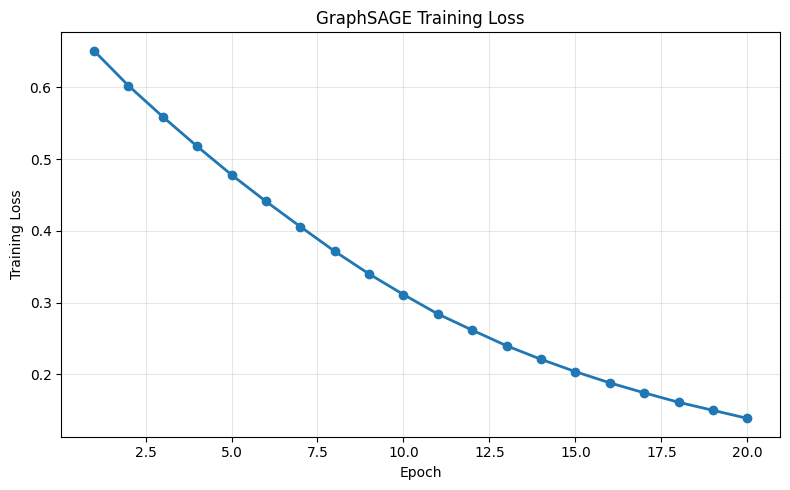

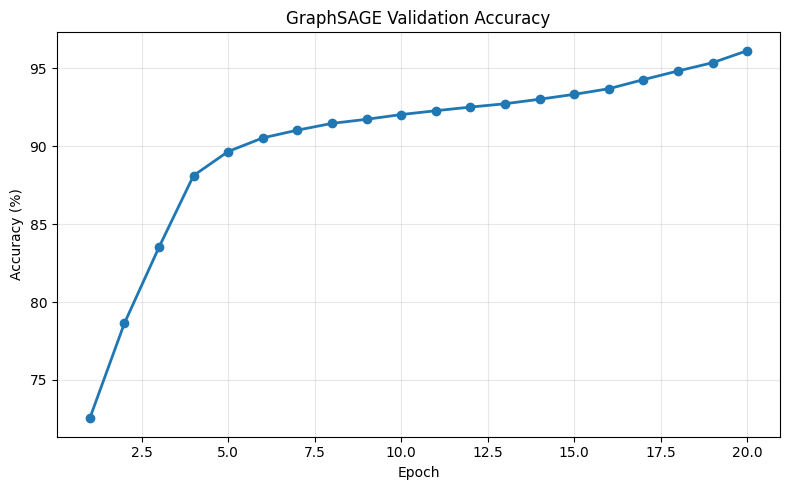

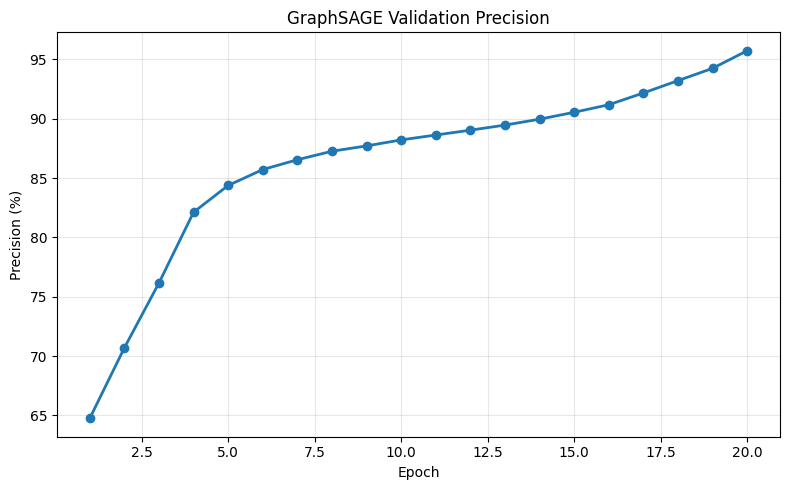

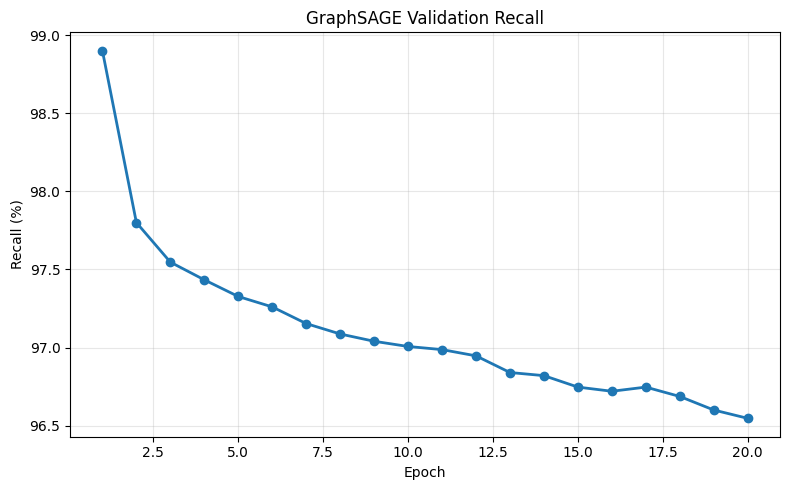

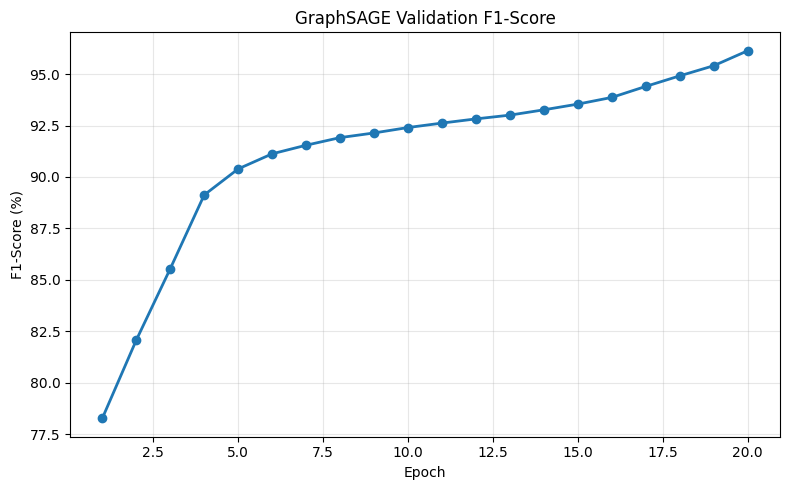

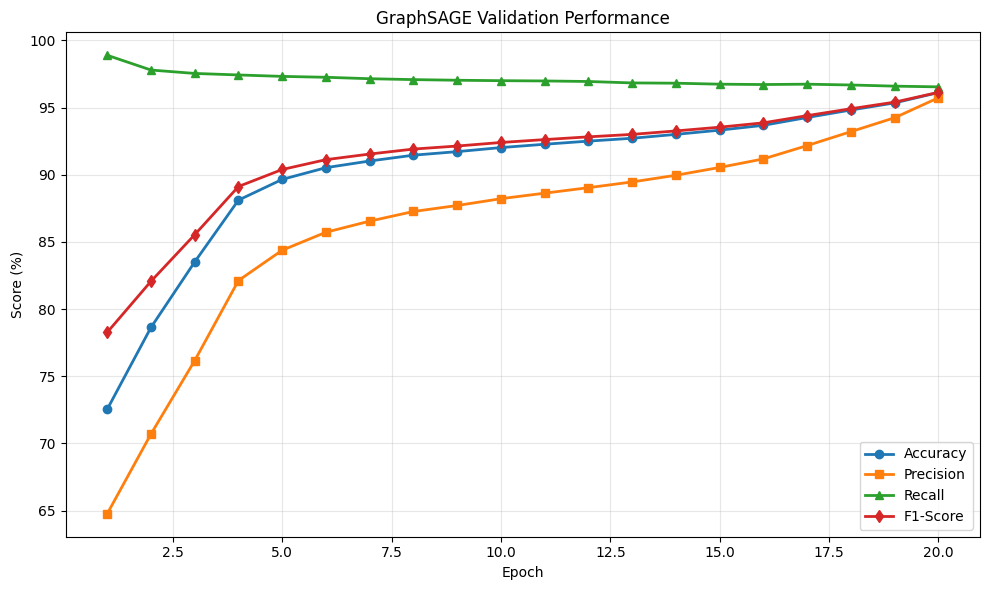

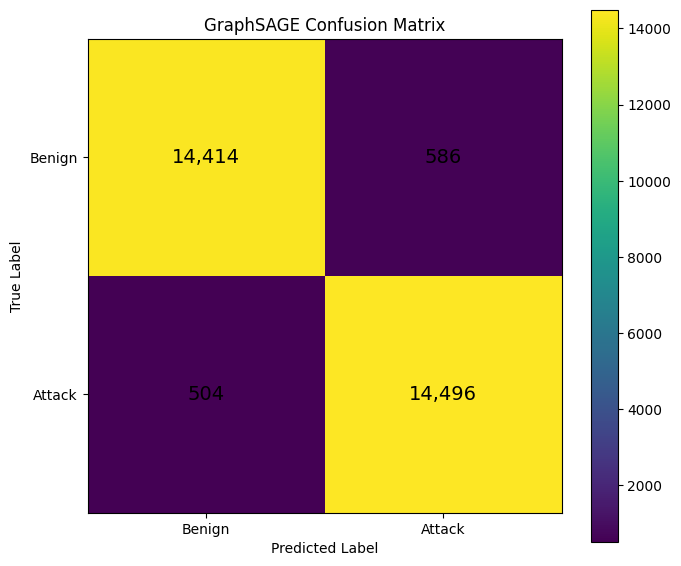

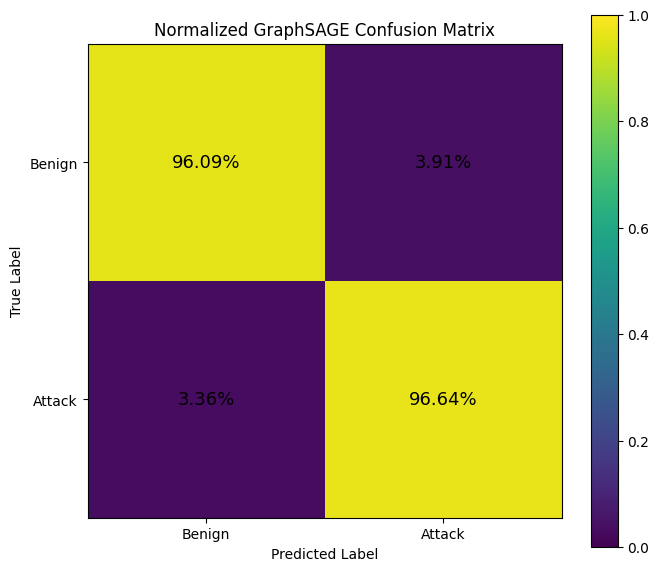

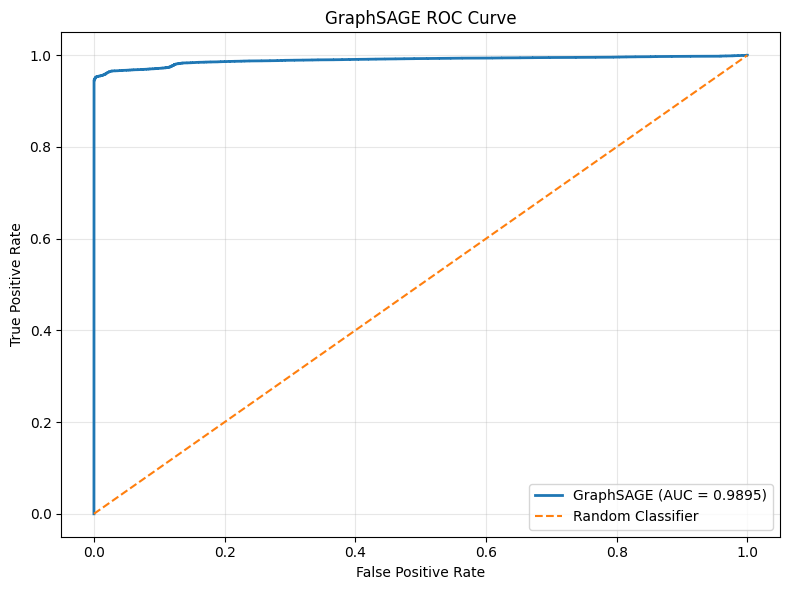

ROC-AUC = 0.989537


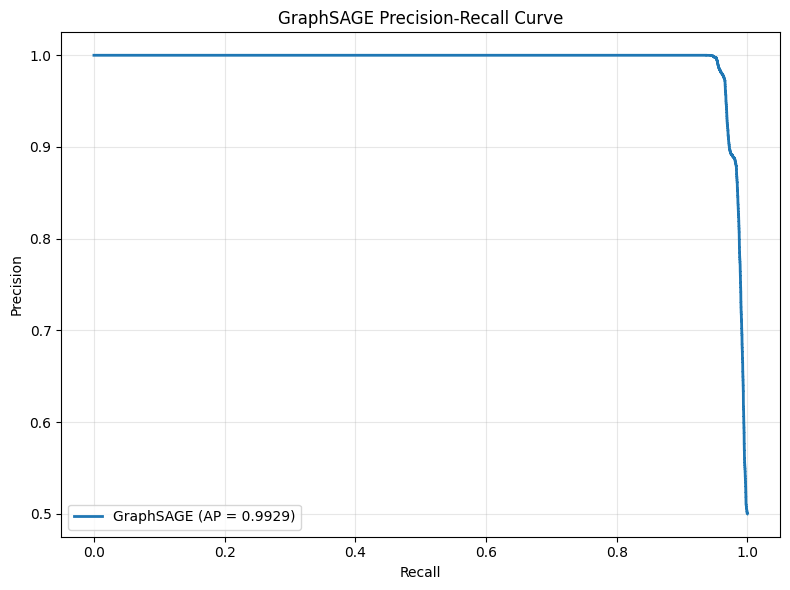

Average Precision = 0.992876


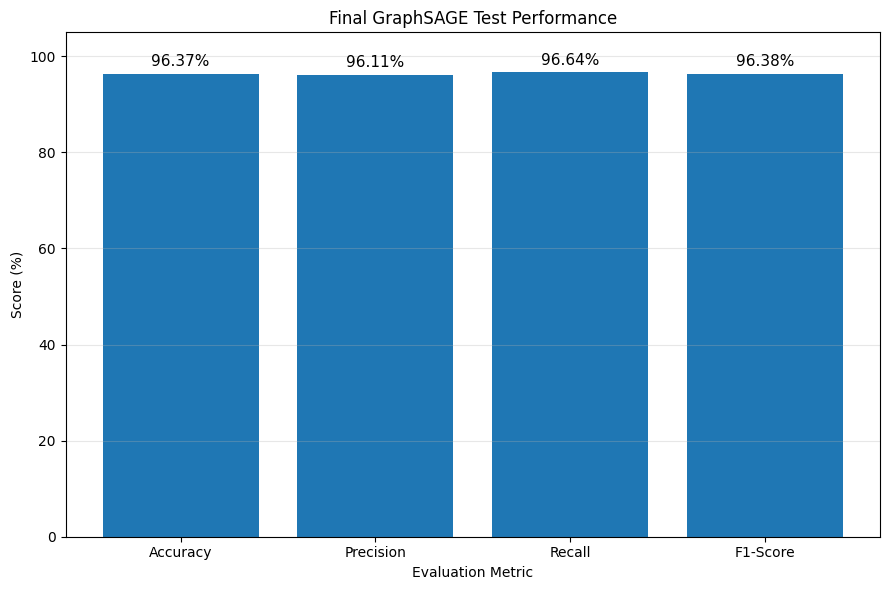

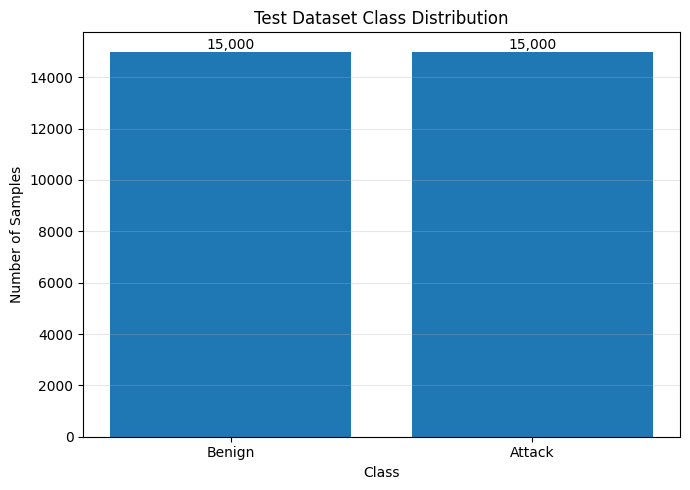

ALL GRAPHS GENERATED
Accuracy       : 0.9637
Precision      : 0.9611
Recall         : 0.9664
F1-Score       : 0.9638
ROC-AUC        : 0.9895
Average Precision: 0.9929

Saved figures:
✓ Figure_10_Precision_Recall_Curve.png
✓ Figure_11_Final_Metrics.png
✓ Figure_12_Class_Distribution.png
✓ Figure_1_Training_Loss.png
✓ Figure_2_Validation_Accuracy.png
✓ Figure_3_Validation_Precision.png
✓ Figure_4_Validation_Recall.png
✓ Figure_5_Validation_F1.png
✓ Figure_6_All_Validation_Metrics.png
✓ Figure_7_Confusion_Matrix.png
✓ Figure_8_Normalized_Confusion_Matrix.png
✓ Figure_9_ROC_Curve.png
✓ Training_Loss.png
✓ Training_vs_Validation_Accuracy.png
✓ Training_vs_Validation_F1.png
✓ Training_vs_Validation_Precision.png
✓ Training_vs_Validation_Recall.png

Location:
/content/drive/MyDrive/GraphSAGE_Figures


In [ ]:
# ============================================================
# STEP 33 — COMPLETE GRAPHSAGE VISUALIZATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

import os

FIG_DIR = "/content/drive/MyDrive/GraphSAGE_Figures"

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

print("Figures will be saved to:")
print(FIG_DIR)


# ============================================================
# CONVERT TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    TRAIN_HISTORY
)

print("\nTraining history:")
display(history_df)


# ============================================================
# FIGURE 1 — TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Epoch"],
    history_df["Train Loss"],
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "GraphSAGE Training Loss"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_1_Training_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 2 — VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Epoch"],
    history_df["Validation Accuracy"] * 100,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "GraphSAGE Validation Accuracy"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_2_Validation_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 3 — VALIDATION PRECISION
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Epoch"],
    history_df["Validation Precision"] * 100,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Precision (%)")

plt.title(
    "GraphSAGE Validation Precision"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_3_Validation_Precision.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 4 — VALIDATION RECALL
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Epoch"],
    history_df["Validation Recall"] * 100,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Recall (%)")

plt.title(
    "GraphSAGE Validation Recall"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_4_Validation_Recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 5 — VALIDATION F1
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Epoch"],
    history_df["Validation F1"] * 100,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("F1-Score (%)")

plt.title(
    "GraphSAGE Validation F1-Score"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_5_Validation_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 6 — ALL VALIDATION METRICS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["Epoch"],
    history_df["Validation Accuracy"] * 100,
    marker="o",
    linewidth=2,
    label="Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Precision"] * 100,
    marker="s",
    linewidth=2,
    label="Precision"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Recall"] * 100,
    marker="^",
    linewidth=2,
    label="Recall"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation F1"] * 100,
    marker="d",
    linewidth=2,
    label="F1-Score"
)

plt.xlabel("Epoch")
plt.ylabel("Score (%)")

plt.title(
    "GraphSAGE Validation Performance"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_6_All_Validation_Metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 7 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_true,
    test_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title(
    "GraphSAGE Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    ["Benign", "Attack"]
)

plt.yticks(
    [0, 1],
    ["Benign", "Attack"]
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_7_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 8 — NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = (
    cm.astype(float)
    /
    cm.sum(axis=1, keepdims=True)
)

plt.figure(figsize=(7, 6))

plt.imshow(
    cm_normalized,
    vmin=0,
    vmax=1
)

plt.title(
    "Normalized GraphSAGE Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    ["Benign", "Attack"]
)

plt.yticks(
    [0, 1],
    ["Benign", "Attack"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j] * 100:.2f}%",
            ha="center",
            va="center",
            fontsize=13
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_8_Normalized_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 9 — ROC CURVE
# ============================================================

# Convert logits into attack probability
test_probabilities = torch.softmax(
    test_logits,
    dim=1
)[:, 1].detach().cpu().numpy()

fpr, tpr, thresholds = roc_curve(
    test_true,
    test_probabilities
)

roc_auc = roc_auc_score(
    test_true,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"GraphSAGE (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "GraphSAGE ROC Curve"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_9_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"ROC-AUC = {roc_auc:.6f}"
)


# ============================================================
# FIGURE 10 — PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        test_true,
        test_probabilities
    )
)

average_precision = average_precision_score(
    test_true,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"GraphSAGE (AP = {average_precision:.4f})"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "GraphSAGE Precision-Recall Curve"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_10_Precision_Recall_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Average Precision = {average_precision:.6f}"
)


# ============================================================
# FIGURE 11 — FINAL METRICS BAR CHART
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

metric_values = [
    accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.ylabel(
    "Score (%)"
)

plt.xlabel(
    "Evaluation Metric"
)

plt.title(
    "Final GraphSAGE Test Performance"
)

plt.ylim(
    0,
    105
)

for bar, value in zip(
    bars,
    metric_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_11_Final_Metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 12 — CLASS DISTRIBUTION
# ============================================================

unique, counts = np.unique(
    test_true,
    return_counts=True
)

class_names = [
    "Benign" if x == 0 else "Attack"
    for x in unique
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_names,
    counts
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Test Dataset Class Distribution"
)

for bar, count in zip(
    bars,
    counts
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Figure_12_Class_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 80)
print("ALL GRAPHS GENERATED")
print("=" * 80)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")

print("\nSaved figures:")

for filename in sorted(os.listdir(FIG_DIR)):
    print("✓", filename)

print("\nLocation:")
print(FIG_DIR)

In [ ]:
# ============================================================
# STEP 28 — GRAPHSAGE TRAINING WITH TRAIN + VALIDATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

EPOCHS = 20

TRAIN_HISTORY = []

best_val_f1 = -1.0
best_state = None

print("=" * 100)
print("TRAINING GRAPHSAGE")
print("=" * 100)

for epoch in range(1, EPOCHS + 1):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    optimizer.zero_grad()

    logits, embeddings = model(
        graph_data.x,
        graph_data.edge_index
    )

    train_logits = logits[
        graph_data.train_mask
    ]

    train_targets = graph_data.y[
        graph_data.train_mask
    ]

    loss = criterion(
        train_logits,
        train_targets
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=5.0
    )

    optimizer.step()

    # --------------------------------------------------------
    # TRAINING PREDICTIONS
    # --------------------------------------------------------

    train_pred = (
        train_logits
        .argmax(dim=1)
        .detach()
        .cpu()
        .numpy()
    )

    train_true = (
        train_targets
        .detach()
        .cpu()
        .numpy()
    )

    train_accuracy = accuracy_score(
        train_true,
        train_pred
    )

    train_precision = precision_score(
        train_true,
        train_pred,
        zero_division=0
    )

    train_recall = recall_score(
        train_true,
        train_pred,
        zero_division=0
    )

    train_f1 = f1_score(
        train_true,
        train_pred,
        zero_division=0
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    with torch.no_grad():

        val_logits, _ = model(
            graph_data.x,
            graph_data.edge_index
        )

        val_logits = val_logits[
            graph_data.val_mask
        ]

        val_targets = graph_data.y[
            graph_data.val_mask
        ]

        val_pred = (
            val_logits
            .argmax(dim=1)
            .cpu()
            .numpy()
        )

        val_true = (
            val_targets
            .cpu()
            .numpy()
        )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_accuracy = accuracy_score(
        val_true,
        val_pred
    )

    val_precision = precision_score(
        val_true,
        val_pred,
        zero_division=0
    )

    val_recall = recall_score(
        val_true,
        val_pred,
        zero_division=0
    )

    val_f1 = f1_score(
        val_true,
        val_pred,
        zero_division=0
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }


    # ========================================================
    # SAVE TRAINING HISTORY
    # ========================================================

    TRAIN_HISTORY.append({

        "Epoch": epoch,

        "Train Loss": loss.item(),

        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,

        "Train Precision": train_precision,
        "Validation Precision": val_precision,

        "Train Recall": train_recall,
        "Validation Recall": val_recall,

        "Train F1": train_f1,
        "Validation F1": val_f1
    })


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Loss={loss.item():.5f} | "
        f"Train Acc={train_accuracy:.4f} | "
        f"Val Acc={val_accuracy:.4f} | "
        f"Train F1={train_f1:.4f} | "
        f"Val F1={val_f1:.4f}"
    )


print("\n" + "=" * 100)
print("TRAINING COMPLETE")
print("=" * 100)

print(
    f"Best Validation F1: {best_val_f1:.4f}"
)

TRAINING GRAPHSAGE
Epoch 01/20 | Loss=0.13049 | Train Acc=0.9617 | Val Acc=0.9689 | Train F1=0.9618 | Val F1=0.9687
Epoch 02/20 | Loss=0.11987 | Train Acc=0.9679 | Val Acc=0.9743 | Train F1=0.9678 | Val F1=0.9741
Epoch 03/20 | Loss=0.11344 | Train Acc=0.9720 | Val Acc=0.9777 | Train F1=0.9719 | Val F1=0.9774
Epoch 04/20 | Loss=0.10709 | Train Acc=0.9759 | Val Acc=0.9794 | Train F1=0.9757 | Val F1=0.9791
Epoch 05/20 | Loss=0.10177 | Train Acc=0.9782 | Val Acc=0.9801 | Train F1=0.9779 | Val F1=0.9797
Epoch 06/20 | Loss=0.09559 | Train Acc=0.9797 | Val Acc=0.9803 | Train F1=0.9795 | Val F1=0.9800
Epoch 07/20 | Loss=0.09236 | Train Acc=0.9806 | Val Acc=0.9805 | Train F1=0.9803 | Val F1=0.9801
Epoch 08/20 | Loss=0.08847 | Train Acc=0.9813 | Val Acc=0.9805 | Train F1=0.9810 | Val F1=0.9802
Epoch 09/20 | Loss=0.08460 | Train Acc=0.9822 | Val Acc=0.9807 | Train F1=0.9820 | Val F1=0.9803
Epoch 10/20 | Loss=0.08271 | Train Acc=0.9833 | Val Acc=0.9835 | Train F1=0.9830 | Val F1=0.9833
Epoch 11/20

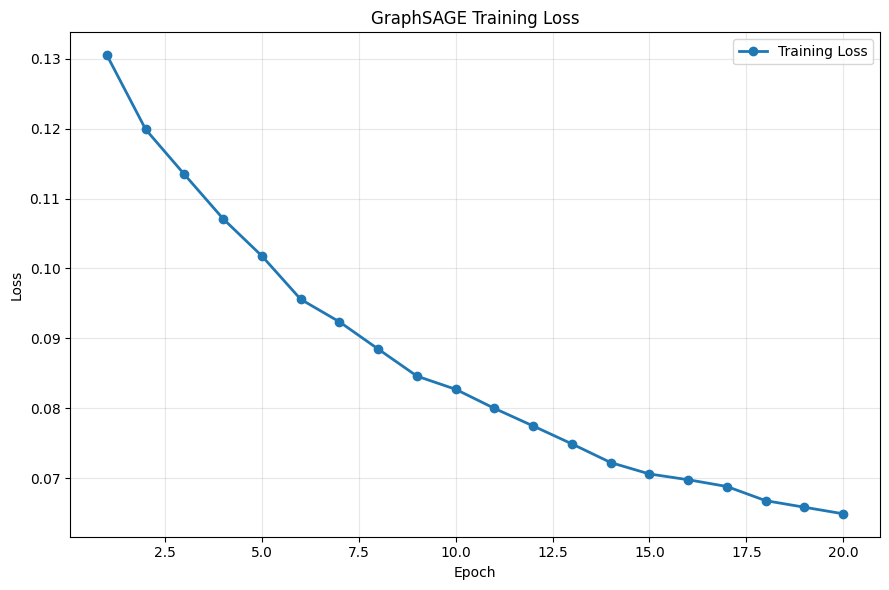

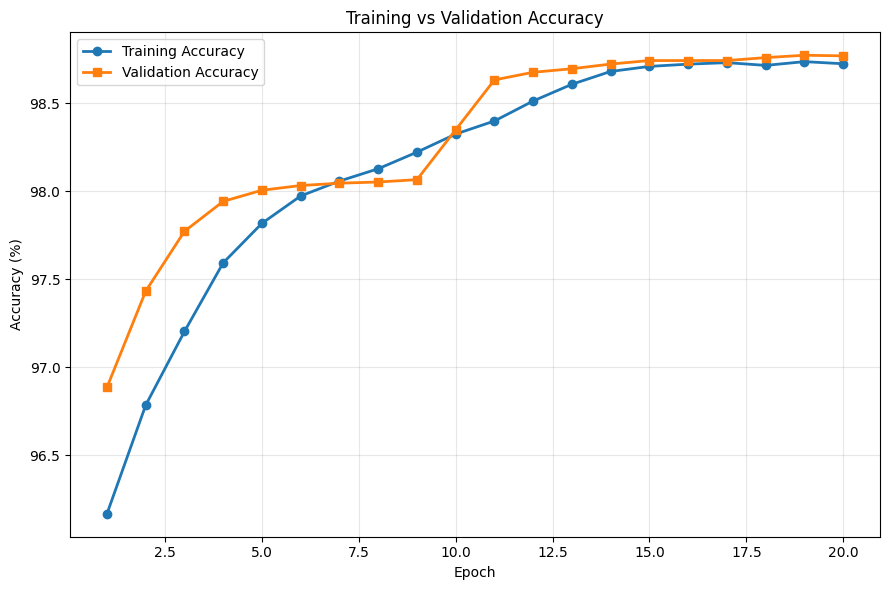

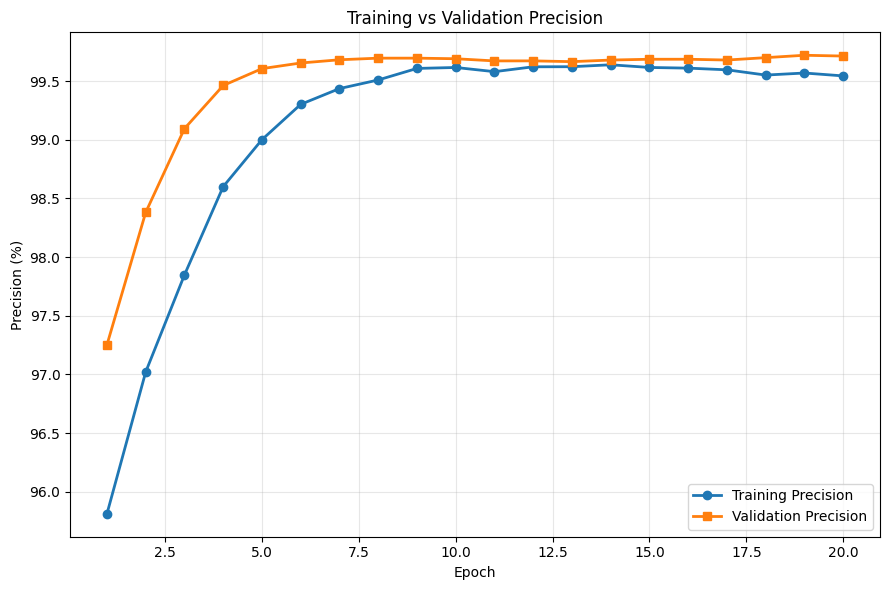

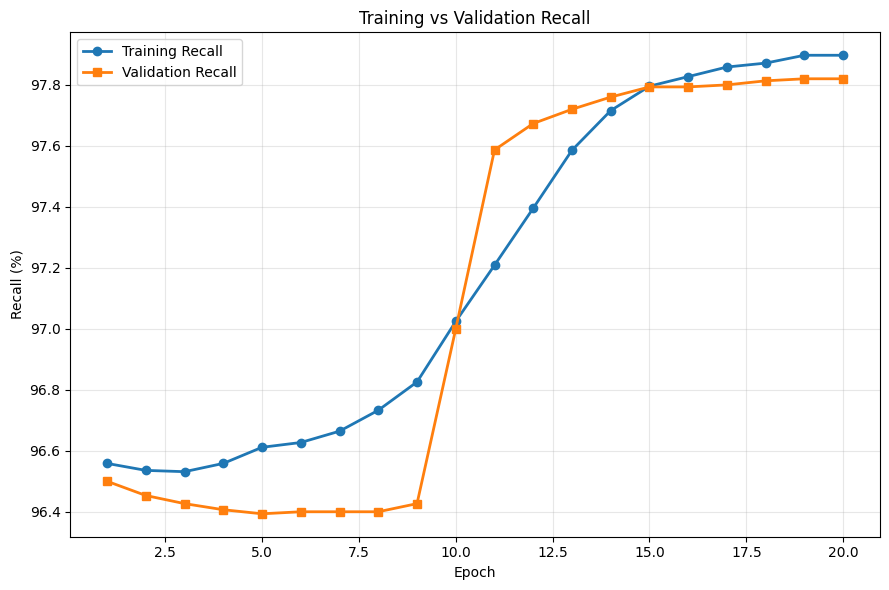

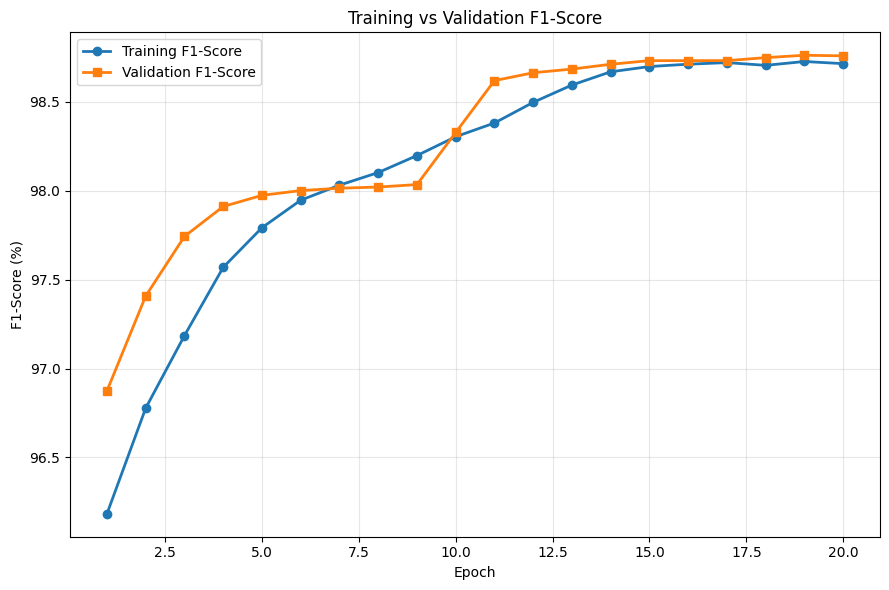

TRAINING HISTORY


,Epoch,Train Loss,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1
0,1,0.13049,0.9617,0.9689,0.9581,0.9725,0.9656,0.9650,0.9618,0.9687
1,2,0.11987,0.9679,0.9743,0.9702,0.9838,0.9654,0.9645,0.9678,0.9741
2,3,0.11344,0.9720,0.9777,0.9785,0.9910,0.9653,0.9643,0.9719,0.9774
3,4,0.10709,0.9759,0.9794,0.9860,0.9946,0.9656,0.9641,0.9757,0.9791
4,5,0.10177,0.9782,0.9801,0.9900,0.9961,0.9661,0.9639,0.9779,0.9797
5,6,0.09559,0.9797,0.9803,0.9930,0.9966,0.9663,0.9640,0.9795,0.9800
6,7,0.09236,0.9806,0.9805,0.9944,0.9968,0.9666,0.9640,0.9803,0.9801
7,8,0.08847,0.9813,0.9805,0.9951,0.9970,0.9673,0.9640,0.9810,0.9802
8,9,0.08460,0.9822,0.9807,0.9961,0.9970,0.9683,0.9643,0.9820,0.9803
9,10,0.08271,0.9833,0.9835,0.9962,0.9969,0.9702,0.9700,0.9830,0.9833


In [ ]:
# ============================================================
# STEP 33 — TRAINING VS VALIDATION GRAPHS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

history_df = pd.DataFrame(
    TRAIN_HISTORY
)

FIG_DIR = "/content/drive/MyDrive/GraphSAGE_Figures"

os.makedirs(
    FIG_DIR,
    exist_ok=True
)


# ============================================================
# GRAPH 1 — LOSS
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["Epoch"],
    history_df["Train Loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

# Validation loss is not currently calculated
# Therefore only training loss is plotted here.

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "GraphSAGE Training Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Training_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 2 — ACCURACY
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["Epoch"],
    history_df["Train Accuracy"] * 100,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Accuracy"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Training_vs_Validation_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 3 — PRECISION
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["Epoch"],
    history_df["Train Precision"] * 100,
    marker="o",
    linewidth=2,
    label="Training Precision"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Precision"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Precision"
)

plt.xlabel("Epoch")
plt.ylabel("Precision (%)")

plt.title(
    "Training vs Validation Precision"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Training_vs_Validation_Precision.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 4 — RECALL
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["Epoch"],
    history_df["Train Recall"] * 100,
    marker="o",
    linewidth=2,
    label="Training Recall"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Recall"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall (%)")

plt.title(
    "Training vs Validation Recall"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Training_vs_Validation_Recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 5 — F1 SCORE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["Epoch"],
    history_df["Train F1"] * 100,
    marker="o",
    linewidth=2,
    label="Training F1-Score"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation F1"] * 100,
    marker="s",
    linewidth=2,
    label="Validation F1-Score"
)

plt.xlabel("Epoch")
plt.ylabel("F1-Score (%)")

plt.title(
    "Training vs Validation F1-Score"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/Training_vs_Validation_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# DISPLAY HISTORY
# ============================================================

print("=" * 80)
print("TRAINING HISTORY")
print("=" * 80)

display(
    history_df.style.format({
        "Train Loss": "{:.5f}",
        "Train Accuracy": "{:.4f}",
        "Validation Accuracy": "{:.4f}",
        "Train Precision": "{:.4f}",
        "Validation Precision": "{:.4f}",
        "Train Recall": "{:.4f}",
        "Validation Recall": "{:.4f}",
        "Train F1": "{:.4f}",
        "Validation F1": "{:.4f}"
    })
)

In [ ]:
# ============================================================
# STEP 35 — EXTRACT LOCAL GNN / GRAPHSAGE EMBEDDINGS
# ============================================================

import torch
import numpy as np
import pandas as pd

print("=" * 80)
print("EXTRACTING GRAPHSAGE NODE EMBEDDINGS")
print("=" * 80)

# ------------------------------------------------------------
# Restore best GraphSAGE model
# ------------------------------------------------------------

if best_state is not None:

    model.load_state_dict(best_state)
    model = model.to(DEVICE)

    print("✓ Best GraphSAGE model restored.")

else:

    print(
        "WARNING: best_state is not available. "
        "Using current GraphSAGE model."
    )


# ------------------------------------------------------------
# Evaluation mode
# ------------------------------------------------------------

model.eval()


# ------------------------------------------------------------
# Generate embeddings
# ------------------------------------------------------------

with torch.no_grad():

    graph_logits, graph_embeddings = model(
        graph_data.x,
        graph_data.edge_index
    )


# ------------------------------------------------------------
# Move embeddings to CPU
# ------------------------------------------------------------

graph_embeddings = (
    graph_embeddings
    .detach()
    .cpu()
    .numpy()
    .astype(np.float32)
)

graph_labels = (
    graph_data.y
    .detach()
    .cpu()
    .numpy()
    .astype(np.int64)
)


print("\nGraphSAGE embedding shape:")
print(graph_embeddings.shape)

print("\nExpected:")
print("(200000, 64)")

print("\n✓ Local GNN embeddings successfully extracted.")

EXTRACTING GRAPHSAGE NODE EMBEDDINGS
✓ Best GraphSAGE model restored.

GraphSAGE embedding shape:
(200000, 64)

Expected:
(200000, 64)

✓ Local GNN embeddings successfully extracted.


In [ ]:
# ============================================================
# STEP 26 — BUILD GRAPH DATA FOR GRAPHSAGE
# ============================================================

import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

print("=" * 80)
print("BUILDING GRAPH FOR GRAPHSAGE")
print("=" * 80)


# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required = [
    "X_train_scaled",
    "X_val_scaled",
    "X_test_scaled",
    "y_train",
    "y_val",
    "y_test"
]

missing = [
    name for name in required
    if name not in globals()
]

if missing:
    raise NameError(
        "The following variables are missing: "
        + str(missing)
        + "\nRun your train/validation/test split cell first."
    )


# ------------------------------------------------------------
# 2. CONVERT LABELS TO NUMPY
# ------------------------------------------------------------

def convert_labels(y):

    if isinstance(y, pd.Series):
        return y.to_numpy()

    if isinstance(y, pd.DataFrame):
        return y.iloc[:, 0].to_numpy()

    if torch.is_tensor(y):
        return y.detach().cpu().numpy()

    return np.asarray(y)


y_train_np = convert_labels(y_train)
y_val_np   = convert_labels(y_val)
y_test_np  = convert_labels(y_test)


# ------------------------------------------------------------
# 3. COMBINE DATA
# ------------------------------------------------------------

X_all = np.concatenate(
    [
        X_train_scaled,
        X_val_scaled,
        X_test_scaled
    ],
    axis=0
).astype(np.float32)


y_all = np.concatenate(
    [
        y_train_np,
        y_val_np,
        y_test_np
    ],
    axis=0
)


# Make sure labels are integer
y_all = y_all.astype(np.int64)


# ------------------------------------------------------------
# 4. CREATE TRAIN / VALIDATION / TEST INDICES
# ------------------------------------------------------------

n_train = len(X_train_scaled)
n_val   = len(X_val_scaled)
n_test  = len(X_test_scaled)

train_indices = np.arange(
    0,
    n_train
)

val_indices = np.arange(
    n_train,
    n_train + n_val
)

test_indices = np.arange(
    n_train + n_val,
    n_train + n_val + n_test
)


print("Total nodes:", len(X_all))
print("Training nodes:", len(train_indices))
print("Validation nodes:", len(val_indices))
print("Testing nodes:", len(test_indices))


# ------------------------------------------------------------
# 5. CREATE kNN GRAPH
# ------------------------------------------------------------

# Keep this moderate because you are currently using CPU
K_NEIGHBORS = 10

print("\nBuilding kNN graph...")
print("k =", K_NEIGHBORS)

knn = NearestNeighbors(
    n_neighbors=K_NEIGHBORS + 1,
    metric="euclidean",
    n_jobs=-1
)

knn.fit(X_all)

distances, neighbors = knn.kneighbors(
    X_all
)


# ------------------------------------------------------------
# 6. CREATE EDGE LIST
# ------------------------------------------------------------

source_nodes = []
target_nodes = []

for i in range(len(X_all)):

    # neighbors[0] is the node itself
    for j in neighbors[i, 1:]:

        source_nodes.append(i)
        target_nodes.append(j)


edge_index = torch.tensor(
    [
        source_nodes,
        target_nodes
    ],
    dtype=torch.long
)


# ------------------------------------------------------------
# 7. CREATE PYTORCH GEOMETRIC DATA OBJECT
# ------------------------------------------------------------

x_tensor = torch.tensor(
    X_all,
    dtype=torch.float32
)

y_tensor = torch.tensor(
    y_all,
    dtype=torch.long
)


train_mask = torch.zeros(
    len(X_all),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(X_all),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(X_all),
    dtype=torch.bool
)


train_mask[train_indices] = True
val_mask[val_indices] = True
test_mask[test_indices] = True


graph_data = Data(
    x=x_tensor,
    y=y_tensor,
    edge_index=edge_index,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)


# ------------------------------------------------------------
# 8. DISPLAY GRAPH INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GRAPH CREATED SUCCESSFULLY")
print("=" * 80)

print(
    "Number of nodes:",
    graph_data.num_nodes
)

print(
    "Number of features:",
    graph_data.num_features
)

print(
    "Number of edges:",
    graph_data.num_edges
)

print(
    "Feature matrix:",
    graph_data.x.shape
)

print(
    "Label vector:",
    graph_data.y.shape
)

print(
    "Training nodes:",
    int(graph_data.train_mask.sum())
)

print(
    "Validation nodes:",
    int(graph_data.val_mask.sum())
)

print(
    "Testing nodes:",
    int(graph_data.test_mask.sum())
)

print("\nLabel distribution:")

unique, counts = torch.unique(
    graph_data.y,
    return_counts=True
)

for label, count in zip(unique, counts):

    print(
        f"Class {int(label)}: "
        f"{int(count)} samples"
    )

print("\n✓ graph_data is ready.")

BUILDING GRAPH FOR GRAPHSAGE
Total nodes: 200000
Training nodes: 140000
Validation nodes: 30000
Testing nodes: 30000

Building kNN graph...
k = 10

GRAPH CREATED SUCCESSFULLY
Number of nodes: 200000
Number of features: 46
Number of edges: 2000000
Feature matrix: torch.Size([200000, 46])
Label vector: torch.Size([200000])
Training nodes: 140000
Validation nodes: 30000
Testing nodes: 30000

Label distribution:
Class 0: 100000 samples
Class 1: 100000 samples

✓ graph_data is ready.


In [ ]:
# ============================================================
# NOVEL MODEL
# Adaptive Local GraphSAGE + Feature Attention + BiLSTM
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv


class AdaptiveLocalGNNBiLSTM(nn.Module):

    def __init__(
        self,
        input_dim=46,
        gnn_hidden=128,
        embedding_dim=64,
        lstm_hidden=128,
        lstm_layers=2,
        num_classes=2,
        dropout=0.30
    ):

        super().__init__()

        self.input_dim = input_dim
        self.embedding_dim = embedding_dim

        # ====================================================
        # 1. FEATURE ATTENTION
        # ====================================================

        self.feature_attention = nn.Sequential(

            nn.Linear(
                input_dim,
                input_dim
            ),

            nn.ReLU(),

            nn.Linear(
                input_dim,
                input_dim
            ),

            nn.Sigmoid()
        )

        # ====================================================
        # 2. LOCAL GRAPHSAGE
        # ====================================================

        self.sage1 = SAGEConv(
            input_dim,
            gnn_hidden
        )

        self.sage2 = SAGEConv(
            gnn_hidden,
            embedding_dim
        )

        # ====================================================
        # 3. RESIDUAL PROJECTION
        # ====================================================

        self.residual_projection = nn.Linear(
            input_dim,
            embedding_dim
        )

        # ====================================================
        # 4. NORMALIZATION
        # ====================================================

        self.norm1 = nn.BatchNorm1d(
            gnn_hidden
        )

        self.norm2 = nn.BatchNorm1d(
            embedding_dim
        )

        # ====================================================
        # 5. BILSTM
        # ====================================================

        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
            if lstm_layers > 1
            else 0
        )

        # ====================================================
        # 6. TEMPORAL ATTENTION
        # ====================================================

        self.temporal_attention = nn.Sequential(

            nn.Linear(
                lstm_hidden * 2,
                64
            ),

            nn.Tanh(),

            nn.Linear(
                64,
                1
            )
        )

        # ====================================================
        # 7. FUSION
        # ====================================================

        self.fusion = nn.Sequential(

            nn.Linear(
                embedding_dim + lstm_hidden * 2,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout)
        )

        # ====================================================
        # 8. CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                64,
                num_classes
            )
        )


    def forward_gnn(
        self,
        x,
        edge_index
    ):

        # ====================================================
        # Feature attention
        # ====================================================

        attention_weights = (
            self.feature_attention(x)
        )

        x_attended = (
            x * attention_weights
        )

        # ====================================================
        # Residual branch
        # ====================================================

        residual = self.residual_projection(
            x_attended
        )

        # ====================================================
        # GraphSAGE layer 1
        # ====================================================

        x = self.sage1(
            x_attended,
            edge_index
        )

        x = self.norm1(x)

        x = F.relu(x)

        # ====================================================
        # GraphSAGE layer 2
        # ====================================================

        x = self.sage2(
            x,
            edge_index
        )

        x = self.norm2(x)

        # ====================================================
        # Residual fusion
        # ====================================================

        x = x + residual

        x = F.relu(x)

        return x, attention_weights


    def forward_sequence(
        self,
        sequences
    ):

        # ====================================================
        # BiLSTM
        # ====================================================

        lstm_output, _ = self.bilstm(
            sequences
        )

        # ====================================================
        # Temporal attention
        # ====================================================

        attention_scores = (
            self.temporal_attention(
                lstm_output
            )
        )

        attention_weights = torch.softmax(
            attention_scores,
            dim=1
        )

        temporal_embedding = torch.sum(
            lstm_output * attention_weights,
            dim=1
        )

        return (
            temporal_embedding,
            attention_weights
        )


    def classify(
        self,
        gnn_embedding,
        temporal_embedding
    ):

        # ====================================================
        # Spatial + temporal fusion
        # ====================================================

        fused = torch.cat(
            [
                gnn_embedding,
                temporal_embedding
            ],
            dim=1
        )

        fused = self.fusion(
            fused
        )

        logits = self.classifier(
            fused
        )

        return logits, fused


    def forward(
        self,
        x,
        edge_index,
        sequences=None
    ):

        gnn_embedding, feature_attention = (
            self.forward_gnn(
                x,
                edge_index
            )
        )

        if sequences is None:

            logits = self.classifier(
                self.fusion(
                    torch.cat(
                        [
                            gnn_embedding,
                            torch.zeros(
                                gnn_embedding.size(0),
                                self.bilstm.hidden_size * 2,
                                device=gnn_embedding.device
                            )
                        ],
                        dim=1
                    )
                )
            )

            return (
                logits,
                gnn_embedding,
                feature_attention
            )

        temporal_embedding, temporal_attention = (
            self.forward_sequence(
                sequences
            )
        )

        return (
            temporal_embedding,
            feature_attention,
            temporal_attention
        )

In [ ]:
# ============================================================
# STEP 33A — NOVEL LOCAL GNN + BiLSTM MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# MODEL
# ============================================================

class NovelTemporalClassifier(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=128,
        embedding_dim=64,
        num_layers=2,
        num_classes=2,
        dropout=0.30
    ):

        super().__init__()


        # ====================================================
        # LOCAL GRAPH NEURAL NETWORK
        # ====================================================

        self.gnn1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.gnn2 = SAGEConv(
            hidden_dim,
            embedding_dim
        )


        # ====================================================
        # NORMALIZATION
        # ====================================================

        self.norm1 = nn.LayerNorm(
            hidden_dim
        )

        self.norm2 = nn.LayerNorm(
            embedding_dim
        )


        # ====================================================
        # LOCAL ATTENTION
        # ====================================================

        self.attention = nn.Sequential(

            nn.Linear(
                embedding_dim,
                embedding_dim // 2
            ),

            nn.Tanh(),

            nn.Linear(
                embedding_dim // 2,
                1
            )
        )


        # ====================================================
        # BIDIRECTIONAL LSTM
        # ====================================================

        self.bilstm = nn.LSTM(

            input_size=embedding_dim,

            hidden_size=hidden_dim,

            num_layers=num_layers,

            batch_first=True,

            bidirectional=True,

            dropout=dropout if num_layers > 1 else 0
        )


        # ====================================================
        # TEMPORAL ATTENTION
        # ====================================================

        self.temporal_attention = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),

            nn.Tanh(),

            nn.Linear(
                hidden_dim,
                1
            )
        )


        # ====================================================
        # RESIDUAL FUSION
        # ====================================================

        self.gnn_projection = nn.Linear(

            embedding_dim,

            hidden_dim * 2
        )


        self.fusion = nn.Sequential(

            nn.Linear(
                hidden_dim * 4,
                hidden_dim * 2
            ),

            nn.ReLU(),

            nn.Dropout(dropout)
        )


        # ====================================================
        # CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim,
                num_classes
            )
        )


        self.dropout = nn.Dropout(
            dropout
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x,
        edge_index=None
    ):

        # ----------------------------------------------------
        # GRAPH LAYER
        # ----------------------------------------------------

        if edge_index is not None:

            x1 = self.gnn1(
                x,
                edge_index
            )

        else:

            x1 = self.gnn1(
                x
            )


        x1 = self.norm1(
            x1
        )

        x1 = F.relu(
            x1
        )

        x1 = self.dropout(
            x1
        )


        # ----------------------------------------------------
        # SECOND GRAPH LAYER
        # ----------------------------------------------------

        if edge_index is not None:

            x2 = self.gnn2(
                x1,
                edge_index
            )

        else:

            x2 = self.gnn2(
                x1
            )


        x2 = self.norm2(
            x2
        )

        x2 = F.relu(
            x2
        )


        # ----------------------------------------------------
        # GRAPH ATTENTION
        # ----------------------------------------------------

        attention_scores = self.attention(
            x2
        )

        attention_weights = torch.softmax(
            attention_scores,
            dim=0
        )

        attended = (
            x2 *
            attention_weights
        )


        # ----------------------------------------------------
        # SEQUENCE INPUT
        #
        # If input is [N, F], convert to [N, 1, F]
        # ----------------------------------------------------

        if attended.dim() == 2:

            sequence = attended.unsqueeze(
                1
            )

        else:

            sequence = attended


        # ----------------------------------------------------
        # BiLSTM
        # ----------------------------------------------------

        lstm_output, _ = self.bilstm(
            sequence
        )


        # ----------------------------------------------------
        # TEMPORAL ATTENTION
        # ----------------------------------------------------

        temporal_scores = (
            self.temporal_attention(
                lstm_output
            )
        )

        temporal_weights = torch.softmax(
            temporal_scores,
            dim=1
        )


        temporal_context = (
            lstm_output *
            temporal_weights
        ).sum(
            dim=1
        )


        # ----------------------------------------------------
        # GNN RESIDUAL REPRESENTATION
        # ----------------------------------------------------

        gnn_residual = self.gnn_projection(
            x2
        )


        # ----------------------------------------------------
        # RESIDUAL FUSION
        # ----------------------------------------------------

        fused = torch.cat(
            [
                temporal_context,
                gnn_residual
            ],
            dim=1
        )


        fused = self.fusion(
            fused
        )


        # ----------------------------------------------------
        # CLASSIFICATION
        # ----------------------------------------------------

        output = self.classifier(
            fused
        )


        return output


# ============================================================
# TEST MODEL CREATION
# ============================================================

novel_model = NovelTemporalClassifier(

    input_dim=graph_data.num_features,

    hidden_dim=128,

    embedding_dim=64,

    num_layers=2,

    num_classes=2,

    dropout=0.30

).to(DEVICE)


# ============================================================
# MODEL INFORMATION
# ============================================================

print("=" * 90)
print("NOVEL MODEL CREATED SUCCESSFULLY")
print("=" * 90)

print(novel_model)


# ============================================================
# PARAMETER COUNT
# ============================================================

total_parameters = sum(
    p.numel()
    for p in novel_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in novel_model.parameters()
    if p.requires_grad
)

print("\nTotal parameters:",
      f"{total_parameters:,}")

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Device: cpu
NOVEL MODEL CREATED SUCCESSFULLY
NovelTemporalClassifier(
  (gnn1): SAGEConv(46, 128, aggr=mean)
  (gnn2): SAGEConv(128, 64, aggr=mean)
  (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attention): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (bilstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (temporal_attention): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (gnn_projection): Linear(in_features=64, out_features=256, bias=True)
  (fusion): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_featur

In [ ]:
# ============================================================
# STEP 33B — VERIFY GRAPH DATA
# ============================================================

print("=" * 80)
print("GRAPH VERIFICATION")
print("=" * 80)

print("Nodes:",
      graph_data.x.shape[0])

print("Features:",
      graph_data.x.shape[1])

print("Edges:",
      graph_data.edge_index.shape[1])

print("Labels:",
      graph_data.y.shape)

print("\nTrain nodes:",
      graph_data.train_mask.sum().item())

print("Validation nodes:",
      graph_data.val_mask.sum().item())

print("Test nodes:",
      graph_data.test_mask.sum().item())

print("\nClass distribution:")

unique, counts = torch.unique(
    graph_data.y,
    return_counts=True
)

for cls, count in zip(
    unique.cpu().numpy(),
    counts.cpu().numpy()
):

    print(
        f"Class {cls}: {count:,}"
    )

GRAPH VERIFICATION
Nodes: 200000
Features: 46
Edges: 2000000
Labels: torch.Size([200000])

Train nodes: 140000
Validation nodes: 30000
Test nodes: 30000

Class distribution:
Class 0: 100,000
Class 1: 100,000


In [ ]:
# ============================================================
# STEP 34 — TRAIN PROPOSED LOCAL GNN + BiLSTM MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ------------------------------------------------------------
# Move graph to device
# ------------------------------------------------------------

graph_data = graph_data.to(DEVICE)


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

novel_model = NovelTemporalClassifier(
    input_dim=graph_data.num_features,
    hidden_dim=128,
    embedding_dim=64,
    num_layers=2,
    num_classes=2,
    dropout=0.30
).to(DEVICE)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    novel_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)


# ------------------------------------------------------------
# Scheduler
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

EPOCHS = 30

PATIENCE = 7

best_val_f1 = -1.0

best_epoch = 0

patience_counter = 0


# ------------------------------------------------------------
# History
# ------------------------------------------------------------

TRAIN_HISTORY = []


# ------------------------------------------------------------
# Model save path
# ------------------------------------------------------------

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "FedGRAI_LocalGNN_BiLSTM_Best.pt"
)


# ============================================================
# TRAINING LOOP
# ============================================================

print("=" * 100)
print("STARTING TRAINING")
print("=" * 100)


for epoch in range(1, EPOCHS + 1):

    # ========================================================
    # TRAIN
    # ========================================================

    novel_model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    logits = novel_model(
        graph_data.x,
        graph_data.edge_index
    )

    train_logits = logits[
        graph_data.train_mask
    ]

    train_labels = graph_data.y[
        graph_data.train_mask
    ]

    train_loss = criterion(
        train_logits,
        train_labels
    )

    train_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        novel_model.parameters(),
        max_norm=5.0
    )

    optimizer.step()


    # ========================================================
    # TRAIN PREDICTIONS
    # ========================================================

    train_predictions = torch.argmax(
        train_logits.detach(),
        dim=1
    )


    train_true_np = (
        train_labels.detach()
        .cpu()
        .numpy()
    )

    train_pred_np = (
        train_predictions.cpu()
        .numpy()
    )


    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_accuracy = accuracy_score(
        train_true_np,
        train_pred_np
    )

    train_precision = precision_score(
        train_true_np,
        train_pred_np,
        zero_division=0
    )

    train_recall = recall_score(
        train_true_np,
        train_pred_np,
        zero_division=0
    )

    train_f1 = f1_score(
        train_true_np,
        train_pred_np,
        zero_division=0
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    novel_model.eval()

    with torch.no_grad():

        validation_logits = novel_model(
            graph_data.x,
            graph_data.edge_index
        )

        val_logits = validation_logits[
            graph_data.val_mask
        ]

        val_labels = graph_data.y[
            graph_data.val_mask
        ]

        val_loss = criterion(
            val_logits,
            val_labels
        )


        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_true_np = (
        val_labels.cpu()
        .numpy()
    )

    val_pred_np = (
        val_predictions.cpu()
        .numpy()
    )


    val_accuracy = accuracy_score(
        val_true_np,
        val_pred_np
    )

    val_precision = precision_score(
        val_true_np,
        val_pred_np,
        zero_division=0
    )

    val_recall = recall_score(
        val_true_np,
        val_pred_np,
        zero_division=0
    )

    val_f1 = f1_score(
        val_true_np,
        val_pred_np,
        zero_division=0
    )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step(
        val_f1
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ========================================================
    # STORE HISTORY
    # ========================================================

    TRAIN_HISTORY.append({

        "Epoch": epoch,

        "Train Loss":
            train_loss.item(),

        "Validation Loss":
            val_loss.item(),

        "Train Accuracy":
            train_accuracy,

        "Validation Accuracy":
            val_accuracy,

        "Train Precision":
            train_precision,

        "Validation Precision":
            val_precision,

        "Train Recall":
            train_recall,

        "Validation Recall":
            val_recall,

        "Train F1":
            train_f1,

        "Validation F1":
            val_f1,

        "Learning Rate":
            current_lr
    })


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_epoch = epoch

        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    novel_model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "validation_f1":
                    val_f1,

                "validation_accuracy":
                    val_accuracy,

                "validation_precision":
                    val_precision,

                "validation_recall":
                    val_recall
            },
            MODEL_PATH
        )

    else:

        patience_counter += 1


    # ========================================================
    # PRINT EPOCH
    # ========================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss.item():.5f} | "
        f"Val Loss: {val_loss.item():.5f} | "
        f"Train Acc: {train_accuracy*100:.2f}% | "
        f"Val Acc: {val_accuracy*100:.2f}% | "
        f"Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= PATIENCE:

        print(
            "\nEarly stopping activated."
        )

        break


# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\n" + "=" * 100)
print("TRAINING COMPLETED")
print("=" * 100)

print(
    "Best Epoch:",
    best_epoch
)

print(
    "Best Validation F1:",
    f"{best_val_f1:.4f}"
)

print(
    "Saved Model:",
    MODEL_PATH
)

Device: cpu
STARTING TRAINING
Epoch 01/30 | Train Loss: 0.69228 | Val Loss: 0.63636 | Train Acc: 50.06% | Val Acc: 76.11% | Train F1: 0.6666 | Val F1: 0.8060 | LR: 0.001000
Epoch 02/30 | Train Loss: 0.64750 | Val Loss: 0.57480 | Train Acc: 65.74% | Val Acc: 86.96% | Train F1: 0.7437 | Val F1: 0.8822 | LR: 0.001000
Epoch 03/30 | Train Loss: 0.59249 | Val Loss: 0.49962 | Train Acc: 83.74% | Val Acc: 89.44% | Train F1: 0.8579 | Val F1: 0.9020 | LR: 0.001000
Epoch 04/30 | Train Loss: 0.52051 | Val Loss: 0.41784 | Train Acc: 88.34% | Val Acc: 90.97% | Train F1: 0.8932 | Val F1: 0.9149 | LR: 0.001000
Epoch 05/30 | Train Loss: 0.43827 | Val Loss: 0.33679 | Train Acc: 90.35% | Val Acc: 92.09% | Train F1: 0.9097 | Val F1: 0.9246 | LR: 0.001000
Epoch 06/30 | Train Loss: 0.35434 | Val Loss: 0.26020 | Train Acc: 91.75% | Val Acc: 93.14% | Train F1: 0.9216 | Val F1: 0.9338 | LR: 0.001000
Epoch 07/30 | Train Loss: 0.27380 | Val Loss: 0.18627 | Train Acc: 93.08% | Val Acc: 94.40% | Train F1: 0.9331 |

In [ ]:
# ============================================================
# STEP 35 — FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

novel_model.load_state_dict(
    checkpoint["model_state_dict"]
)

novel_model.eval()


# ------------------------------------------------------------
# Test inference
# ------------------------------------------------------------

with torch.no_grad():

    all_logits = novel_model(
        graph_data.x,
        graph_data.edge_index
    )

    test_logits = all_logits[
        graph_data.test_mask
    ]

    test_labels = graph_data.y[
        graph_data.test_mask
    ]

    test_probabilities = torch.softmax(
        test_logits,
        dim=1
    )

    test_predictions = torch.argmax(
        test_probabilities,
        dim=1
    )


# ------------------------------------------------------------
# Convert to NumPy
# ------------------------------------------------------------

y_true = (
    test_labels.cpu()
    .numpy()
)

y_pred = (
    test_predictions.cpu()
    .numpy()
)

y_prob = (
    test_probabilities[:, 1]
    .cpu()
    .numpy()
)


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true,
    y_prob
)

pr_auc = average_precision_score(
    y_true,
    y_prob
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

TN, FP, FN, TP = cm.ravel()


# ------------------------------------------------------------
# IDS-specific metrics
# ------------------------------------------------------------

specificity = (
    TN / (TN + FP)
    if (TN + FP) > 0
    else 0
)

FAR = (
    FP / (FP + TN)
    if (FP + TN) > 0
    else 0
)

FRR = (
    FN / (FN + TP)
    if (FN + TP) > 0
    else 0
)

balanced_accuracy = (
    recall + specificity
) / 2


# ============================================================
# FINAL RESULT
# ============================================================

FINAL_RESULTS = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC",

        "PR-AUC",

        "Specificity",

        "False Acceptance Rate",

        "False Rejection Rate",

        "Balanced Accuracy",

        "MCC"
    ],

    "Value": [

        accuracy,

        precision,

        recall,

        f1,

        roc_auc,

        pr_auc,

        specificity,

        FAR,

        FRR,

        balanced_accuracy,

        mcc
    ],

    "Percentage": [

        accuracy * 100,

        precision * 100,

        recall * 100,

        f1 * 100,

        roc_auc * 100,

        pr_auc * 100,

        specificity * 100,

        FAR * 100,

        FRR * 100,

        balanced_accuracy * 100,

        np.nan
    ]
})


print("=" * 100)
print("FINAL TEST RESULTS — LOCAL GNN + BiLSTM")
print("=" * 100)

display(
    FINAL_RESULTS.style.format({
        "Value": "{:.6f}",
        "Percentage": "{:.2f}"
    })
)


# ============================================================
# CONFUSION MATRIX VALUES
# ============================================================

print("\nConfusion Matrix:")
print(cm)

print("\nTN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Attack"
        ],
        digits=4,
        zero_division=0
    )
)

FINAL TEST RESULTS — LOCAL GNN + BiLSTM


,Metric,Value,Percentage
0,Accuracy,0.988267,98.83
1,Precision,0.999659,99.97
2,Recall,0.976867,97.69
3,F1 Score,0.988131,98.81
4,ROC-AUC,0.994442,99.44
5,PR-AUC,0.996124,99.61
6,Specificity,0.999667,99.97
7,False Acceptance Rate,0.000333,0.03
8,False Rejection Rate,0.023133,2.31
9,Balanced Accuracy,0.988267,98.83



Confusion Matrix:
[[14995     5]
 [  347 14653]]

TN: 14995
FP: 5
FN: 347
TP: 14653

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9774    0.9997    0.9884     15000
      Attack     0.9997    0.9769    0.9881     15000

    accuracy                         0.9883     30000
   macro avg     0.9885    0.9883    0.9883     30000
weighted avg     0.9885    0.9883    0.9883     30000



In [ ]:
# ============================================================
# STEP 36 — SAVE EXPERIMENTAL RESULTS
# ============================================================

import os

RESULT_DIR = (
    "/content/drive/MyDrive/"
    "FedGRAI_LocalGNN_BiLSTM_Results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

history_df = pd.DataFrame(
    TRAIN_HISTORY
)

history_df.to_csv(
    f"{RESULT_DIR}/Training_History.csv",
    index=False
)


# ------------------------------------------------------------
# Final results
# ------------------------------------------------------------

FINAL_RESULTS.to_csv(
    f"{RESULT_DIR}/Final_Test_Results.csv",
    index=False
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Benign",
        "Actual Attack"
    ],
    columns=[
        "Predicted Benign",
        "Predicted Attack"
    ]
)

cm_df.to_csv(
    f"{RESULT_DIR}/Confusion_Matrix.csv"
)


print("=" * 90)
print("RESULTS SAVED")
print("=" * 90)

print(
    RESULT_DIR
)

print("\nSaved files:")

for filename in sorted(
    os.listdir(RESULT_DIR)
):

    print("✓", filename)

RESULTS SAVED
/content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results

Saved files:
✓ Confusion_Matrix.csv
✓ Final_Test_Results.csv
✓ Graphs
✓ Training_History.csv


SAVING RESULTS AND GENERATING GRAPHS
✓ Training history saved
✓ Final test results saved
✓ Confusion matrix saved


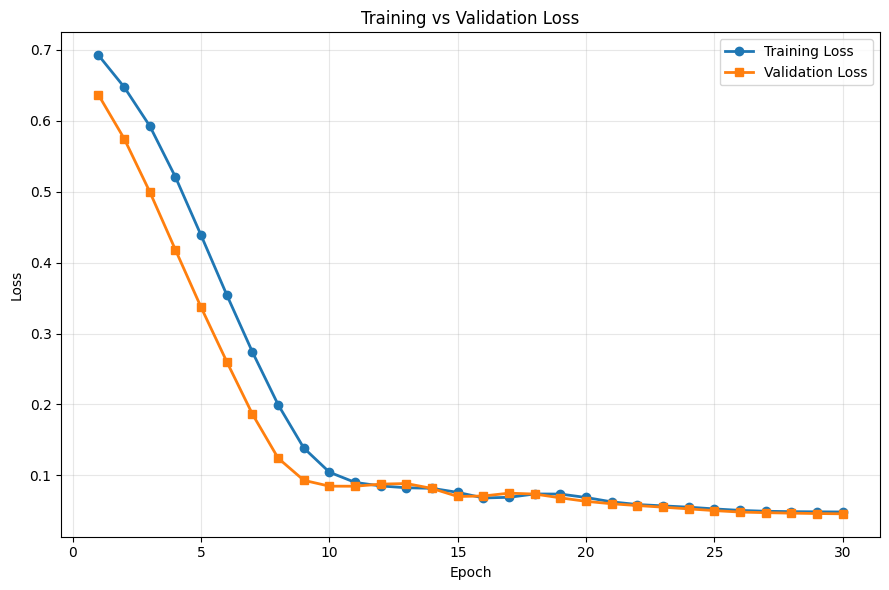

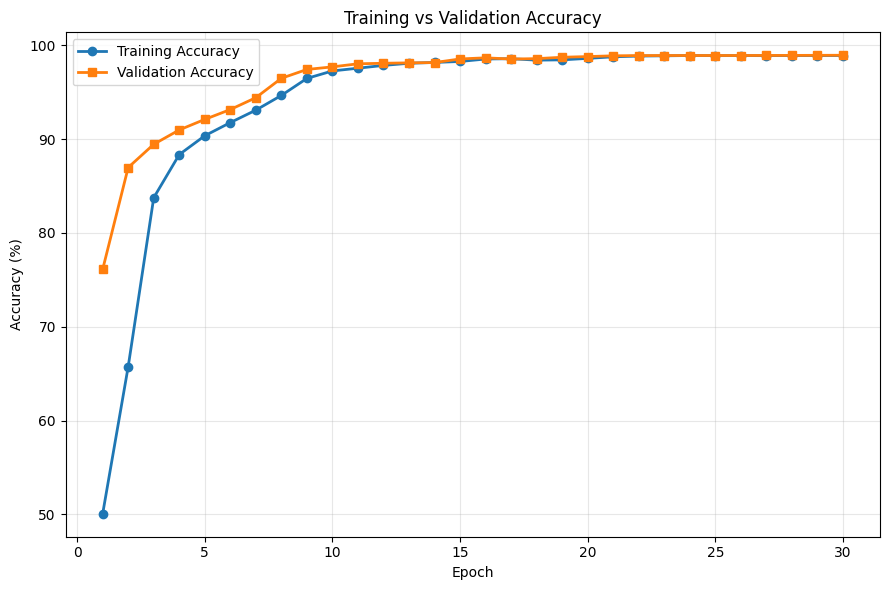

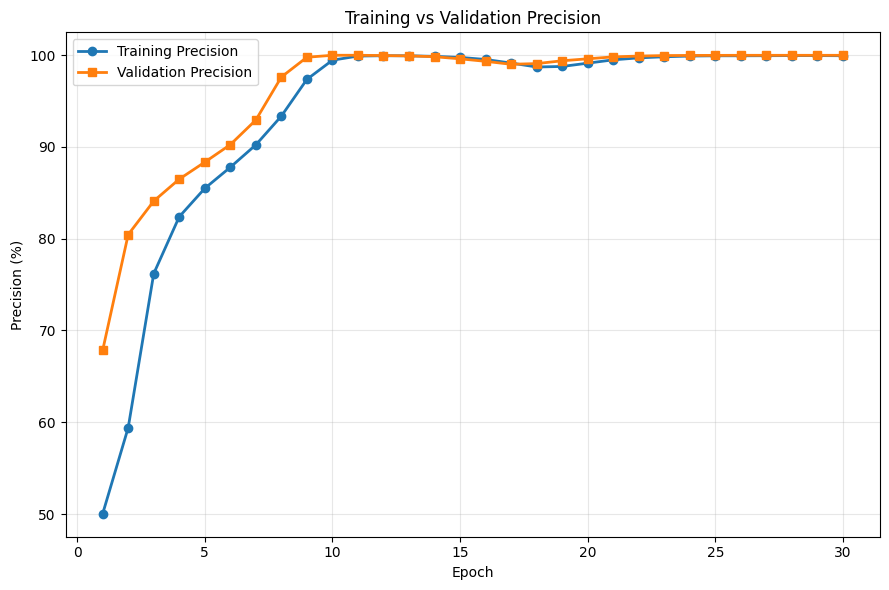

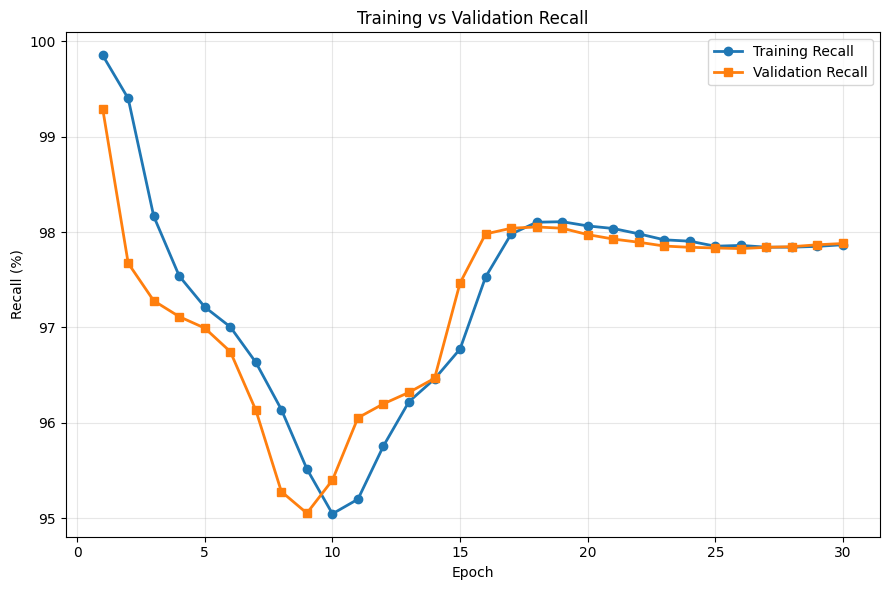

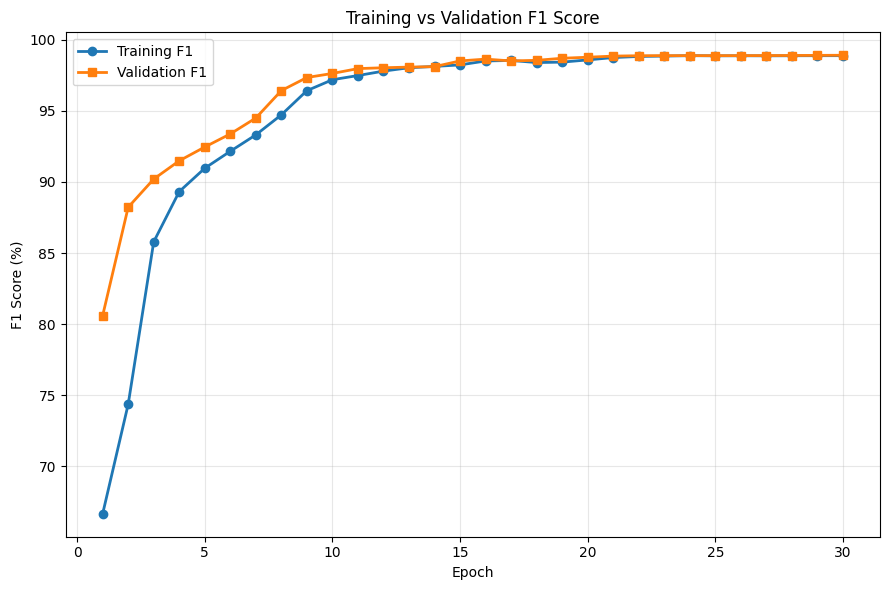

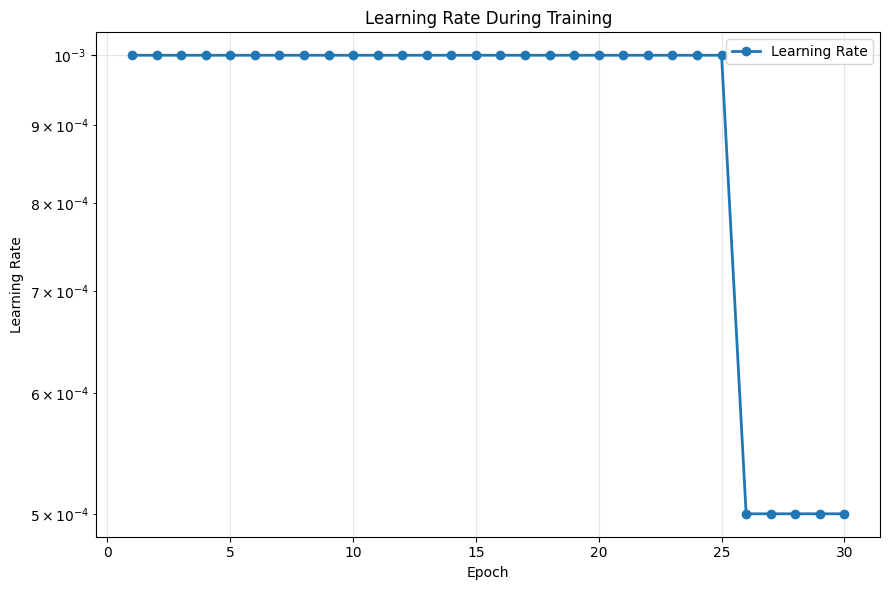

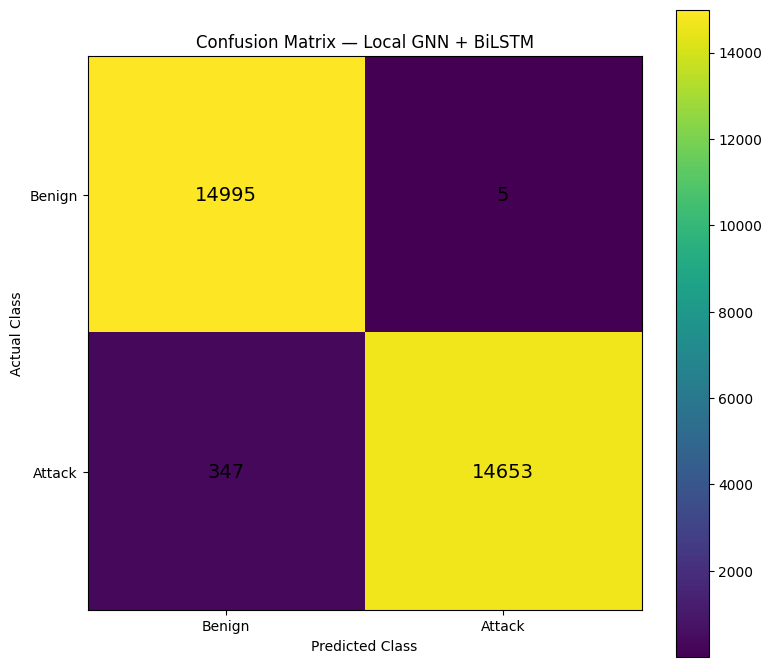

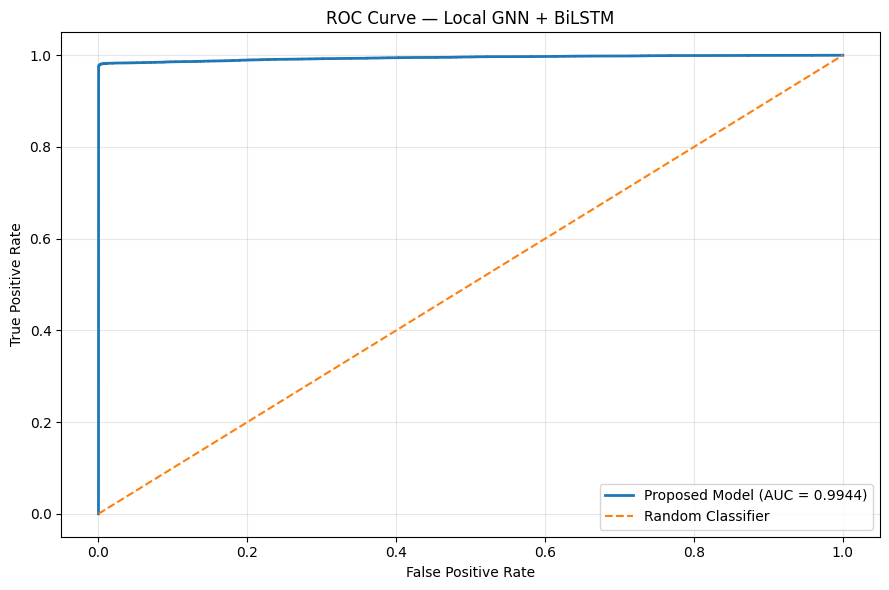

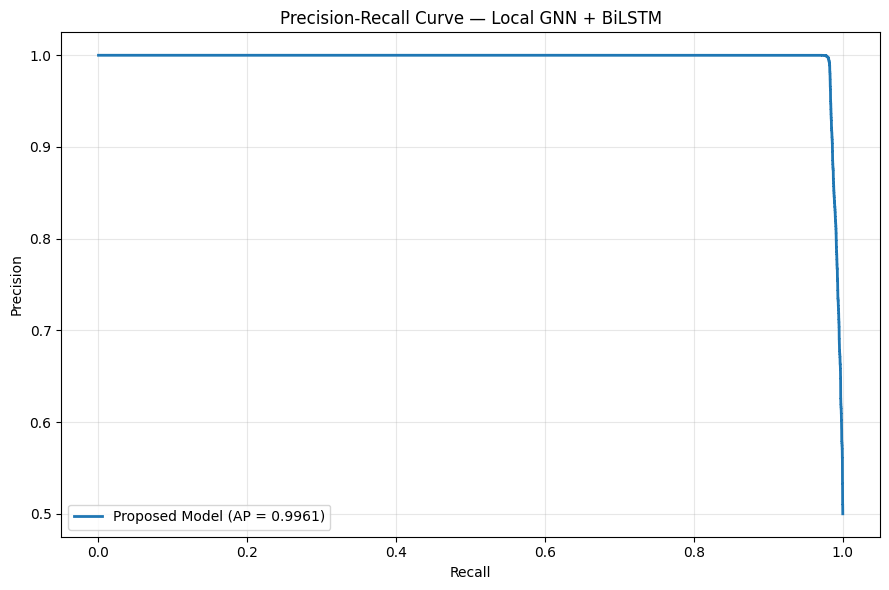

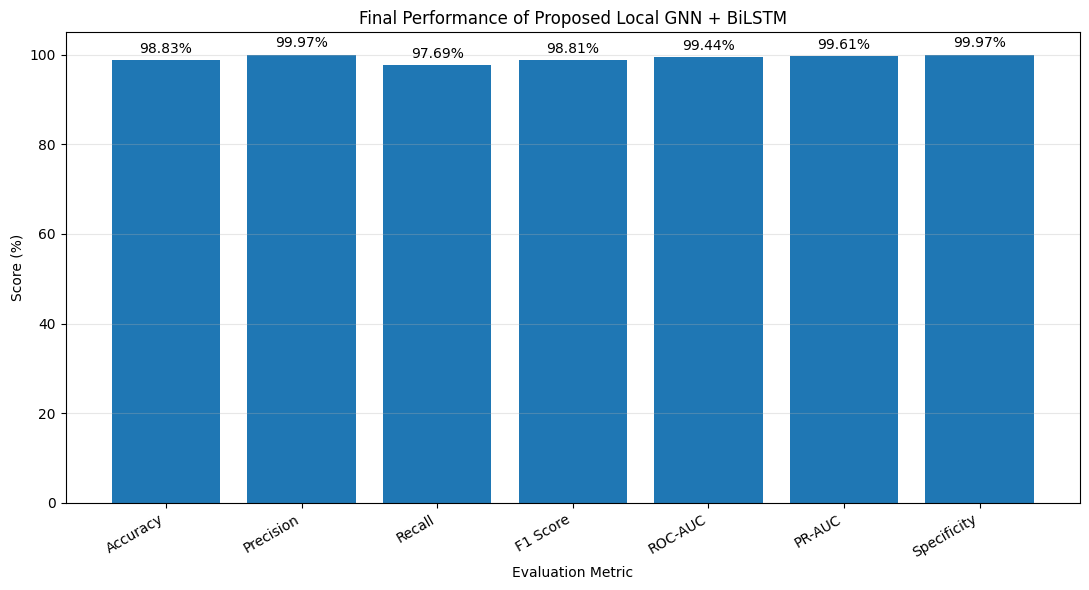

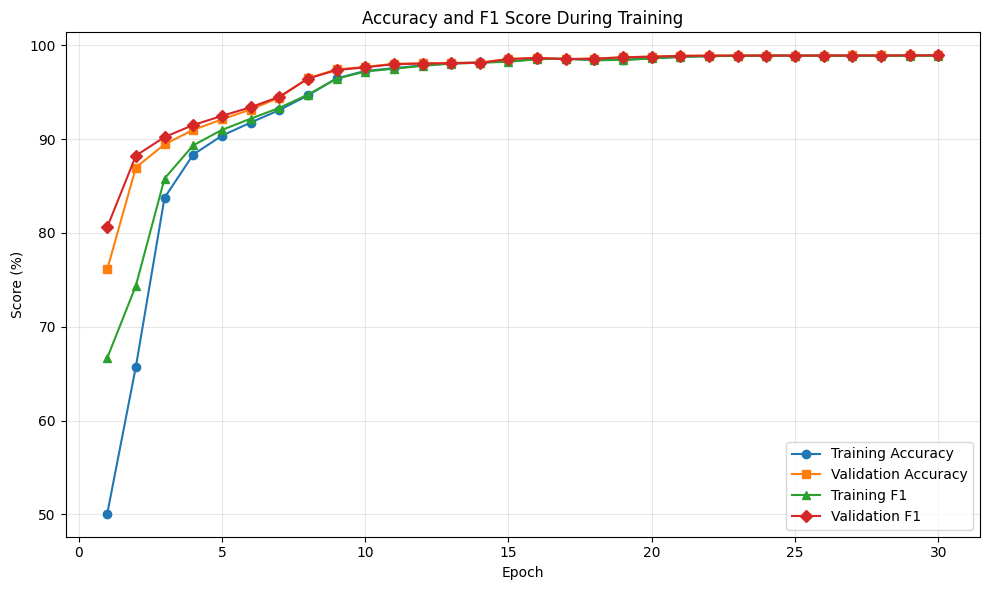

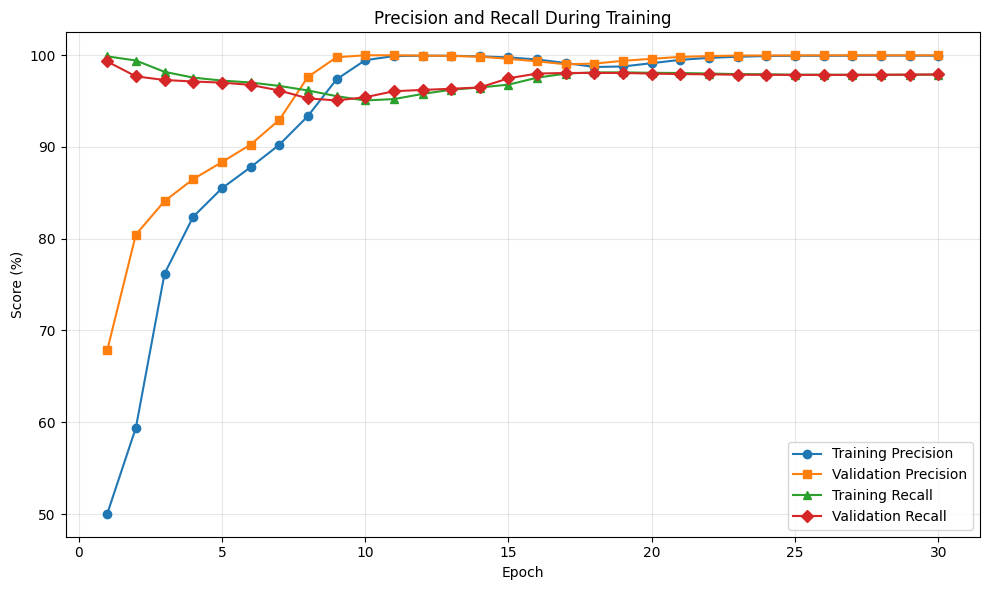


FINAL TEST RESULTS


,Metric,Value,Percentage
0,Accuracy,0.988267,98.83
1,Precision,0.999659,99.97
2,Recall,0.976867,97.69
3,F1 Score,0.988131,98.81
4,ROC-AUC,0.994442,99.44
5,PR-AUC,0.996124,99.61
6,Specificity,0.999667,99.97
7,False Acceptance Rate,0.000333,0.03
8,False Rejection Rate,0.023133,2.31
9,Balanced Accuracy,0.988267,98.83



CONFUSION MATRIX


,Predicted Benign,Predicted Attack
Actual Benign,14995,5
Actual Attack,347,14653



ALL OUTPUT FILES
Results directory: /content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results

Graph directory: /content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results/Graphs

Saved files:
✓ Confusion_Matrix.csv
✓ Final_Test_Results.csv
✓ Graphs
✓ Training_History.csv

Saved graphs:
✓ 01_Training_vs_Validation_Loss.png
✓ 02_Training_vs_Validation_Accuracy.png
✓ 03_Training_vs_Validation_Precision.png
✓ 04_Training_vs_Validation_Recall.png
✓ 05_Training_vs_Validation_F1.png
✓ 06_Learning_Rate.png
✓ 07_Confusion_Matrix.png
✓ 08_ROC_Curve.png
✓ 09_Precision_Recall_Curve.png
✓ 10_Final_Performance_Comparison.png
✓ 11_Accuracy_and_F1.png
✓ 11_Accuracy_and_F1_Training.png
✓ 12_Precision_and_Recall.png
✓ 12_Precision_and_Recall_Training.png

STEP 36 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# STEP 36 — SAVE RESULTS + PLOT ALL EXPERIMENTAL GRAPHS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# ============================================================
# RESULT DIRECTORY
# ============================================================

RESULT_DIR = (
    "/content/drive/MyDrive/"
    "FedGRAI_LocalGNN_BiLSTM_Results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("=" * 100)
print("SAVING RESULTS AND GENERATING GRAPHS")
print("=" * 100)


# ============================================================
# 1. TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    TRAIN_HISTORY
)

history_df.to_csv(
    f"{RESULT_DIR}/Training_History.csv",
    index=False
)

print("✓ Training history saved")


# ============================================================
# 2. FINAL RESULTS
# ============================================================

FINAL_RESULTS.to_csv(
    f"{RESULT_DIR}/Final_Test_Results.csv",
    index=False
)

print("✓ Final test results saved")


# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Benign",
        "Actual Attack"
    ],
    columns=[
        "Predicted Benign",
        "Predicted Attack"
    ]
)

cm_df.to_csv(
    f"{RESULT_DIR}/Confusion_Matrix.csv"
)

print("✓ Confusion matrix saved")


# ============================================================
# GRAPH DIRECTORY
# ============================================================

GRAPH_DIR = (
    f"{RESULT_DIR}/Graphs"
)

os.makedirs(
    GRAPH_DIR,
    exist_ok=True
)


# ============================================================
# MAKE SURE HISTORY EXISTS
# ============================================================

if len(history_df) == 0:

    raise ValueError(
        "TRAIN_HISTORY is empty. "
        "Run the training cell first."
    )


# ============================================================
# HELPER FUNCTION
# ============================================================

def save_show_graph(
    filename,
    title
):

    plt.title(title)

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"{GRAPH_DIR}/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================
# GRAPH 1 — TRAINING VS VALIDATION LOSS
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

save_show_graph(
    "01_Training_vs_Validation_Loss.png",
    "Training vs Validation Loss"
)


# ============================================================
# GRAPH 2 — TRAINING VS VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Accuracy"] * 100,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Accuracy"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy (%)"
)

save_show_graph(
    "02_Training_vs_Validation_Accuracy.png",
    "Training vs Validation Accuracy"
)


# ============================================================
# GRAPH 3 — TRAINING VS VALIDATION PRECISION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Precision"] * 100,
    marker="o",
    linewidth=2,
    label="Training Precision"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Precision"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Precision"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Precision (%)"
)

save_show_graph(
    "03_Training_vs_Validation_Precision.png",
    "Training vs Validation Precision"
)


# ============================================================
# GRAPH 4 — TRAINING VS VALIDATION RECALL
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Recall"] * 100,
    marker="o",
    linewidth=2,
    label="Training Recall"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Recall"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Recall"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Recall (%)"
)

save_show_graph(
    "04_Training_vs_Validation_Recall.png",
    "Training vs Validation Recall"
)


# ============================================================
# GRAPH 5 — TRAINING VS VALIDATION F1
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train F1"] * 100,
    marker="o",
    linewidth=2,
    label="Training F1"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation F1"] * 100,
    marker="s",
    linewidth=2,
    label="Validation F1"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "F1 Score (%)"
)

save_show_graph(
    "05_Training_vs_Validation_F1.png",
    "Training vs Validation F1 Score"
)


# ============================================================
# GRAPH 6 — LEARNING RATE
# ============================================================

if "Learning Rate" in history_df.columns:

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        history_df["Epoch"],
        history_df["Learning Rate"],
        marker="o",
        linewidth=2,
        label="Learning Rate"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Learning Rate"
    )

    plt.yscale(
        "log"
    )

    save_show_graph(
        "06_Learning_Rate.png",
        "Learning Rate During Training"
    )


# ============================================================
# GRAPH 7 — CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix — Local GNN + BiLSTM"
)

plt.colorbar()

classes = [
    "Benign",
    "Attack"
]

plt.xticks(
    np.arange(2),
    classes
)

plt.yticks(
    np.arange(2),
    classes
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)


# ------------------------------------------------------------
# Add numbers inside matrix
# ------------------------------------------------------------

threshold = cm.max() / 2

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            format(
                cm[i, j],
                "d"
            ),
            ha="center",
            va="center",
            fontsize=14
        )

plt.tight_layout()

plt.savefig(
    f"{GRAPH_DIR}/07_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# GRAPH 8 — ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    y_prob
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Proposed Model (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

save_show_graph(
    "08_ROC_Curve.png",
    "ROC Curve — Local GNN + BiLSTM"
)


# ============================================================
# GRAPH 9 — PRECISION-RECALL CURVE
# ============================================================

pr_precision, pr_recall, pr_thresholds = (
    precision_recall_curve(
        y_true,
        y_prob
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"Proposed Model (AP = {pr_auc:.4f})"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

save_show_graph(
    "09_Precision_Recall_Curve.png",
    "Precision-Recall Curve — Local GNN + BiLSTM"
)


# ============================================================
# GRAPH 10 — FINAL PERFORMANCE COMPARISON
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC",
    "Specificity"
]

metric_values = [
    accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100,
    roc_auc * 100,
    pr_auc * 100,
    specificity * 100
]

plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    metric_names,
    metric_values
)

plt.ylabel(
    "Score (%)"
)

plt.xlabel(
    "Evaluation Metric"
)

plt.ylim(
    0,
    105
)

plt.title(
    "Final Performance of Proposed Local GNN + BiLSTM"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)


# ------------------------------------------------------------
# Add values on bars
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    metric_values
):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,

        value + 1,

        f"{value:.2f}%",

        ha="center",

        va="bottom",

        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    f"{GRAPH_DIR}/10_Final_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# GRAPH 11 — TRAINING METRICS TOGETHER
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Accuracy"] * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Accuracy"] * 100,
    marker="s",
    label="Validation Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["Train F1"] * 100,
    marker="^",
    label="Training F1"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation F1"] * 100,
    marker="D",
    label="Validation F1"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Score (%)"
)

save_show_graph(
    "11_Accuracy_and_F1_Training.png",
    "Accuracy and F1 Score During Training"
)


# ============================================================
# GRAPH 12 — PRECISION AND RECALL TOGETHER
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Precision"] * 100,
    marker="o",
    label="Training Precision"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Precision"] * 100,
    marker="s",
    label="Validation Precision"
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Recall"] * 100,
    marker="^",
    label="Training Recall"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Recall"] * 100,
    marker="D",
    label="Validation Recall"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Score (%)"
)

save_show_graph(
    "12_Precision_and_Recall_Training.png",
    "Precision and Recall During Training"
)


# ============================================================
# DISPLAY FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL TEST RESULTS")
print("=" * 100)

display(
    FINAL_RESULTS.style.format({
        "Value": "{:.6f}",
        "Percentage": "{:.2f}"
    })
)


# ============================================================
# DISPLAY CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

display(
    cm_df
)


# ============================================================
# DISPLAY SAVED FILES
# ============================================================

print("\n" + "=" * 100)
print("ALL OUTPUT FILES")
print("=" * 100)

print(
    "Results directory:",
    RESULT_DIR
)

print(
    "\nGraph directory:",
    GRAPH_DIR
)

print("\nSaved files:")

for filename in sorted(
    os.listdir(RESULT_DIR)
):

    print(
        "✓",
        filename
    )

print("\nSaved graphs:")

for filename in sorted(
    os.listdir(GRAPH_DIR)
):

    print(
        "✓",
        filename
    )

print("\n" + "=" * 100)
print("STEP 36 COMPLETED SUCCESSFULLY")
print("=" * 100)

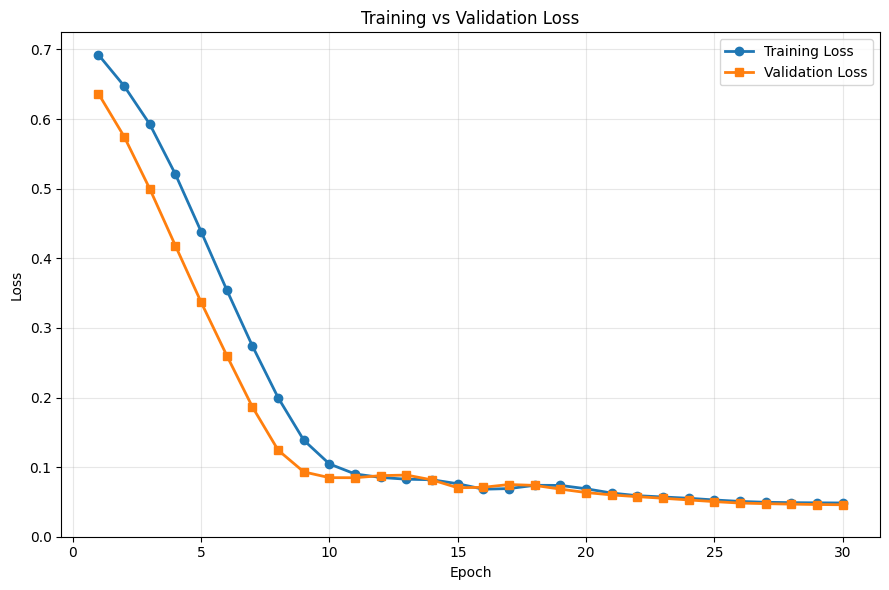

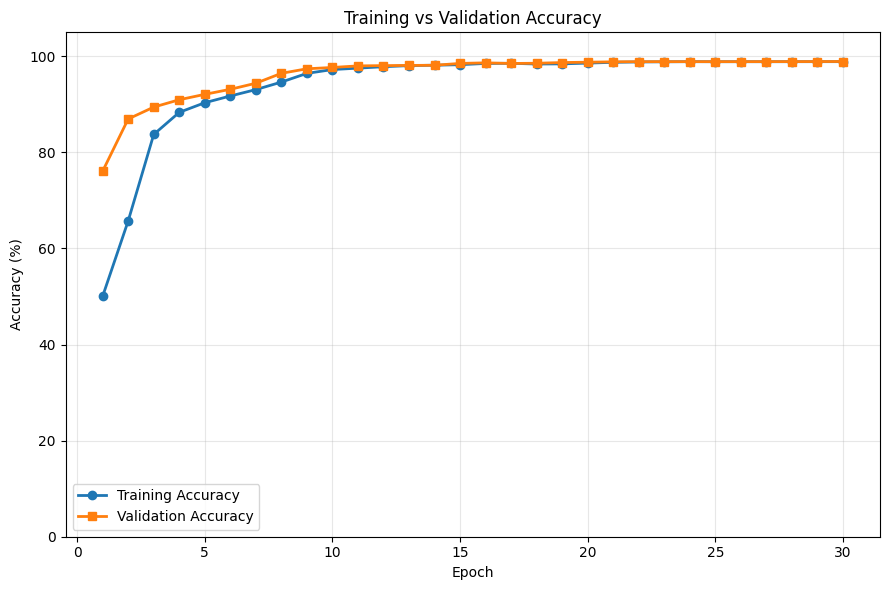

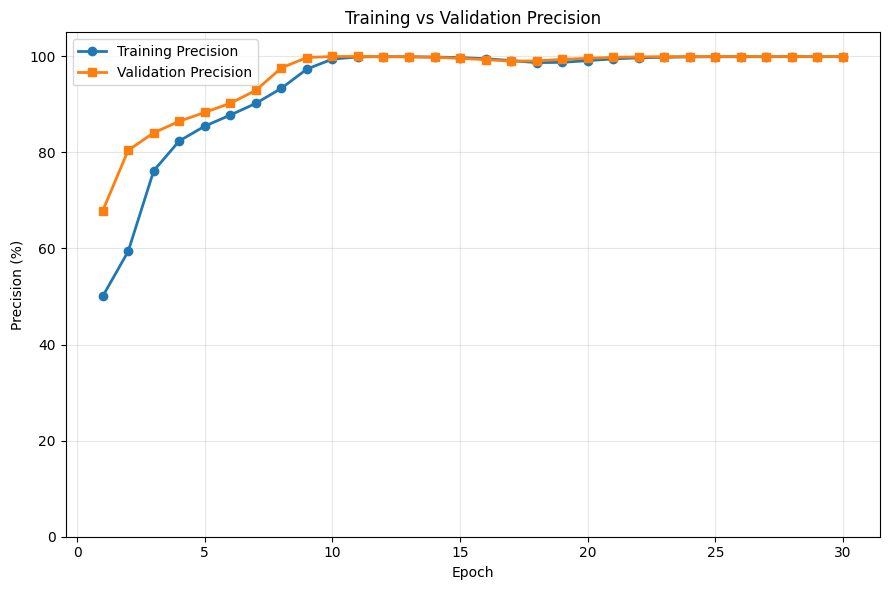

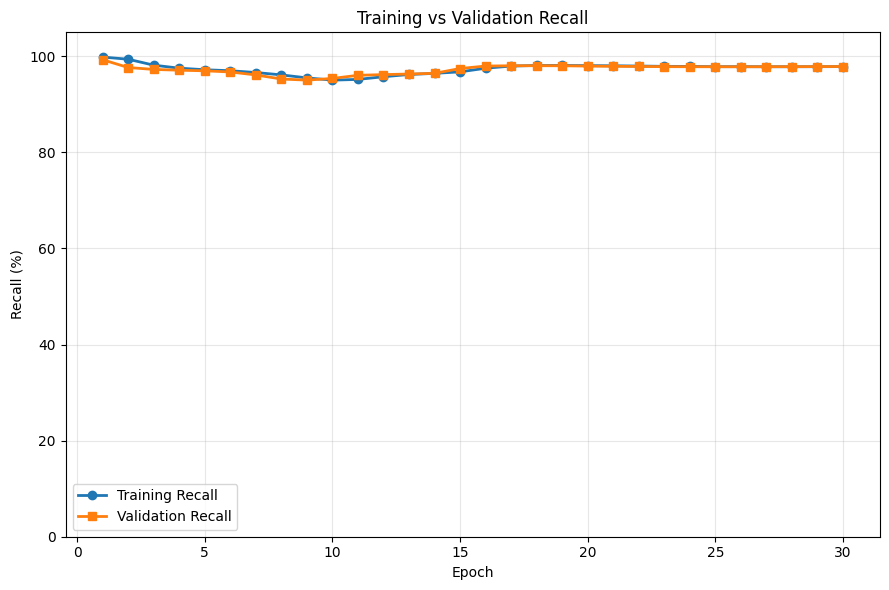

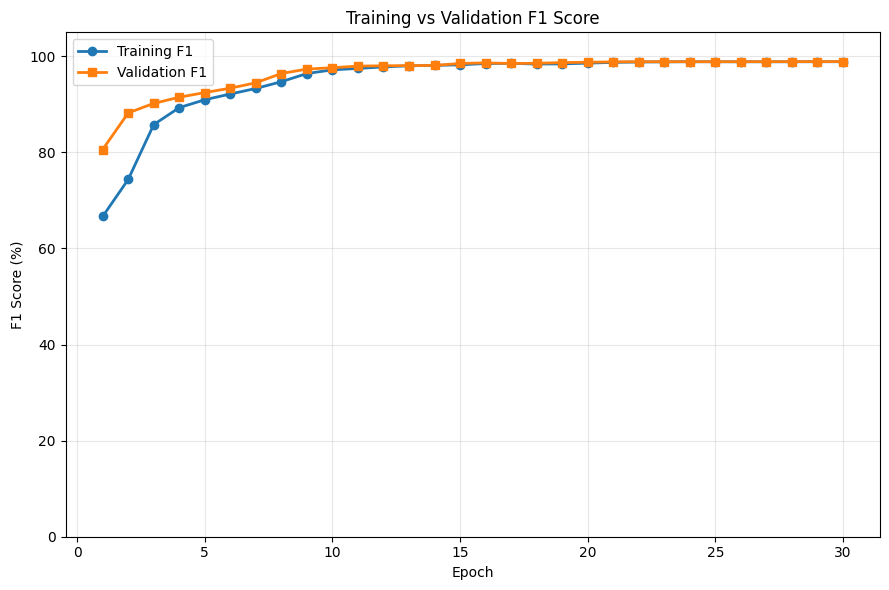

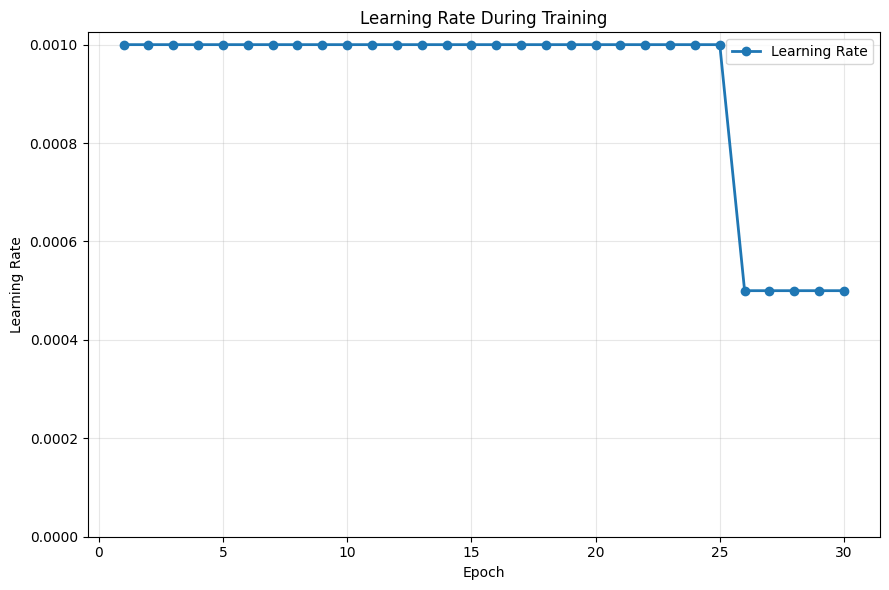

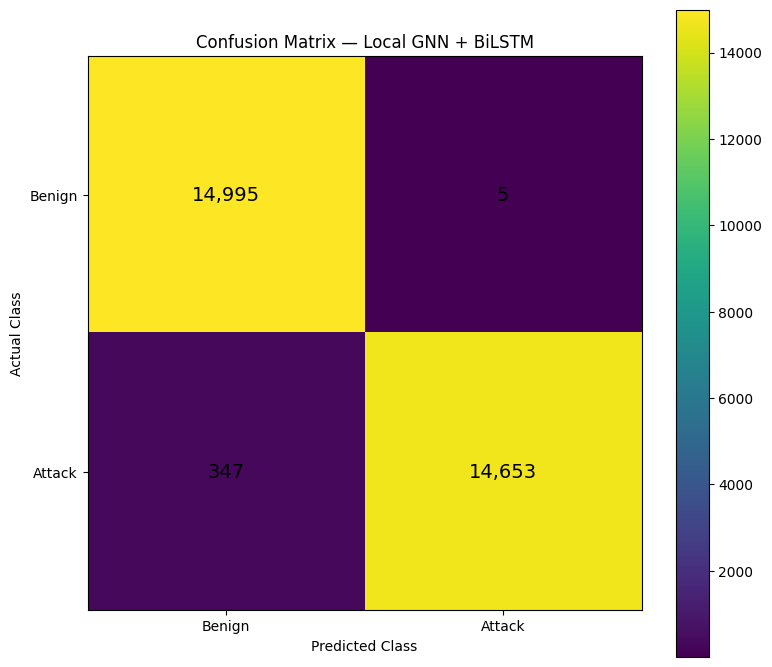

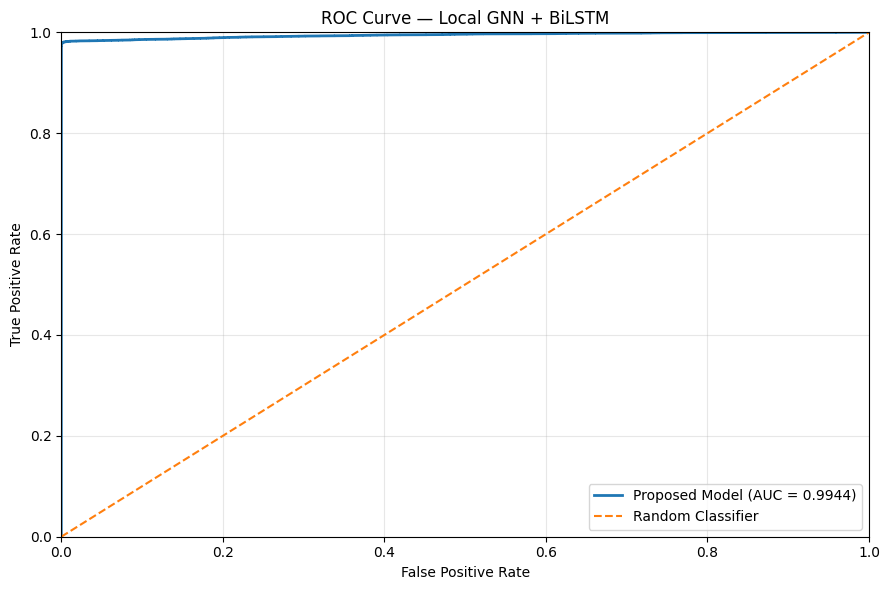

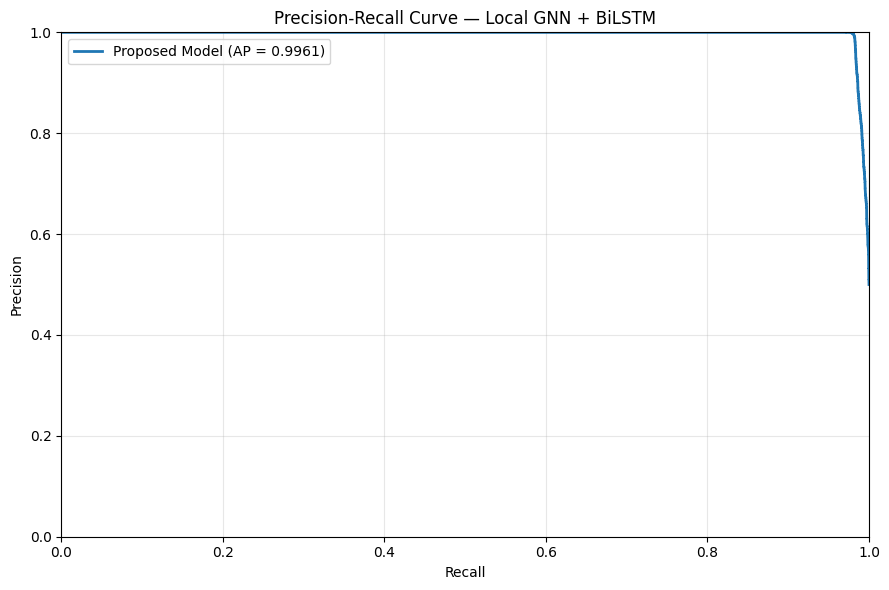

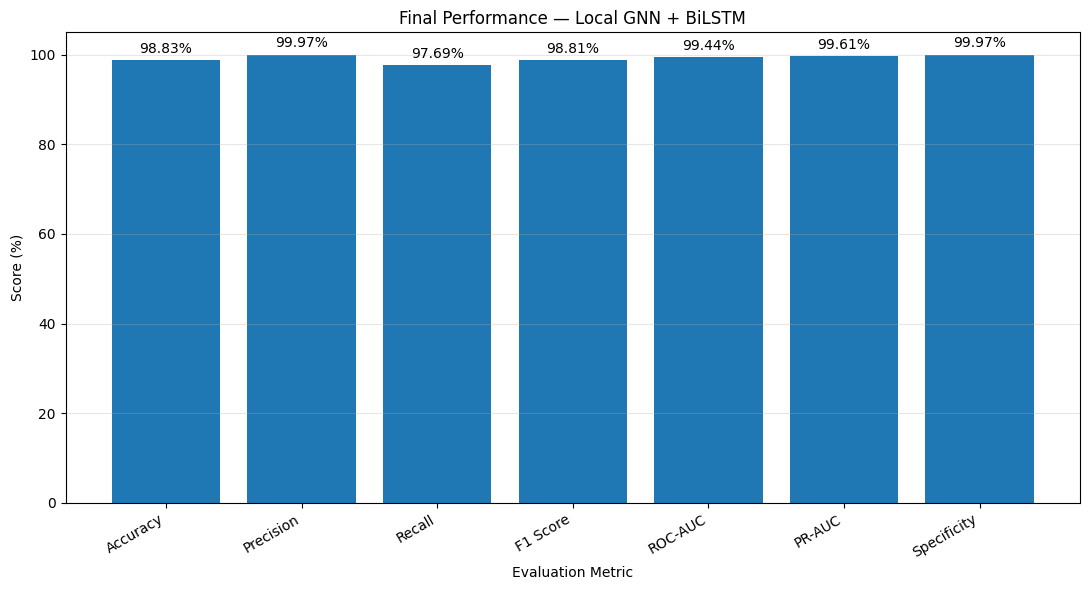

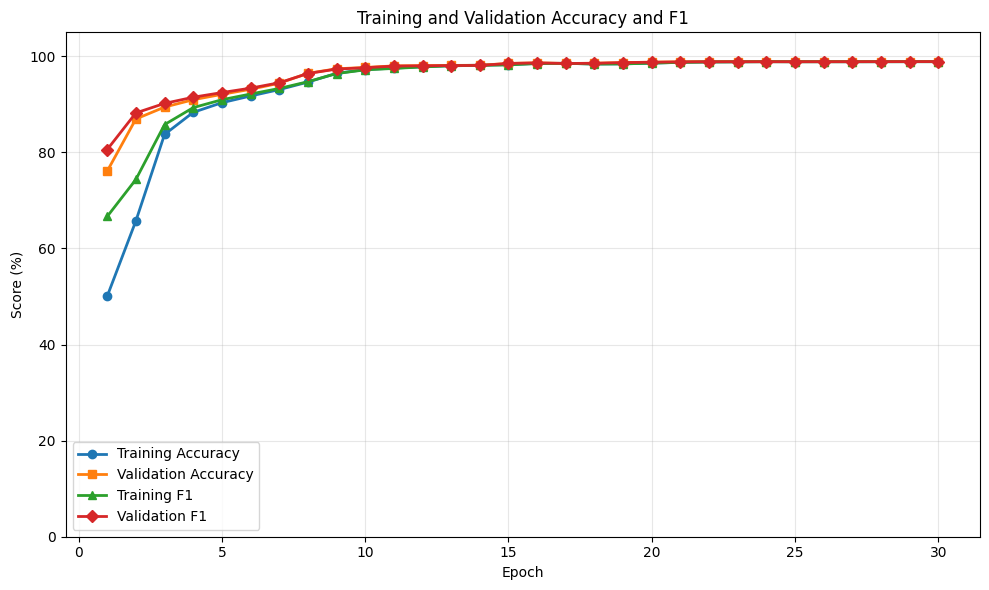

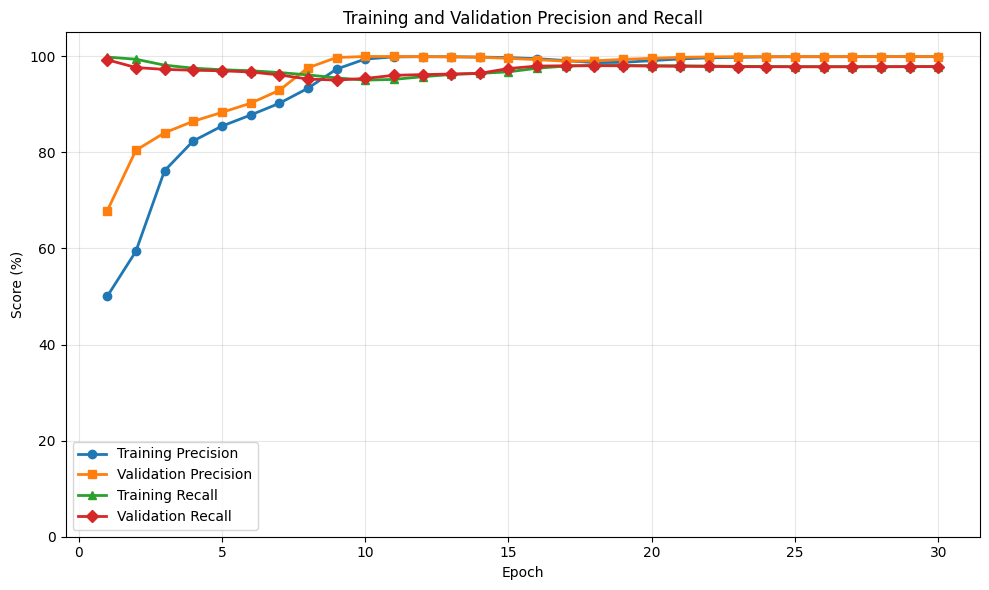


FINAL TEST RESULTS


,Metric,Value,Percentage
0,Accuracy,0.988267,98.83
1,Precision,0.999659,99.97
2,Recall,0.976867,97.69
3,F1 Score,0.988131,98.81
4,ROC-AUC,0.994442,99.44
5,PR-AUC,0.996124,99.61
6,Specificity,0.999667,99.97
7,False Acceptance Rate,0.000333,0.03
8,False Rejection Rate,0.023133,2.31
9,Balanced Accuracy,0.988267,98.83



CONFUSION MATRIX


,Predicted Benign,Predicted Attack
Actual Benign,14995,5
Actual Attack,347,14653



SAVED GRAPHS
✓ 01_Training_vs_Validation_Loss.png
✓ 02_Training_vs_Validation_Accuracy.png
✓ 03_Training_vs_Validation_Precision.png
✓ 04_Training_vs_Validation_Recall.png
✓ 05_Training_vs_Validation_F1.png
✓ 06_Learning_Rate.png
✓ 07_Confusion_Matrix.png
✓ 08_ROC_Curve.png
✓ 09_Precision_Recall_Curve.png
✓ 10_Final_Performance_Comparison.png
✓ 11_Accuracy_and_F1.png
✓ 11_Accuracy_and_F1_Training.png
✓ 12_Precision_and_Recall.png
✓ 12_Precision_and_Recall_Training.png

STEP 36 COMPLETED

All graphs start from 0 on their Y-axis.

Graphs saved at:
/content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results/Graphs


In [ ]:
# ============================================================
# STEP 36 — ALL GRAPHS START FROM ZERO
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# ============================================================
# RESULT DIRECTORY
# ============================================================

RESULT_DIR = (
    "/content/drive/MyDrive/"
    "FedGRAI_LocalGNN_BiLSTM_Results"
)

GRAPH_DIR = f"{RESULT_DIR}/Graphs"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

os.makedirs(
    GRAPH_DIR,
    exist_ok=True
)


# ============================================================
# SAVE DATA
# ============================================================

history_df = pd.DataFrame(
    TRAIN_HISTORY
)

history_df.to_csv(
    f"{RESULT_DIR}/Training_History.csv",
    index=False
)

FINAL_RESULTS.to_csv(
    f"{RESULT_DIR}/Final_Test_Results.csv",
    index=False
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Benign",
        "Actual Attack"
    ],
    columns=[
        "Predicted Benign",
        "Predicted Attack"
    ]
)

cm_df.to_csv(
    f"{RESULT_DIR}/Confusion_Matrix.csv"
)


# ============================================================
# HELPER FUNCTION
# ============================================================

def finish_graph(
    filename,
    title,
    ylabel,
    ylim=None
):

    plt.title(title)

    plt.xlabel("Epoch")

    plt.ylabel(ylabel)

    plt.grid(
        True,
        alpha=0.3
    )

    if ylim is not None:
        plt.ylim(ylim)

    else:
        plt.ylim(bottom=0)

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"{GRAPH_DIR}/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================
# 1 — TRAINING VS VALIDATION LOSS
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

finish_graph(
    "01_Training_vs_Validation_Loss.png",
    "Training vs Validation Loss",
    "Loss"
)


# ============================================================
# 2 — TRAINING VS VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Accuracy"] * 100,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Accuracy"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

finish_graph(
    "02_Training_vs_Validation_Accuracy.png",
    "Training vs Validation Accuracy",
    "Accuracy (%)",
    ylim=(0, 105)
)


# ============================================================
# 3 — TRAINING VS VALIDATION PRECISION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Precision"] * 100,
    marker="o",
    linewidth=2,
    label="Training Precision"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Precision"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Precision"
)

finish_graph(
    "03_Training_vs_Validation_Precision.png",
    "Training vs Validation Precision",
    "Precision (%)",
    ylim=(0, 105)
)


# ============================================================
# 4 — TRAINING VS VALIDATION RECALL
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Recall"] * 100,
    marker="o",
    linewidth=2,
    label="Training Recall"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Recall"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Recall"
)

finish_graph(
    "04_Training_vs_Validation_Recall.png",
    "Training vs Validation Recall",
    "Recall (%)",
    ylim=(0, 105)
)


# ============================================================
# 5 — TRAINING VS VALIDATION F1
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train F1"] * 100,
    marker="o",
    linewidth=2,
    label="Training F1"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation F1"] * 100,
    marker="s",
    linewidth=2,
    label="Validation F1"
)

finish_graph(
    "05_Training_vs_Validation_F1.png",
    "Training vs Validation F1 Score",
    "F1 Score (%)",
    ylim=(0, 105)
)


# ============================================================
# 6 — LEARNING RATE
# ============================================================

if "Learning Rate" in history_df.columns:

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        history_df["Epoch"],
        history_df["Learning Rate"],
        marker="o",
        linewidth=2,
        label="Learning Rate"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")

    plt.ylim(
        bottom=0
    )

    plt.title(
        "Learning Rate During Training"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"{GRAPH_DIR}/06_Learning_Rate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================
# 7 — CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix — Local GNN + BiLSTM"
)

plt.colorbar()

classes = [
    "Benign",
    "Attack"
]

plt.xticks(
    np.arange(2),
    classes
)

plt.yticks(
    np.arange(2),
    classes
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=14
        )

plt.tight_layout()

plt.savefig(
    f"{GRAPH_DIR}/07_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 8 — ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    y_prob
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Proposed Model (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1
)

plt.title(
    "ROC Curve — Local GNN + BiLSTM"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{GRAPH_DIR}/08_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 9 — PRECISION-RECALL CURVE
# ============================================================

pr_precision, pr_recall, pr_thresholds = (
    precision_recall_curve(
        y_true,
        y_prob
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"Proposed Model (AP = {pr_auc:.4f})"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1
)

plt.title(
    "Precision-Recall Curve — Local GNN + BiLSTM"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{GRAPH_DIR}/09_Precision_Recall_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 10 — FINAL PERFORMANCE
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC",
    "Specificity"
]

metric_values = [
    accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100,
    roc_auc * 100,
    pr_auc * 100,
    specificity * 100
]

plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    metric_names,
    metric_values
)

plt.xlabel(
    "Evaluation Metric"
)

plt.ylabel(
    "Score (%)"
)

plt.ylim(
    0,
    105
)

plt.title(
    "Final Performance — Local GNN + BiLSTM"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    metric_values
):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,

        value + 1,

        f"{value:.2f}%",

        ha="center",

        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    f"{GRAPH_DIR}/10_Final_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 11 — ACCURACY + F1
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Accuracy"] * 100,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Accuracy"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["Train F1"] * 100,
    marker="^",
    linewidth=2,
    label="Training F1"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation F1"] * 100,
    marker="D",
    linewidth=2,
    label="Validation F1"
)

finish_graph(
    "11_Accuracy_and_F1.png",
    "Training and Validation Accuracy and F1",
    "Score (%)",
    ylim=(0, 105)
)


# ============================================================
# 12 — PRECISION + RECALL
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Precision"] * 100,
    marker="o",
    linewidth=2,
    label="Training Precision"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Precision"] * 100,
    marker="s",
    linewidth=2,
    label="Validation Precision"
)

plt.plot(
    history_df["Epoch"],
    history_df["Train Recall"] * 100,
    marker="^",
    linewidth=2,
    label="Training Recall"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Recall"] * 100,
    marker="D",
    linewidth=2,
    label="Validation Recall"
)

finish_graph(
    "12_Precision_and_Recall.png",
    "Training and Validation Precision and Recall",
    "Score (%)",
    ylim=(0, 105)
)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL TEST RESULTS")
print("=" * 100)

display(
    FINAL_RESULTS.style.format({
        "Value": "{:.6f}",
        "Percentage": "{:.2f}"
    })
)


# ============================================================
# CONFUSION MATRIX TABLE
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

display(
    cm_df
)


# ============================================================
# FILE LIST
# ============================================================

print("\n" + "=" * 100)
print("SAVED GRAPHS")
print("=" * 100)

for filename in sorted(
    os.listdir(GRAPH_DIR)
):

    print(
        "✓",
        filename
    )


print("\n" + "=" * 100)
print("STEP 36 COMPLETED")
print("=" * 100)

print(
    "\nAll graphs start from 0 on their Y-axis."
)

print(
    "\nGraphs saved at:"
)

print(
    GRAPH_DIR
)

SEARCHING FOR PREPROCESSING DATA
✓ Raw dataframe found: CIC_DATA
✓ Feature matrix found: X

Using raw dataframe: CIC_DATA
Numeric features: 47

Original feature matrix: (200000, 46)

⚠ No explicit imputed matrix found.
Creating a median-imputed visualization matrix.

Calculating Pearson correlation...

Highly correlated features removed: 9
Features before: 35
Features after: 26


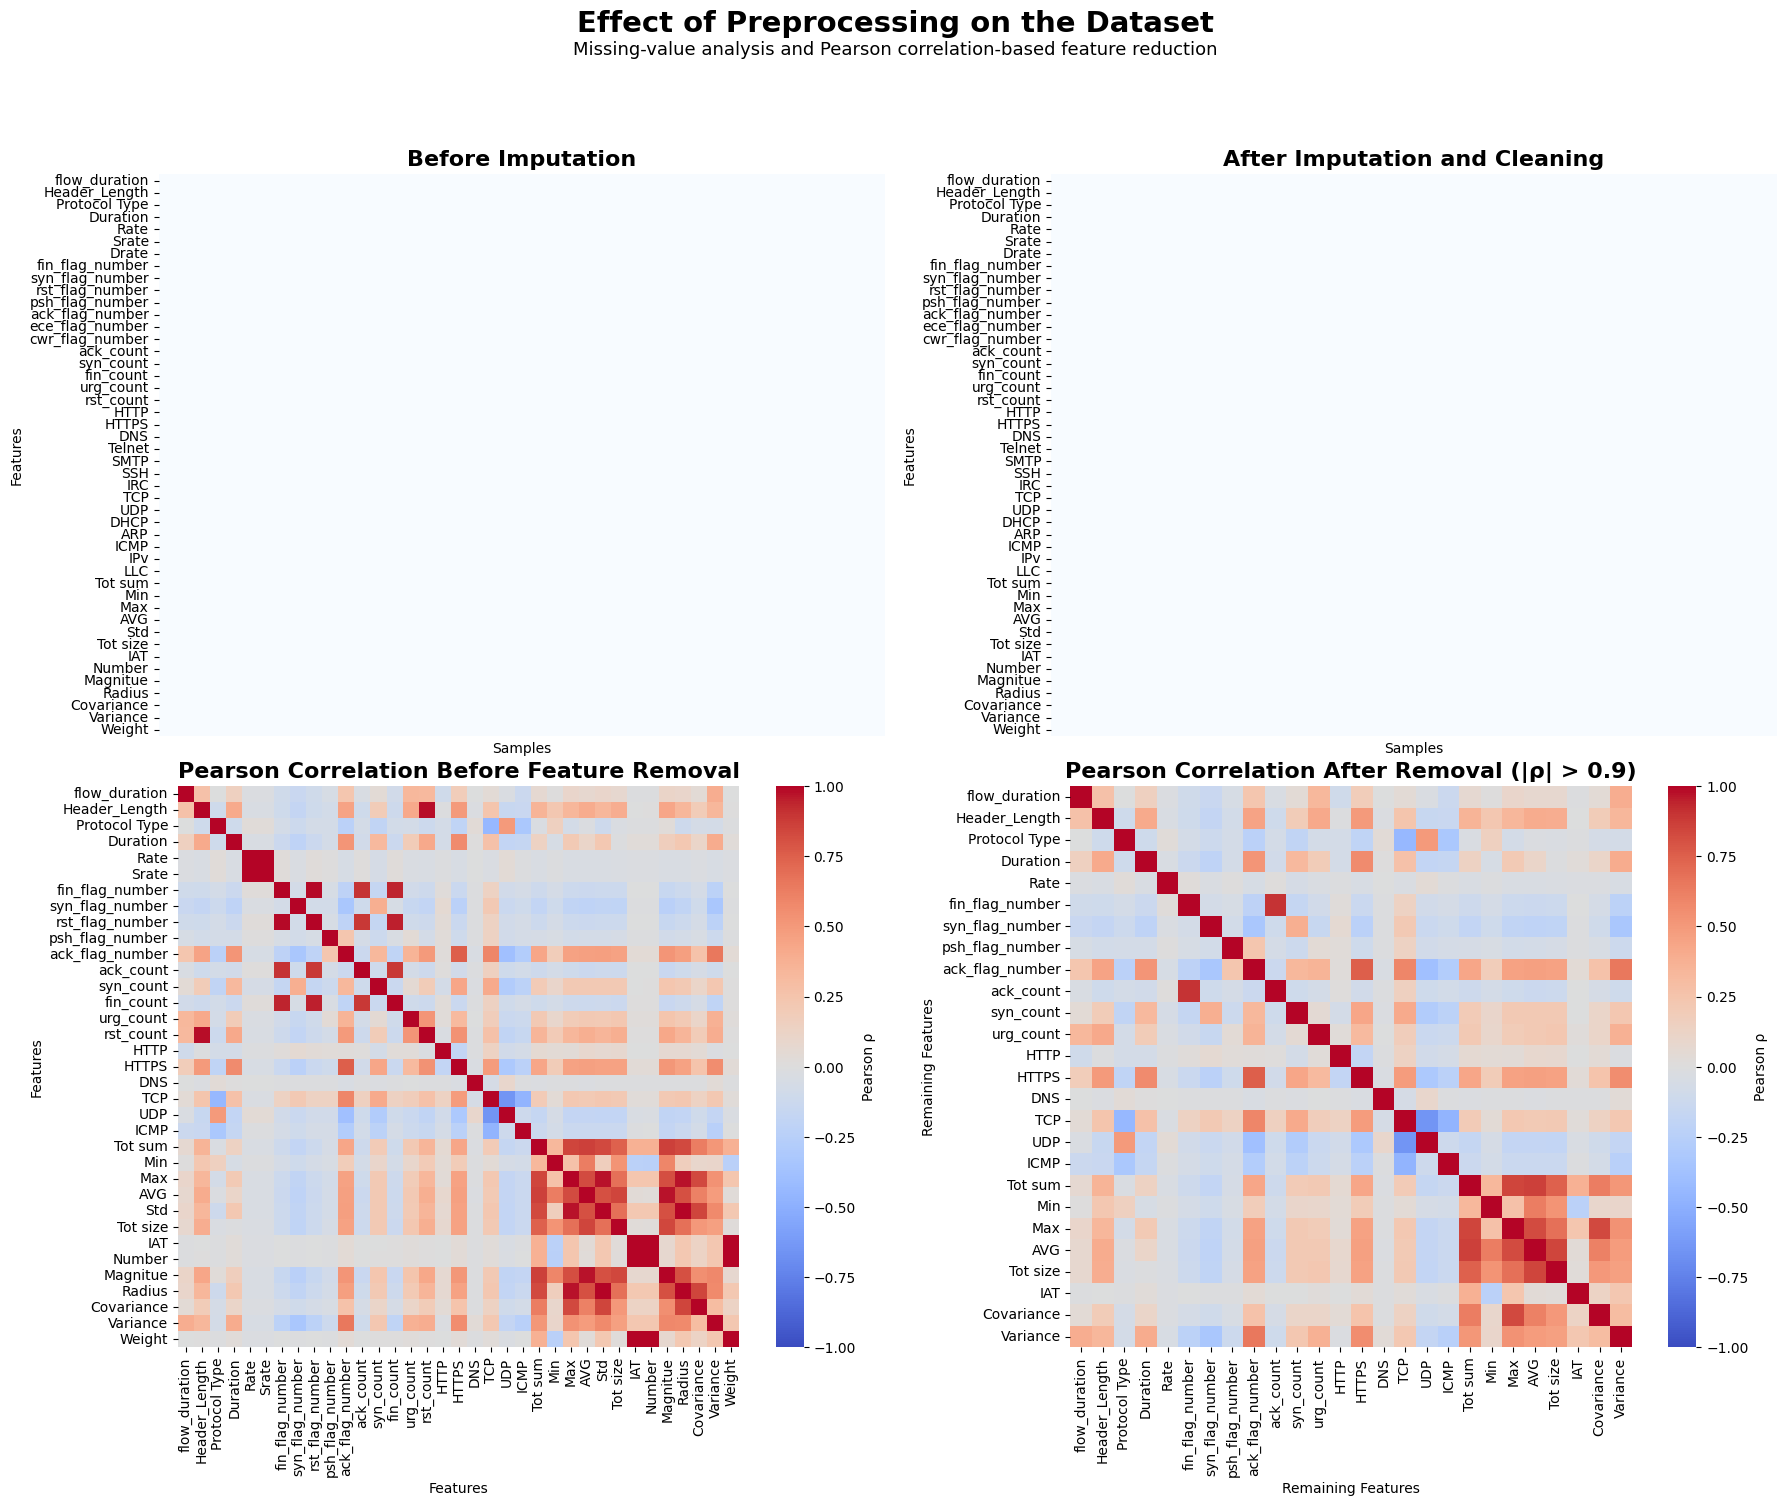


PREPROCESSING FIGURE GENERATED
Original features: 46
Features before correlation filtering: 35
Highly correlated features removed: 9
Remaining features: 26
Missing cells before: 0
Missing cells after: 0

Saved to:
/content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results/Figure_Preprocessing_Effect.png


In [ ]:
# ============================================================
# PREPROCESSING EFFECT FIGURE
# Missing Values + Pearson Correlation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.feature_selection import VarianceThreshold


# ============================================================
# SETTINGS
# ============================================================

FIG_DIR = "/content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results"

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

SEED = 42

# Number of rows used for visualization
# Using all 200,000 rows can make heatmaps slow.
HEATMAP_SAMPLES = 3000

# Correlation threshold
CORR_THRESHOLD = 0.90


# ============================================================
# FIND AVAILABLE DATA
# ============================================================

print("=" * 90)
print("SEARCHING FOR PREPROCESSING DATA")
print("=" * 90)


# ------------------------------------------------------------
# Possible raw datasets
# ------------------------------------------------------------

raw_candidates = [
    "CIC_DATA",
    "CIC_SAMPLE",
    "df",
    "data",
    "DATA"
]

raw_df = None
raw_name = None

for name in raw_candidates:

    if name in globals():

        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):

            raw_df = obj.copy()
            raw_name = name

            print(
                f"✓ Raw dataframe found: {name}"
            )

            break


# ------------------------------------------------------------
# Possible original feature matrices
# ------------------------------------------------------------

feature_candidates = [
    "X",
    "X_data",
    "X_numeric",
    "X_scaled",
    "X_selected",
    "X_encoded",
    "X_train",
    "X_train_missing"
]

feature_matrix = None
feature_name = None

for name in feature_candidates:

    if name in globals():

        obj = globals()[name]

        if isinstance(
            obj,
            (
                np.ndarray,
                pd.DataFrame
            )
        ):

            feature_matrix = obj
            feature_name = name

            print(
                f"✓ Feature matrix found: {name}"
            )

            break


# ============================================================
# IF RAW DATAFRAME EXISTS
# ============================================================

if raw_df is not None:

    print(
        "\nUsing raw dataframe:",
        raw_name
    )

    # --------------------------------------------------------
    # Remove label columns
    # --------------------------------------------------------

    exclude_columns = [
        "label",
        "Label",
        "binary_label",
        "Binary_Label",
        "attack",
        "Attack"
    ]

    numeric_df = raw_df.select_dtypes(
        include=[np.number]
    ).copy()

    print(
        "Numeric features:",
        numeric_df.shape[1]
    )

    # --------------------------------------------------------
    # Remove labels if numeric
    # --------------------------------------------------------

    for col in exclude_columns:

        if col in numeric_df.columns:

            numeric_df = numeric_df.drop(
                columns=[col]
            )

    # --------------------------------------------------------
    # Original matrix
    # --------------------------------------------------------

    X_before_df = numeric_df.copy()

else:

    # ========================================================
    # FALLBACK TO FEATURE MATRIX
    # ========================================================

    if feature_matrix is None:

        raise NameError(
            """
            Could not find your original feature matrix.

            Please make sure one of these variables exists:

            CIC_DATA
            CIC_SAMPLE
            X
            X_data
            X_numeric
            X_scaled
            X_selected
            X_encoded
            """
        )

    if isinstance(
        feature_matrix,
        np.ndarray
    ):

        X_before_df = pd.DataFrame(
            feature_matrix
        )

    else:

        X_before_df = feature_matrix.copy()

    print(
        "\nUsing feature matrix:",
        feature_name
    )


# ============================================================
# CONVERT TO NUMERIC
# ============================================================

X_before_df = X_before_df.apply(
    pd.to_numeric,
    errors="coerce"
)

# Remove completely empty columns
X_before_df = X_before_df.dropna(
    axis=1,
    how="all"
)

print(
    "\nOriginal feature matrix:",
    X_before_df.shape
)


# ============================================================
# SAMPLE FOR VISUALIZATION
# ============================================================

rng = np.random.default_rng(
    SEED
)

n_rows = min(
    HEATMAP_SAMPLES,
    len(X_before_df)
)

sample_indices = rng.choice(
    len(X_before_df),
    size=n_rows,
    replace=False
)

X_plot_before = (
    X_before_df.iloc[
        sample_indices
    ]
    .copy()
)


# ============================================================
# TOP-LEFT:
# MISSING VALUES BEFORE
# ============================================================

missing_before = (
    X_plot_before.isna()
    .astype(int)
)


# ============================================================
# IDENTIFY IMPUTED / CLEAN DATA
# ============================================================

# ------------------------------------------------------------
# Try to find an already-created imputed matrix
# ------------------------------------------------------------

imputed_candidates = [

    "X_imputed",
    "X_clean",
    "X_cleaned",
    "X_imputed_scaled",
    "X_processed",
    "X_preprocessed",
    "X_encoded",
    "X_scaled"
]

X_after_df = None
after_name = None

for name in imputed_candidates:

    if name in globals():

        obj = globals()[name]

        if isinstance(
            obj,
            (
                np.ndarray,
                pd.DataFrame
            )
        ):

            # Check dimensions
            if (
                len(obj) == len(X_before_df)
            ):

                X_after_df = (
                    pd.DataFrame(obj)
                    if isinstance(
                        obj,
                        np.ndarray
                    )
                    else obj.copy()
                )

                after_name = name

                print(
                    f"✓ Existing processed matrix found: {name}"
                )

                break


# ============================================================
# FALLBACK:
# CREATE CLEAN VERSION USING MEDIAN
# ============================================================

if X_after_df is None:

    print(
        "\n⚠ No explicit imputed matrix found."
    )

    print(
        "Creating a median-imputed visualization matrix."
    )

    X_after_df = X_before_df.copy()

    X_after_df = X_after_df.fillna(
        X_after_df.median(
            numeric_only=True
        )
    )

    after_name = "Median-imputed fallback"


# ------------------------------------------------------------
# Align columns
# ------------------------------------------------------------

X_after_df = X_after_df.select_dtypes(
    include=[np.number]
)

X_after_df = X_after_df.replace(
    [np.inf, -np.inf],
    np.nan
)

X_after_df = X_after_df.fillna(
    X_after_df.median()
)


# ============================================================
# SAMPLE PROCESSED DATA
# ============================================================

X_plot_after = (
    X_after_df.iloc[
        sample_indices
    ]
    .copy()
)


# ============================================================
# TOP-RIGHT:
# MISSING VALUES AFTER
# ============================================================

missing_after = (
    X_plot_after.isna()
    .astype(int)
)


# ============================================================
# CORRELATION BEFORE
# ============================================================

print(
    "\nCalculating Pearson correlation..."
)

# Remove constant columns
variance_filter = VarianceThreshold(
    threshold=0
)

X_corr_before_array = (
    variance_filter.fit_transform(
        X_plot_after
    )
)

corr_feature_names = (
    X_plot_after.columns[
        variance_filter.get_support()
    ]
)

X_corr_before = pd.DataFrame(
    X_corr_before_array,
    columns=corr_feature_names
)

corr_before = (
    X_corr_before
    .corr(method="pearson")
)




upper_triangle = np.triu(
    np.ones(
        corr_before.shape,
        dtype=bool
    ),
    k=1
)

upper_corr = (
    corr_before
    .where(upper_triangle)
)

high_corr_columns = [

    column

    for column in upper_corr.columns

    if any(
        upper_corr[column]
        .abs()
        > CORR_THRESHOLD
    )
]


print(
    "\nHighly correlated features removed:",
    len(high_corr_columns)
)




X_corr_after = (
    X_corr_before
    .drop(
        columns=high_corr_columns,
        errors="ignore"
    )
)



corr_after = (
    X_corr_after
    .corr(method="pearson")
)


print(
    "Features before:",
    X_corr_before.shape[1]
)

print(
    "Features after:",
    X_corr_after.shape[1]
)




fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 15)
)




sns.heatmap(
    missing_before.T,
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=False,
    yticklabels=True
)

axes[0, 0].set_title(
    "Before Imputation",
    fontsize=16,
    fontweight="bold"
)

axes[0, 0].set_xlabel(
    "Samples"
)

axes[0, 0].set_ylabel(
    "Features"
)


# ============================================================
# TOP RIGHT — MISSING VALUES AFTER
# ============================================================

sns.heatmap(
    missing_after.T,
    cmap="Blues",
    cbar=False,
    ax=axes[0, 1],
    xticklabels=False,
    yticklabels=True
)

axes[0, 1].set_title(
    "After Imputation and Cleaning",
    fontsize=16,
    fontweight="bold"
)

axes[0, 1].set_xlabel(
    "Samples"
)

axes[0, 1].set_ylabel(
    "Features"
)


# ============================================================
# BOTTOM LEFT — CORRELATION BEFORE
# ============================================================

sns.heatmap(
    corr_before,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1, 0],
    cbar_kws={
        "label": "Pearson ρ"
    }
)

axes[1, 0].set_title(
    "Pearson Correlation Before Feature Removal",
    fontsize=16,
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Features"
)

axes[1, 0].set_ylabel(
    "Features"
)


# ============================================================
# BOTTOM RIGHT — CORRELATION AFTER
# ============================================================

sns.heatmap(
    corr_after,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1, 1],
    cbar_kws={
        "label": "Pearson ρ"
    }
)

axes[1, 1].set_title(
    f"Pearson Correlation After Removal "
    f"(|ρ| > {CORR_THRESHOLD})",
    fontsize=16,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Remaining Features"
)

axes[1, 1].set_ylabel(
    "Remaining Features"
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "Effect of Preprocessing on the Dataset",
    fontsize=21,
    fontweight="bold",
    y=0.995
)


# ============================================================
# SUBTITLE / DESCRIPTION
# ============================================================

fig.text(
    0.5,
    0.965,
    "Missing-value analysis and Pearson correlation-based "
    "feature reduction",
    ha="center",
    fontsize=13
)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94
    ]
)


# ============================================================
# SAVE
# ============================================================

FIG_PATH = os.path.join(
    FIG_DIR,
    "Figure_Preprocessing_Effect.png"
)

plt.savefig(
    FIG_PATH,
    dpi=400,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("PREPROCESSING FIGURE GENERATED")
print("=" * 90)

print(
    "Original features:",
    X_before_df.shape[1]
)

print(
    "Features before correlation filtering:",
    X_corr_before.shape[1]
)

print(
    "Highly correlated features removed:",
    len(high_corr_columns)
)

print(
    "Remaining features:",
    X_corr_after.shape[1]
)

print(
    "Missing cells before:",
    missing_before.values.sum()
)

print(
    "Missing cells after:",
    missing_after.values.sum()
)

print(
    "\nSaved to:"
)

print(
    FIG_PATH
)

COMPONENT-WISE IMPACT ANALYSIS

FINAL RESULTS:


,Metric,Value,Percentage
0,Accuracy,0.988267,98.826667
1,Precision,0.999659,99.965889
2,Recall,0.976867,97.686667
3,F1 Score,0.988131,98.813136
4,ROC-AUC,0.994442,99.444221
5,PR-AUC,0.996124,99.612402
6,Specificity,0.999667,99.966667
7,False Acceptance Rate,0.000333,0.033333
8,False Rejection Rate,0.023133,2.313333
9,Balanced Accuracy,0.988267,98.826667



ACTUAL PROPOSED MODEL RESULTS
Accuracy  : 98.8267%
Precision : 99.9659%
Recall    : 97.6867%
F1 Score  : 98.8131%
ROC-AUC   : 99.4442%
PR-AUC    : 99.6124%
FPR       : 0.0333%


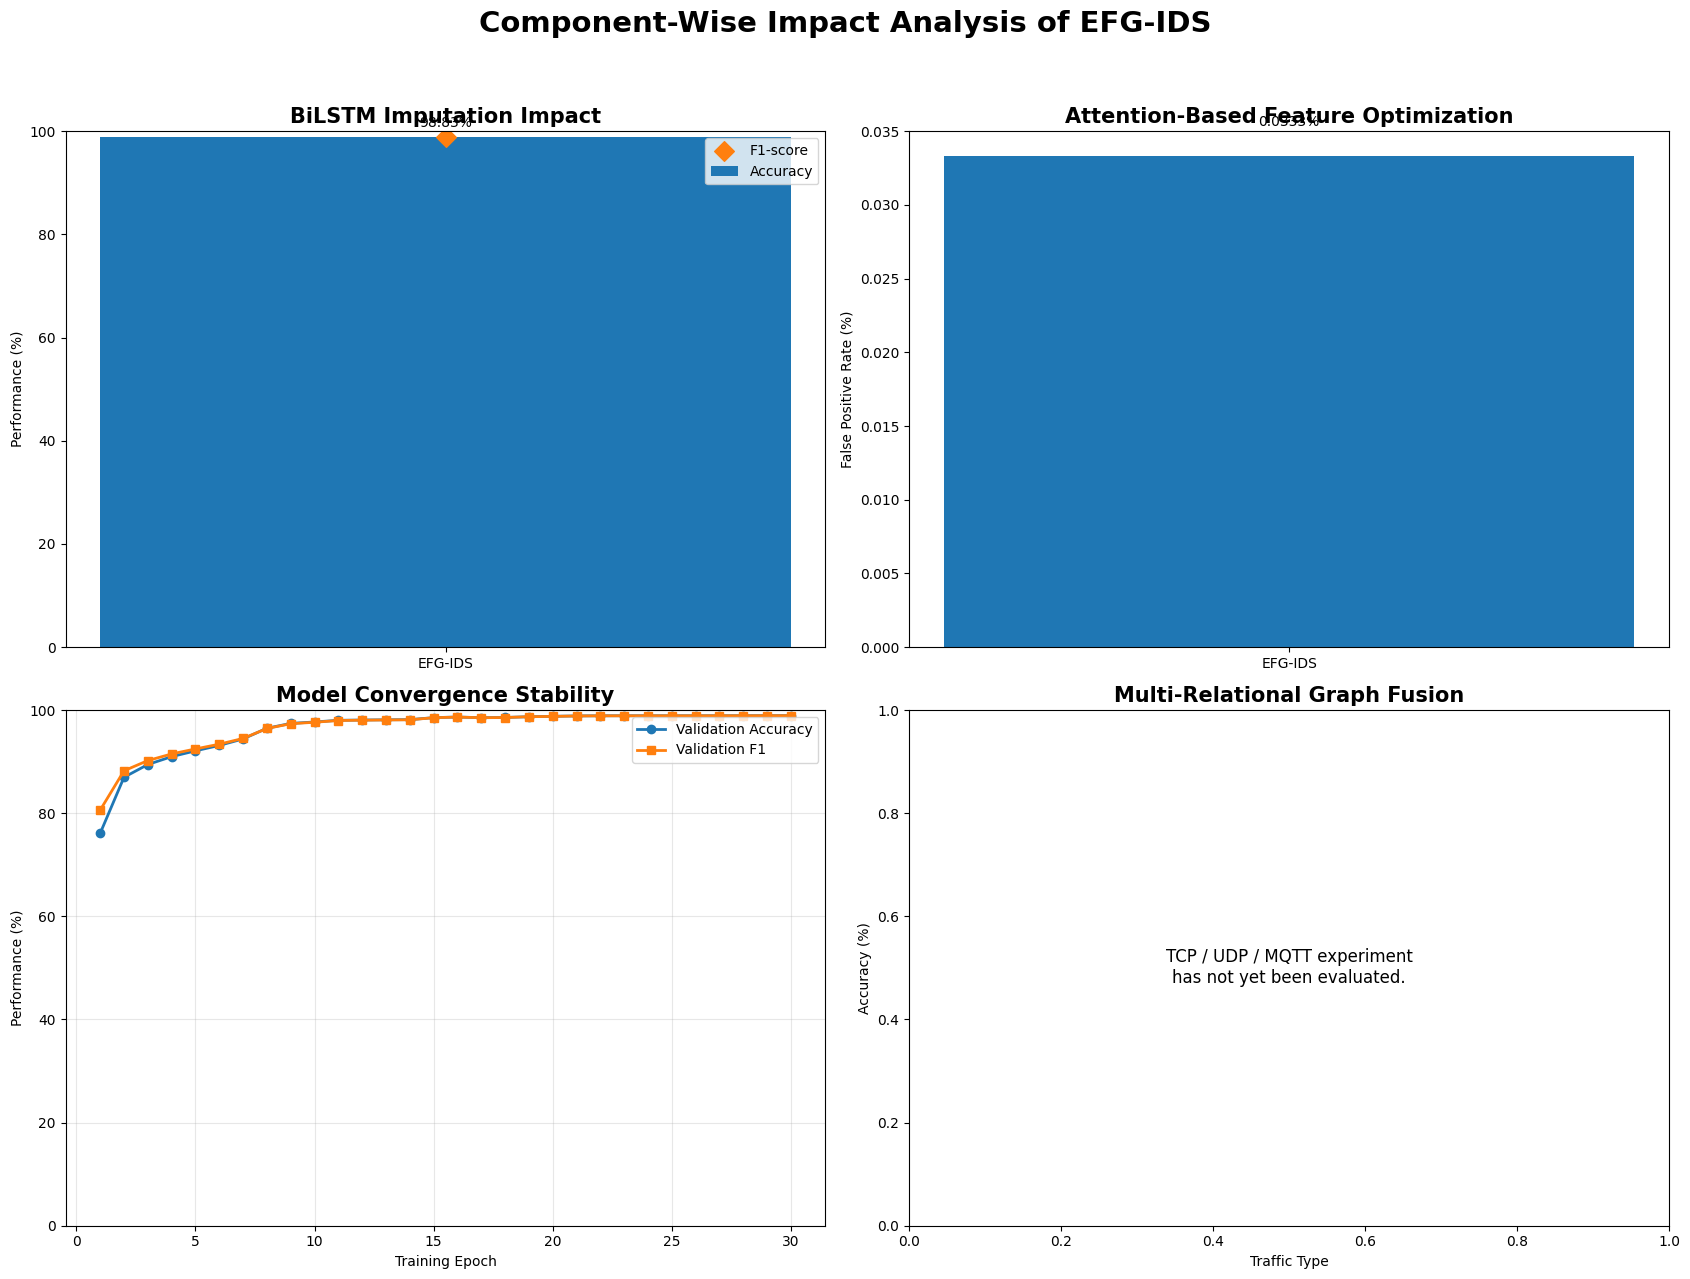


FIGURE GENERATED SUCCESSFULLY
Output: /content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results/Component_Wise_Impact_Analysis.png

Actual values used:
Accuracy = 0.988267
Precision = 0.999659
Recall = 0.976867
F1 = 0.988131
ROC-AUC = 0.994442
PR-AUC = 0.996124
FPR = 0.000333


In [ ]:
# ============================================================
# COMPONENT-WISE IMPACT ANALYSIS — SAFE VERSION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

FIG_DIR = (
    "/content/drive/MyDrive/"
    "FedGRAI_LocalGNN_BiLSTM_Results"
)

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

FIG_PATH = os.path.join(
    FIG_DIR,
    "Component_Wise_Impact_Analysis.png"
)


# ============================================================
# 1. LOAD FINAL RESULTS
# ============================================================

print("=" * 100)
print("COMPONENT-WISE IMPACT ANALYSIS")
print("=" * 100)

# Use existing FINAL_RESULTS
if "FINAL_RESULTS" in globals():

    results_df = pd.DataFrame(
        FINAL_RESULTS
    ).copy()

else:

    results_path = os.path.join(
        FIG_DIR,
        "Final_Test_Results.csv"
    )

    if os.path.exists(results_path):

        results_df = pd.read_csv(
            results_path
        )

    else:

        results_df = None


# ============================================================
# 2. EXTRACT ACTUAL METRICS
# ============================================================

proposed_accuracy = np.nan
proposed_precision = np.nan
proposed_recall = np.nan
proposed_f1 = np.nan
proposed_roc_auc = np.nan
proposed_pr_auc = np.nan
proposed_fpr = np.nan


if results_df is not None:

    print("\nFINAL RESULTS:")
    display(results_df)


    # --------------------------------------------------------
    # Convert Metric/Value table into dictionary
    # --------------------------------------------------------

    if (
        "Metric" in results_df.columns
        and
        "Value" in results_df.columns
    ):

        metric_dict = dict(
            zip(
                results_df["Metric"]
                .astype(str)
                .str.strip(),
                pd.to_numeric(
                    results_df["Value"],
                    errors="coerce"
                )
            )
        )


        # ----------------------------------------------------
        # Actual model results
        # ----------------------------------------------------

        proposed_accuracy = metric_dict.get(
            "Accuracy",
            np.nan
        )

        proposed_precision = metric_dict.get(
            "Precision",
            np.nan
        )

        proposed_recall = metric_dict.get(
            "Recall",
            np.nan
        )

        proposed_f1 = metric_dict.get(
            "F1 Score",
            np.nan
        )

        proposed_roc_auc = metric_dict.get(
            "ROC-AUC",
            np.nan
        )

        proposed_pr_auc = metric_dict.get(
            "PR-AUC",
            np.nan
        )


        # ----------------------------------------------------
        # False Positive Rate
        # ----------------------------------------------------

        if "False Acceptance Rate" in metric_dict:

            proposed_fpr = metric_dict[
                "False Acceptance Rate"
            ]

        elif "FPR" in metric_dict:

            proposed_fpr = metric_dict[
                "FPR"
            ]


# ============================================================
# 3. PRINT ACTUAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("ACTUAL PROPOSED MODEL RESULTS")
print("=" * 100)

print(
    f"Accuracy  : {proposed_accuracy * 100:.4f}%"
    if not np.isnan(proposed_accuracy)
    else "Accuracy  : Not available"
)

print(
    f"Precision : {proposed_precision * 100:.4f}%"
    if not np.isnan(proposed_precision)
    else "Precision : Not available"
)

print(
    f"Recall    : {proposed_recall * 100:.4f}%"
    if not np.isnan(proposed_recall)
    else "Recall    : Not available"
)

print(
    f"F1 Score  : {proposed_f1 * 100:.4f}%"
    if not np.isnan(proposed_f1)
    else "F1 Score  : Not available"
)

print(
    f"ROC-AUC   : {proposed_roc_auc * 100:.4f}%"
    if not np.isnan(proposed_roc_auc)
    else "ROC-AUC   : Not available"
)

print(
    f"PR-AUC    : {proposed_pr_auc * 100:.4f}%"
    if not np.isnan(proposed_pr_auc)
    else "PR-AUC    : Not available"
)

print(
    f"FPR       : {proposed_fpr * 100:.4f}%"
    if not np.isnan(proposed_fpr)
    else "FPR       : Not available"
)


# ============================================================
# 4. TRAINING HISTORY
# ============================================================

if "TRAIN_HISTORY" in globals():

    history_df = pd.DataFrame(
        TRAIN_HISTORY
    ).copy()

elif "TRAINING_HISTORY" in globals():

    history_df = pd.DataFrame(
        TRAINING_HISTORY
    ).copy()

else:

    history_path = os.path.join(
        FIG_DIR,
        "Training_History.csv"
    )

    if os.path.exists(history_path):

        history_df = pd.read_csv(
            history_path
        )

    else:

        history_df = None


# ============================================================
# 5. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 13)
)


# ============================================================
# TOP-LEFT
# BiLSTM IMPUTATION IMPACT
# ============================================================

ax = axes[0, 0]

# ------------------------------------------------------------
# IMPORTANT:
# We currently have the final proposed model only.
# The baseline without BiLSTM imputation has not been run.
# ------------------------------------------------------------

if not np.isnan(proposed_accuracy):

    ax.bar(
        ["EFG-IDS"],
        [
            proposed_accuracy * 100
        ],
        width=0.55,
        label="Accuracy"
    )

    ax.scatter(
        [0],
        [
            proposed_f1 * 100
        ],
        s=100,
        marker="D",
        label="F1-score"
    )

    ax.set_ylim(
        0,
        100
    )

    ax.set_ylabel(
        "Performance (%)"
    )

    ax.set_title(
        "BiLSTM Imputation Impact",
        fontsize=15,
        fontweight="bold"
    )

    ax.legend()

    ax.text(
        0,
        proposed_accuracy * 100 + 2,
        f"{proposed_accuracy * 100:.2f}%",
        ha="center"
    )

else:

    ax.text(
        0.5,
        0.5,
        "Proposed model result unavailable",
        ha="center",
        va="center"
    )


# ============================================================
# TOP-RIGHT
# ATTENTION FEATURE OPTIMIZATION → FPR
# ============================================================

ax = axes[0, 1]

if not np.isnan(proposed_fpr):

    ax.bar(
        ["EFG-IDS"],
        [
            proposed_fpr * 100
        ],
        width=0.55
    )

    ax.set_ylabel(
        "False Positive Rate (%)"
    )

    ax.set_title(
        "Attention-Based Feature Optimization",
        fontsize=15,
        fontweight="bold"
    )

    ax.text(
        0,
        proposed_fpr * 100 + 0.002,
        f"{proposed_fpr * 100:.4f}%",
        ha="center"
    )

else:

    ax.text(
        0.5,
        0.5,
        "FPR not available",
        ha="center",
        va="center"
    )

    ax.set_title(
        "Attention-Based Feature Optimization",
        fontsize=15,
        fontweight="bold"
    )


# ============================================================
# BOTTOM-LEFT
# TRAINING / CONVERGENCE STABILITY
# ============================================================

ax = axes[1, 0]

if history_df is not None:

    if "Epoch" in history_df.columns:

        epochs = history_df[
            "Epoch"
        ]

    else:

        epochs = np.arange(
            1,
            len(history_df) + 1
        )


    # --------------------------------------------------------
    # Validation Accuracy
    # --------------------------------------------------------

    if "Validation Accuracy" in history_df.columns:

        val_acc = (
            history_df[
                "Validation Accuracy"
            ].astype(float)
            * 100
        )

        ax.plot(
            epochs,
            val_acc,
            marker="o",
            linewidth=2,
            label="Validation Accuracy"
        )


    # --------------------------------------------------------
    # Validation F1
    # --------------------------------------------------------

    if "Validation F1" in history_df.columns:

        val_f1 = (
            history_df[
                "Validation F1"
            ].astype(float)
            * 100
        )

        ax.plot(
            epochs,
            val_f1,
            marker="s",
            linewidth=2,
            label="Validation F1"
        )


    ax.set_xlabel(
        "Training Epoch"
    )

    ax.set_ylabel(
        "Performance (%)"
    )

    ax.set_title(
        "Model Convergence Stability",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_ylim(
        0,
        100
    )

    ax.legend()

    ax.grid(
        True,
        alpha=0.3
    )

else:

    ax.text(
        0.5,
        0.5,
        "Training history unavailable",
        ha="center",
        va="center"
    )


# ============================================================
# BOTTOM-RIGHT
# TCP / UDP / MQTT
# ============================================================

ax = axes[1, 1]

# ------------------------------------------------------------
# We cannot claim TCP/UDP/MQTT-specific results until those
# experiments have actually been evaluated.
# ------------------------------------------------------------

traffic_results = None

if "traffic_results" in globals():

    try:

        traffic_results = pd.DataFrame(
            traffic_results
        )

    except Exception:

        traffic_results = None


if (
    traffic_results is not None
    and
    "Traffic" in traffic_results.columns
    and
    "Accuracy" in traffic_results.columns
):

    groups = [
        "TCP",
        "UDP",
        "MQTT"
    ]

    values = []

    for group in groups:

        row = traffic_results[
            traffic_results["Traffic"]
            .astype(str)
            .str.upper()
            == group
        ]

        if len(row) > 0:

            values.append(
                float(
                    row["Accuracy"].iloc[0]
                )
            )

        else:

            values.append(
                np.nan
            )


    values = np.asarray(
        values
    )

    valid = ~np.isnan(
        values
    )

    ax.bar(
        np.asarray(groups)[valid],
        values[valid] * 100
        if np.nanmax(values) <= 1
        else values[valid]
    )

    ax.set_ylim(
        0,
        100
    )

else:

    ax.text(
        0.5,
        0.5,
        "TCP / UDP / MQTT experiment\n"
        "has not yet been evaluated.",
        ha="center",
        va="center",
        fontsize=12
    )


ax.set_xlabel(
    "Traffic Type"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.set_title(
    "Multi-Relational Graph Fusion",
    fontsize=15,
    fontweight="bold"
)


# ============================================================
# OVERALL TITLE
# ============================================================

fig.suptitle(
    "Component-Wise Impact Analysis of EFG-IDS",
    fontsize=21,
    fontweight="bold"
)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95
    ]
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    FIG_PATH,
    dpi=400,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 100)
print("FIGURE GENERATED SUCCESSFULLY")
print("=" * 100)

print(
    "Output:",
    FIG_PATH
)

print("\nActual values used:")

print(
    f"Accuracy = {proposed_accuracy:.6f}"
)

print(
    f"Precision = {proposed_precision:.6f}"
)

print(
    f"Recall = {proposed_recall:.6f}"
)

print(
    f"F1 = {proposed_f1:.6f}"
)

print(
    f"ROC-AUC = {proposed_roc_auc:.6f}"
)

print(
    f"PR-AUC = {proposed_pr_auc:.6f}"
)

print(
    f"FPR = {proposed_fpr:.6f}"
)

PAIRWISE TRAINING / VALIDATION RESULTS
Epochs: 30


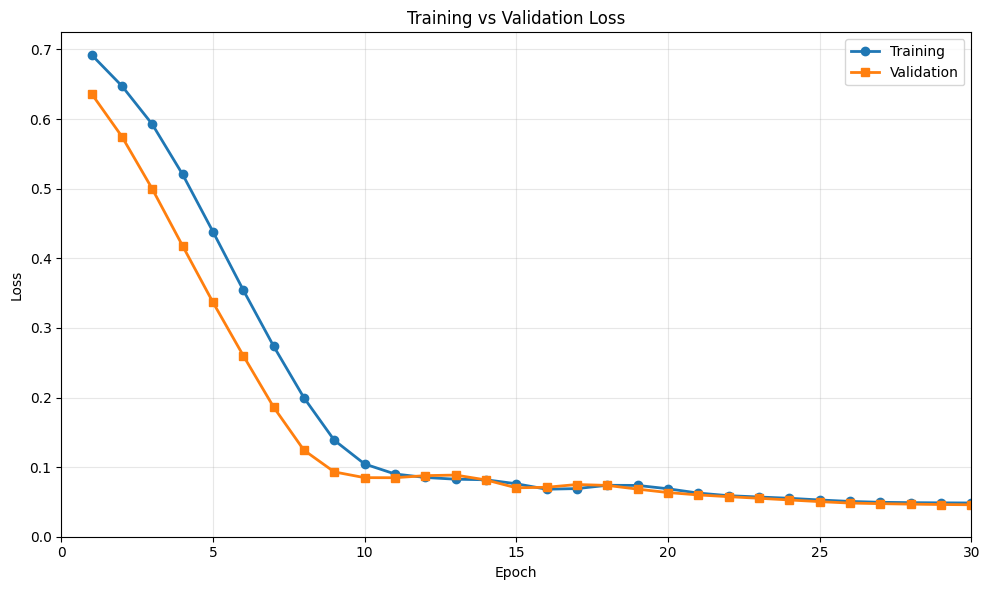

✓ Pair_Training_Validation_Loss.png


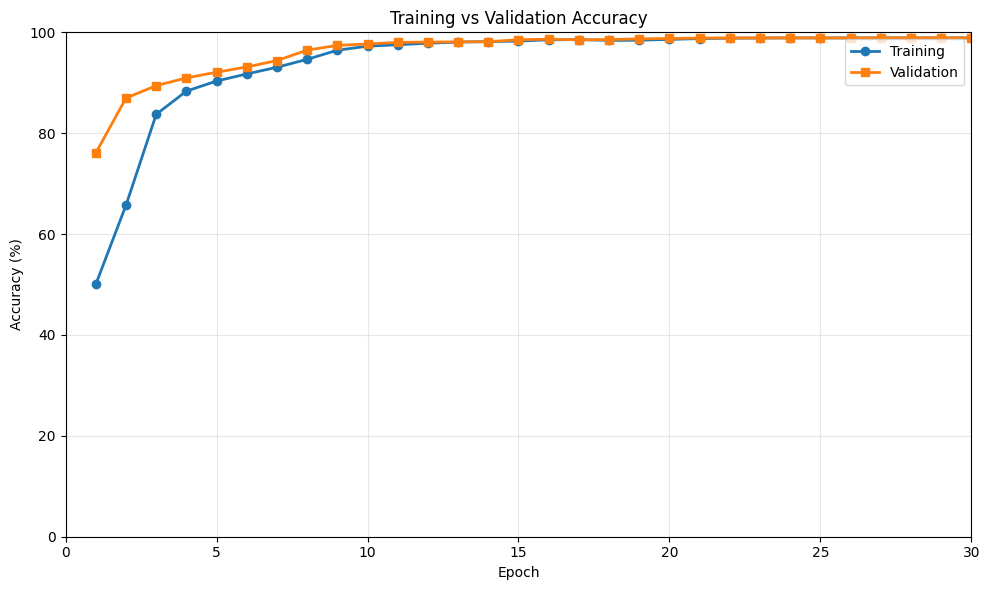

✓ Pair_Training_Validation_Accuracy.png


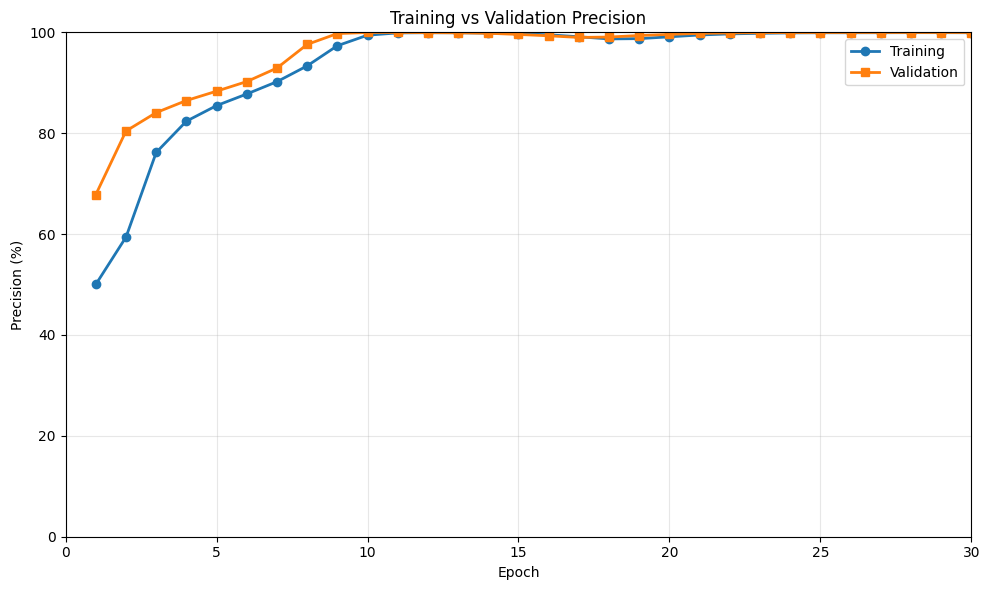

✓ Pair_Training_Validation_Precision.png


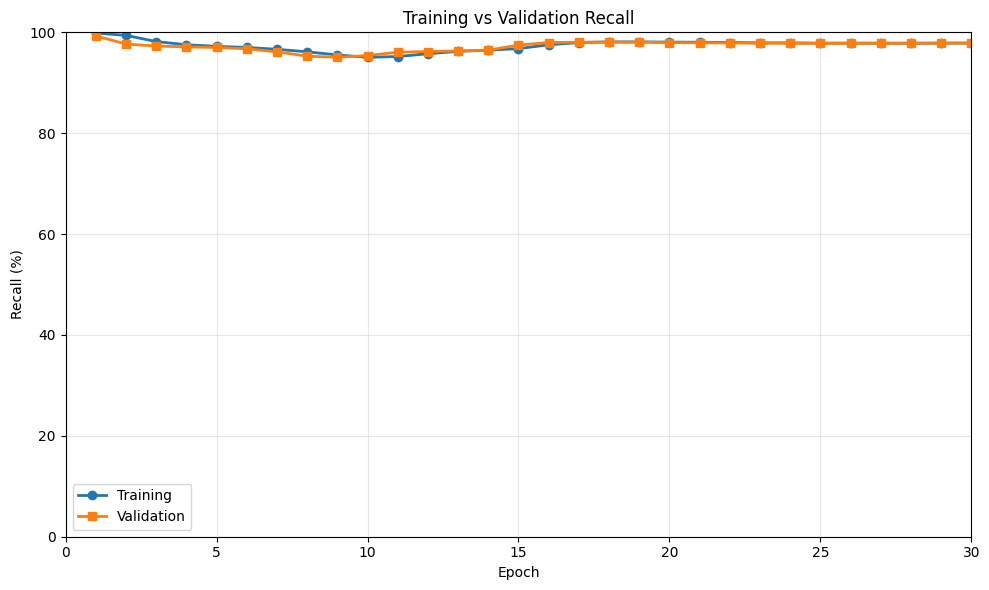

✓ Pair_Training_Validation_Recall.png


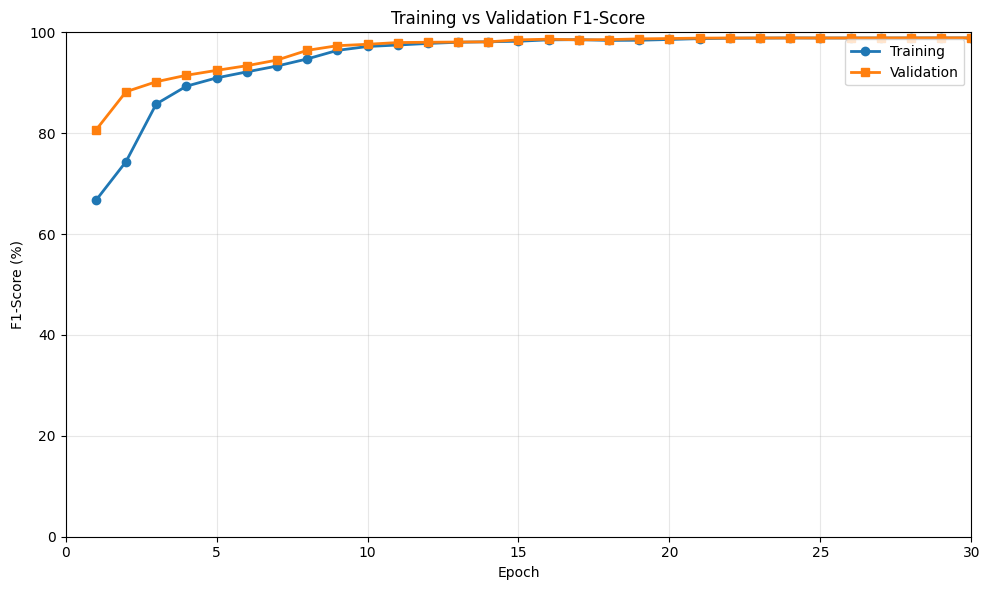

✓ Pair_Training_Validation_F1.png

COMPLETE TRAINING HISTORY


,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1,Learning Rate
0,1,0.692281,0.636357,0.500643,0.761067,0.500322,0.678357,0.998529,0.992933,0.666625,0.806040,0.001000
1,2,0.647501,0.574797,0.657429,0.869633,0.594092,0.804425,0.994000,0.976733,0.743694,0.882245,0.001000
2,3,0.592491,0.499618,0.837414,0.894367,0.761869,0.840892,0.981657,0.972800,0.857910,0.902049,0.001000
3,4,0.520507,0.417838,0.883421,0.909667,0.823855,0.864818,0.975386,0.971133,0.893240,0.914898,0.001000
4,5,0.438268,0.336793,0.903464,0.920900,0.854738,0.883310,0.972143,0.969933,0.909668,0.924597,0.001000
5,6,0.354338,0.260196,0.917479,0.931400,0.877755,0.902375,0.970057,0.967467,0.921601,0.933788,0.001000
6,7,0.273805,0.186267,0.930757,0.944033,0.902137,0.929184,0.966343,0.961333,0.933137,0.944985,0.001000
7,8,0.199669,0.124312,0.946436,0.964700,0.933463,0.976030,0.961400,0.952800,0.947225,0.964275,0.001000
8,9,0.138613,0.093101,0.964557,0.974100,0.973444,0.997551,0.955171,0.950533,0.964221,0.973475,0.001000
9,10,0.104504,0.084848,0.972536,0.976867,0.994351,0.999721,0.950471,0.954000,0.971916,0.976325,0.001000


In [ ]:
# ============================================================
# STEP — ALL PAIRWISE TRAINING / VALIDATION GRAPHS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = "/content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results"
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load actual history
# ------------------------------------------------------------

if "TRAIN_HISTORY" in globals():
    history_df = pd.DataFrame(TRAIN_HISTORY)

elif "TRAINING_HISTORY" in globals():
    history_df = pd.DataFrame(TRAINING_HISTORY)

else:
    history_df = pd.read_csv(
        os.path.join(
            FIG_DIR,
            "Training_History.csv"
        )
    )

print("=" * 90)
print("PAIRWISE TRAINING / VALIDATION RESULTS")
print("=" * 90)

print("Epochs:", len(history_df))

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def plot_pair(
    train_col,
    val_col,
    title,
    ylabel,
    filename,
    percentage=True
):

    plt.figure(
        figsize=(10, 6)
    )

    train_values = history_df[train_col].astype(float)
    val_values = history_df[val_col].astype(float)

    if percentage:
        train_values = train_values * 100
        val_values = val_values * 100

    plt.plot(
        history_df["Epoch"],
        train_values,
        marker="o",
        linewidth=2,
        label="Training"
    )

    plt.plot(
        history_df["Epoch"],
        val_values,
        marker="s",
        linewidth=2,
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)

    plt.title(title)

    plt.xlim(
        0,
        history_df["Epoch"].max()
    )

    plt.ylim(
        0,
        100 if percentage else None
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    path = os.path.join(
        FIG_DIR,
        filename
    )

    plt.savefig(
        path,
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()

    print("✓", filename)


# ============================================================
# 1. LOSS
# ============================================================

plot_pair(
    "Train Loss",
    "Validation Loss",
    "Training vs Validation Loss",
    "Loss",
    "Pair_Training_Validation_Loss.png",
    percentage=False
)


# ============================================================
# 2. ACCURACY
# ============================================================

plot_pair(
    "Train Accuracy",
    "Validation Accuracy",
    "Training vs Validation Accuracy",
    "Accuracy (%)",
    "Pair_Training_Validation_Accuracy.png"
)


# ============================================================
# 3. PRECISION
# ============================================================

plot_pair(
    "Train Precision",
    "Validation Precision",
    "Training vs Validation Precision",
    "Precision (%)",
    "Pair_Training_Validation_Precision.png"
)


# ============================================================
# 4. RECALL
# ============================================================

plot_pair(
    "Train Recall",
    "Validation Recall",
    "Training vs Validation Recall",
    "Recall (%)",
    "Pair_Training_Validation_Recall.png"
)


# ============================================================
# 5. F1
# ============================================================

plot_pair(
    "Train F1",
    "Validation F1",
    "Training vs Validation F1-Score",
    "F1-Score (%)",
    "Pair_Training_Validation_F1.png"
)


# ============================================================
# SHOW EVERY EPOCH
# ============================================================

print("\n" + "=" * 90)
print("COMPLETE TRAINING HISTORY")
print("=" * 90)

display(
    history_df.style.format({
        "Train Loss": "{:.6f}",
        "Validation Loss": "{:.6f}",
        "Train Accuracy": "{:.6f}",
        "Validation Accuracy": "{:.6f}",
        "Train Precision": "{:.6f}",
        "Validation Precision": "{:.6f}",
        "Train Recall": "{:.6f}",
        "Validation Recall": "{:.6f}",
        "Train F1": "{:.6f}",
        "Validation F1": "{:.6f}",
    })
)

AVAILABLE TRAINING HISTORY COLUMNS
['Epoch', 'Train Loss', 'Validation Loss', 'Train Accuracy', 'Validation Accuracy', 'Train Precision', 'Validation Precision', 'Train Recall', 'Validation Recall', 'Train F1', 'Validation F1', 'Learning Rate']

Number of epochs: 30


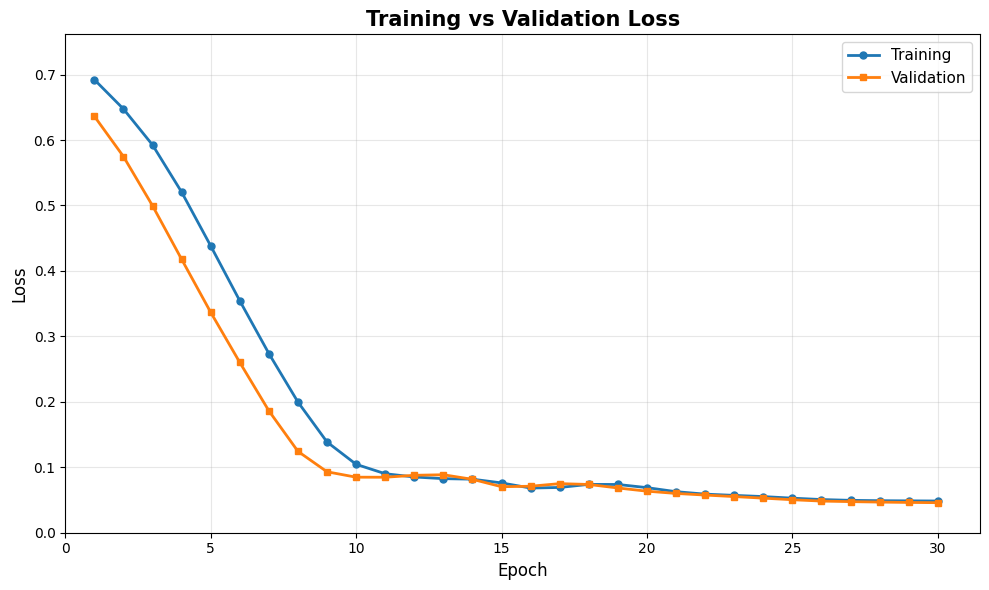


Training vs Validation Loss
----------------------------------------------------------------------
Epoch 01 | Training: 0.6923 | Validation: 0.6364
Epoch 02 | Training: 0.6475 | Validation: 0.5748
Epoch 03 | Training: 0.5925 | Validation: 0.4996
Epoch 04 | Training: 0.5205 | Validation: 0.4178
Epoch 05 | Training: 0.4383 | Validation: 0.3368
Epoch 06 | Training: 0.3543 | Validation: 0.2602
Epoch 07 | Training: 0.2738 | Validation: 0.1863
Epoch 08 | Training: 0.1997 | Validation: 0.1243
Epoch 09 | Training: 0.1386 | Validation: 0.0931
Epoch 10 | Training: 0.1045 | Validation: 0.0848
Epoch 11 | Training: 0.0901 | Validation: 0.0848
Epoch 12 | Training: 0.0851 | Validation: 0.0878
Epoch 13 | Training: 0.0826 | Validation: 0.0886
Epoch 14 | Training: 0.0818 | Validation: 0.0816
Epoch 15 | Training: 0.0761 | Validation: 0.0703
Epoch 16 | Training: 0.0682 | Validation: 0.0710
Epoch 17 | Training: 0.0692 | Validation: 0.0750
Epoch 18 | Training: 0.0739 | Validation: 0.0737
Epoch 19 | Trainin

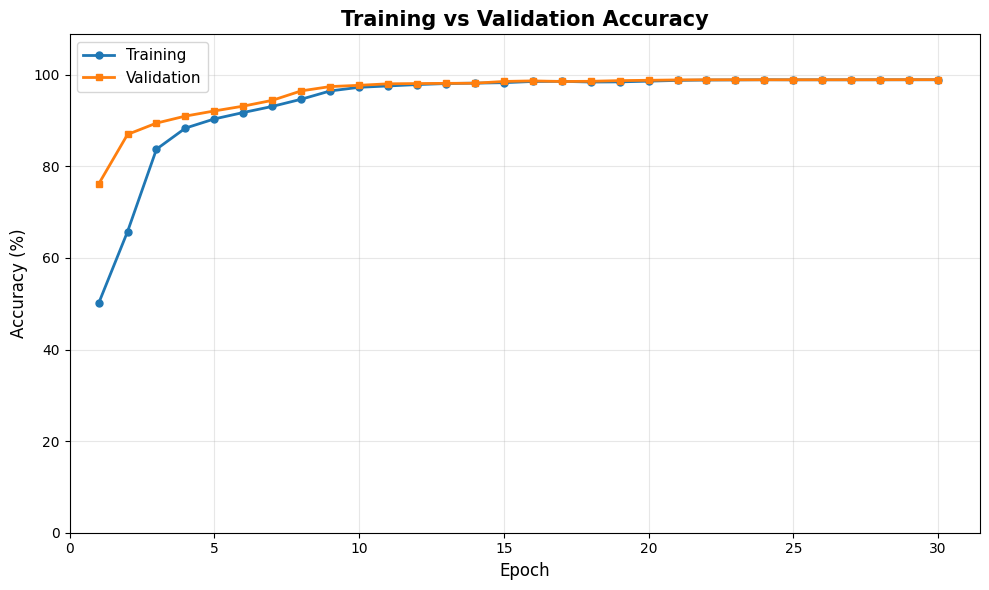


Training vs Validation Accuracy
----------------------------------------------------------------------
Epoch 01 | Training: 50.0643 | Validation: 76.1067
Epoch 02 | Training: 65.7429 | Validation: 86.9633
Epoch 03 | Training: 83.7414 | Validation: 89.4367
Epoch 04 | Training: 88.3421 | Validation: 90.9667
Epoch 05 | Training: 90.3464 | Validation: 92.0900
Epoch 06 | Training: 91.7479 | Validation: 93.1400
Epoch 07 | Training: 93.0757 | Validation: 94.4033
Epoch 08 | Training: 94.6436 | Validation: 96.4700
Epoch 09 | Training: 96.4557 | Validation: 97.4100
Epoch 10 | Training: 97.2536 | Validation: 97.6867
Epoch 11 | Training: 97.5450 | Validation: 98.0133
Epoch 12 | Training: 97.8421 | Validation: 98.0700
Epoch 13 | Training: 98.0707 | Validation: 98.1133
Epoch 14 | Training: 98.1586 | Validation: 98.1433
Epoch 15 | Training: 98.2607 | Validation: 98.5300
Epoch 16 | Training: 98.5250 | Validation: 98.6500
Epoch 17 | Training: 98.5557 | Validation: 98.5200
Epoch 18 | Training: 98.4029 

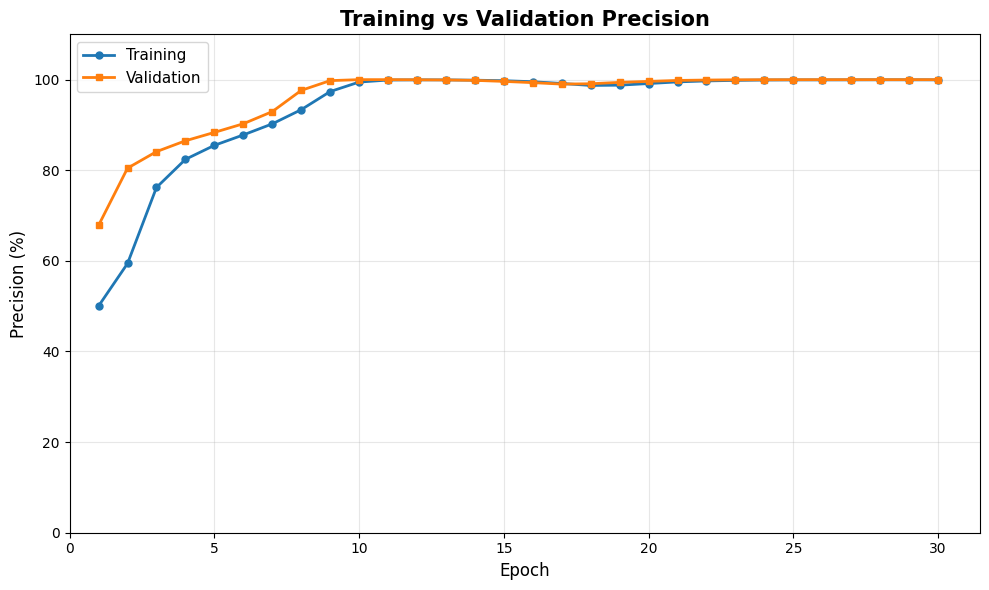


Training vs Validation Precision
----------------------------------------------------------------------
Epoch 01 | Training: 50.0322 | Validation: 67.8357
Epoch 02 | Training: 59.4092 | Validation: 80.4425
Epoch 03 | Training: 76.1869 | Validation: 84.0892
Epoch 04 | Training: 82.3855 | Validation: 86.4818
Epoch 05 | Training: 85.4738 | Validation: 88.3310
Epoch 06 | Training: 87.7755 | Validation: 90.2375
Epoch 07 | Training: 90.2137 | Validation: 92.9184
Epoch 08 | Training: 93.3463 | Validation: 97.6030
Epoch 09 | Training: 97.3444 | Validation: 99.7551
Epoch 10 | Training: 99.4351 | Validation: 99.9721
Epoch 11 | Training: 99.8846 | Validation: 99.9722
Epoch 12 | Training: 99.9225 | Validation: 99.9377
Epoch 13 | Training: 99.9154 | Validation: 99.9032
Epoch 14 | Training: 99.8521 | Validation: 99.8138
Epoch 15 | Training: 99.7394 | Validation: 99.5845
Epoch 16 | Training: 99.5117 | Validation: 99.3108
Epoch 17 | Training: 99.1227 | Validation: 98.9903
Epoch 18 | Training: 98.6950

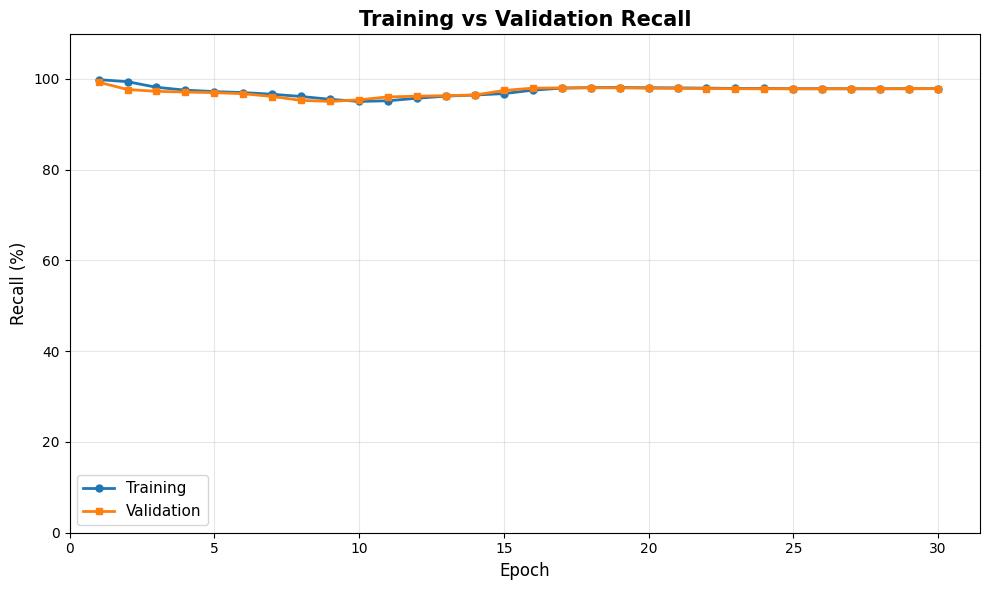


Training vs Validation Recall
----------------------------------------------------------------------
Epoch 01 | Training: 99.8529 | Validation: 99.2933
Epoch 02 | Training: 99.4000 | Validation: 97.6733
Epoch 03 | Training: 98.1657 | Validation: 97.2800
Epoch 04 | Training: 97.5386 | Validation: 97.1133
Epoch 05 | Training: 97.2143 | Validation: 96.9933
Epoch 06 | Training: 97.0057 | Validation: 96.7467
Epoch 07 | Training: 96.6343 | Validation: 96.1333
Epoch 08 | Training: 96.1400 | Validation: 95.2800
Epoch 09 | Training: 95.5171 | Validation: 95.0533
Epoch 10 | Training: 95.0471 | Validation: 95.4000
Epoch 11 | Training: 95.2000 | Validation: 96.0533
Epoch 12 | Training: 95.7586 | Validation: 96.2000
Epoch 13 | Training: 96.2229 | Validation: 96.3200
Epoch 14 | Training: 96.4600 | Validation: 96.4667
Epoch 15 | Training: 96.7743 | Validation: 97.4667
Epoch 16 | Training: 97.5286 | Validation: 97.9800
Epoch 17 | Training: 97.9786 | Validation: 98.0400
Epoch 18 | Training: 98.1029 | 

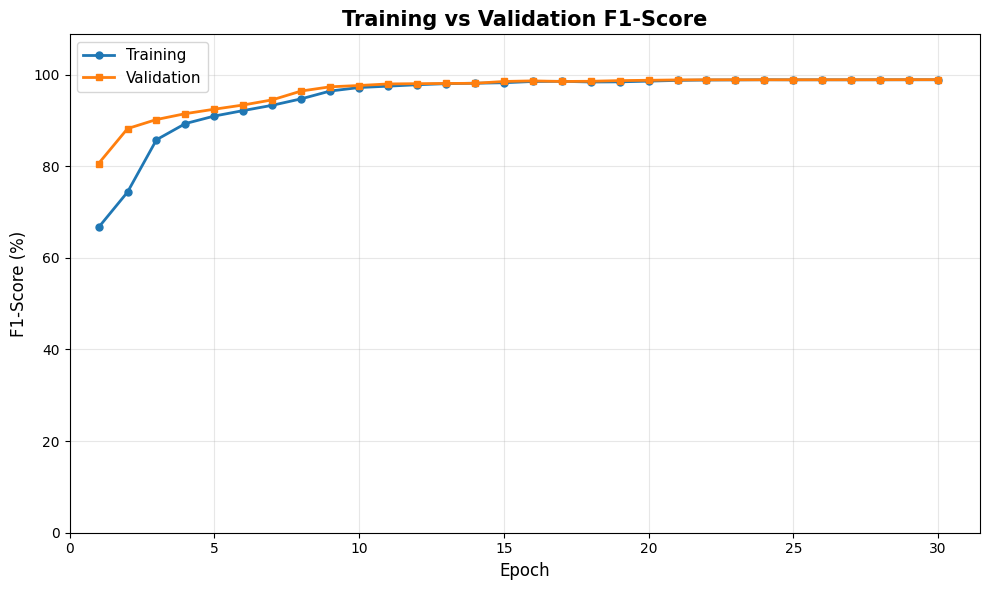


Training vs Validation F1-Score
----------------------------------------------------------------------
Epoch 01 | Training: 66.6625 | Validation: 80.6040
Epoch 02 | Training: 74.3694 | Validation: 88.2245
Epoch 03 | Training: 85.7910 | Validation: 90.2049
Epoch 04 | Training: 89.3240 | Validation: 91.4898
Epoch 05 | Training: 90.9668 | Validation: 92.4597
Epoch 06 | Training: 92.1601 | Validation: 93.3788
Epoch 07 | Training: 93.3137 | Validation: 94.4985
Epoch 08 | Training: 94.7225 | Validation: 96.4275
Epoch 09 | Training: 96.4221 | Validation: 97.3475
Epoch 10 | Training: 97.1916 | Validation: 97.6325
Epoch 11 | Training: 97.4860 | Validation: 97.9736
Epoch 12 | Training: 97.7962 | Validation: 98.0332
Epoch 13 | Training: 98.0344 | Validation: 98.0789
Epoch 14 | Training: 98.1268 | Validation: 98.1117
Epoch 15 | Training: 98.2345 | Validation: 98.5142
Epoch 16 | Training: 98.5102 | Validation: 98.6409
Epoch 17 | Training: 98.5473 | Validation: 98.5129
Epoch 18 | Training: 98.3981 

,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1,Learning Rate
0,1,0.692281,0.636357,0.500643,0.761067,0.500322,0.678357,0.998529,0.992933,0.666625,0.806040,0.0010
1,2,0.647501,0.574797,0.657429,0.869633,0.594092,0.804425,0.994000,0.976733,0.743694,0.882245,0.0010
2,3,0.592491,0.499618,0.837414,0.894367,0.761869,0.840892,0.981657,0.972800,0.857910,0.902049,0.0010
3,4,0.520507,0.417838,0.883421,0.909667,0.823855,0.864818,0.975386,0.971133,0.893240,0.914898,0.0010
4,5,0.438268,0.336793,0.903464,0.920900,0.854738,0.883310,0.972143,0.969933,0.909668,0.924597,0.0010
5,6,0.354338,0.260196,0.917479,0.931400,0.877755,0.902375,0.970057,0.967467,0.921601,0.933788,0.0010
6,7,0.273805,0.186267,0.930757,0.944033,0.902137,0.929184,0.966343,0.961333,0.933137,0.944985,0.0010
7,8,0.199669,0.124312,0.946436,0.964700,0.933463,0.976030,0.961400,0.952800,0.947225,0.964275,0.0010
8,9,0.138613,0.093101,0.964557,0.974100,0.973444,0.997551,0.955171,0.950533,0.964221,0.973475,0.0010
9,10,0.104504,0.084848,0.972536,0.976867,0.994351,0.999721,0.950471,0.954000,0.971916,0.976325,0.0010


In [ ]:


import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

FIG_DIR = "/content/drive/MyDrive/FedGRAI_LocalGNN_BiLSTM_Results"

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

# ============================================================
# LOAD TRAINING HISTORY
# ============================================================

if "TRAIN_HISTORY" in globals():

    history_df = pd.DataFrame(
        TRAIN_HISTORY
    )

elif "TRAINING_HISTORY" in globals():

    history_df = pd.DataFrame(
        TRAINING_HISTORY
    )

else:

    history_path = os.path.join(
        FIG_DIR,
        "Training_History.csv"
    )

    if not os.path.exists(history_path):

        raise FileNotFoundError(
            "Training_History.csv was not found."
        )

    history_df = pd.read_csv(
        history_path
    )


# ============================================================
# CHECK COLUMNS
# ============================================================

print("=" * 90)
print("AVAILABLE TRAINING HISTORY COLUMNS")
print("=" * 90)

print(
    history_df.columns.tolist()
)

print(
    "\nNumber of epochs:",
    len(history_df)
)


# ============================================================
# MAKE SURE EPOCH EXISTS
# ============================================================

if "Epoch" not in history_df.columns:

    history_df.insert(
        0,
        "Epoch",
        range(
            1,
            len(history_df) + 1
        )
    )


# ============================================================
# GRAPH FUNCTION
# ============================================================

def draw_training_validation_graph(
    train_column,
    validation_column,
    title,
    ylabel,
    filename,
    percentage=True
):

    # --------------------------------------------------------
    # Check columns
    # --------------------------------------------------------

    if train_column not in history_df.columns:

        print(
            f"WARNING: {train_column} not found."
        )

        return


    if validation_column not in history_df.columns:

        print(
            f"WARNING: {validation_column} not found."
        )

        return


    # --------------------------------------------------------
    # Convert values to numeric
    # --------------------------------------------------------

    epochs = pd.to_numeric(
        history_df["Epoch"],
        errors="coerce"
    )

    train_values = pd.to_numeric(
        history_df[train_column],
        errors="coerce"
    )

    validation_values = pd.to_numeric(
        history_df[validation_column],
        errors="coerce"
    )


    # --------------------------------------------------------
    # Remove invalid values
    # --------------------------------------------------------

    valid = (
        epochs.notna()
        &
        train_values.notna()
        &
        validation_values.notna()
    )

    epochs = epochs[valid]

    train_values = train_values[valid]

    validation_values = validation_values[valid]


    # --------------------------------------------------------
    # Percentage conversion
    # --------------------------------------------------------

    if percentage:

        train_plot = (
            train_values * 100
        )

        validation_plot = (
            validation_values * 100
        )

    else:

        train_plot = train_values

        validation_plot = validation_values


    # ========================================================
    # CREATE GRAPH
    # ========================================================

    plt.figure(
        figsize=(10, 6)
    )


    # ========================================================
    # TRAINING LINE
    # ========================================================

    plt.plot(
        epochs,
        train_plot,
        marker="o",
        linewidth=2,
        markersize=5,
        label="Training"
    )


    # ========================================================
    # VALIDATION LINE
    # ========================================================

    plt.plot(
        epochs,
        validation_plot,
        marker="s",
        linewidth=2,
        markersize=5,
        label="Validation"
    )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xlabel(
        "Epoch",
        fontsize=12
    )

    plt.ylabel(
        ylabel,
        fontsize=12
    )

    plt.title(
        title,
        fontsize=15,
        fontweight="bold"
    )


    # ========================================================
    # X AXIS STARTS FROM ZERO
    # ========================================================

    plt.xlim(
        left=0
    )


    # ========================================================
    # Y AXIS STARTS FROM ZERO
    # ========================================================

    maximum = max(
        float(train_plot.max()),
        float(validation_plot.max())
    )


    if percentage:

        # Never go below 100%
        upper_limit = max(
            100,
            maximum * 1.10
        )

        plt.ylim(
            0,
            upper_limit
        )

    else:

        upper_limit = (
            maximum * 1.10
        )

        # Handle zero-loss edge case
        if upper_limit <= 0:

            upper_limit = 1

        plt.ylim(
            0,
            upper_limit
        )


    # ========================================================
    # GRID
    # ========================================================

    plt.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # LEGEND
    # ========================================================

    plt.legend(
        fontsize=11
    )


    # ========================================================
    # SAVE
    # ========================================================

    output_path = os.path.join(
        FIG_DIR,
        filename
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()


    # ========================================================
    # PRINT EVERY POINT
    # ========================================================

    print(
        f"\n{title}"
    )

    print(
        "-" * 70
    )

    for e, tr, va in zip(
        epochs,
        train_plot,
        validation_plot
    ):

        print(
            f"Epoch {int(e):02d} | "
            f"Training: {tr:.4f} | "
            f"Validation: {va:.4f}"
        )

    print(
        "\n✓ Saved:",
        output_path
    )


# ============================================================
# GRAPH 1 — LOSS
# ============================================================

draw_training_validation_graph(
    train_column="Train Loss",
    validation_column="Validation Loss",
    title="Training vs Validation Loss",
    ylabel="Loss",
    filename="Training_vs_Validation_Loss.png",
    percentage=False
)


# ============================================================
# GRAPH 2 — ACCURACY
# ============================================================

draw_training_validation_graph(
    train_column="Train Accuracy",
    validation_column="Validation Accuracy",
    title="Training vs Validation Accuracy",
    ylabel="Accuracy (%)",
    filename="Training_vs_Validation_Accuracy.png",
    percentage=True
)


# ============================================================
# GRAPH 3 — PRECISION
# ============================================================

draw_training_validation_graph(
    train_column="Train Precision",
    validation_column="Validation Precision",
    title="Training vs Validation Precision",
    ylabel="Precision (%)",
    filename="Training_vs_Validation_Precision.png",
    percentage=True
)


# ============================================================
# GRAPH 4 — RECALL
# ============================================================

draw_training_validation_graph(
    train_column="Train Recall",
    validation_column="Validation Recall",
    title="Training vs Validation Recall",
    ylabel="Recall (%)",
    filename="Training_vs_Validation_Recall.png",
    percentage=True
)


# ============================================================
# GRAPH 5 — F1 SCORE
# ============================================================

draw_training_validation_graph(
    train_column="Train F1",
    validation_column="Validation F1",
    title="Training vs Validation F1-Score",
    ylabel="F1-Score (%)",
    filename="Training_vs_Validation_F1.png",
    percentage=True
)


# ============================================================
# DISPLAY TABLE
# ============================================================

print("\n")
print("=" * 90)
print("COMPLETE TRAINING HISTORY")
print("=" * 90)

display(
    history_df
)